# 📊 Gehaltsprognose & Interpretation für Data-Berufe (ML-Projekt)

---

### 📌 Projekt-Metadaten

* **Datenquelle:** [Stack Overflow Developer Survey](https://survey.stackoverflow.co/)
* **Untersuchungszeitraum:** 2020–2025
* **Datensatzgröße** ~198 600 Datensätze aus 180+ Ländern

---

### 🔍 Kurzbeschreibung

Dieses Projekt entwickelt eine vollständige End-to-End-Pipeline zur **Vorhersage und Interpretation von Gehältern** auf dem internationalen Markt für Data-Berufe.

Auf Basis von Stack Overflow Developer Surveys (2020–2025) wird ein robustes Regressionsmodell trainiert, das Gehälter in Abhängigkeit von Land, Rolle, Erfahrung, Bildungsabschluss und technischen Skills vorhersagt. SHAP-Analysen sorgen für vollständige Transparenz (White-Box-Ansatz) und isolieren den wirtschaftlichen Effekt einzelner Skills.

Das Endergebnis ist ein interaktives **Data Career Advisor**-System, das personalisierte Gehaltsschätzungen und Skill-Empfehlungen mit quantifizierbarem Einkommenspotenzial liefert.

---

### 📘 Projektstruktur
0. Bibliotheksimport, Datenladen und allgemeine Datenstrukturen
1. EDA + Idee für Features Engineering  
2. Base Model 
3. Train-Test-Split
4. ML 
5. SHAP-Analyse & Modellinterpretation
6. Data Career Advisor — Empfehlungssystem

---

### 🛠️ Technologie-Stack

`Python` · `CatBoost` · `Optuna` · `SHAP` · `scikit-learn` · `Pandas` · `Matplotlib` · `Seaborn`

---

### ✨ Wichtigste Ergebnisse

* **Bestes Modell** CatBoostRegressor (Optuna-optimiert)
* **MAE** ~$25 500 / Jahr 
* **R²**  0.61 

---
## 0. Bibliotheksimport, Datenladen und allgemeine Datenstrukturen

📦 Externe Bibliotheken und Module, die für die Projektdurchführung benötigt werden

In [92]:
# 1. Systemabhängigkeiten (Prozessmanagement, Warnungsfilterung)
import importlib
import os
import re
import warnings
from itertools import product as iterproduct
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

# 2. Datenanalyse-Tools
import numpy as np
import pandas as pd

# 3. Visualisierungsbibliotheken
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# 4. Machine learning
# 4.1. Pipelines und Architektur
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline  # Оставлен чистый sklearn pipeline

# 4.2. Textvorverarbeitung, Imputation und Vektorisierung
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, MultiLabelBinarizer, OneHotEncoder, StandardScaler

# 4.3.Validierung, Clustering und Dekomposition
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity

# 4.4. Basis- und lineare Modelle, Klassifikatoren
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestClassifier, RandomForestRegressor, StackingRegressor, GradientBoostingRegressor

# 4.5. Gradient Boosting
import catboost as cb
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# 4.6. Hyperparameter-Optimierung und Modellinterpretierbarkeit
import optuna
import shap
from optuna.samplers import TPESampler
from collections import Counter

# 5. Visualisierung
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# 6. Lokale Projektmodule
import config_mappings as cfg
import utils


# Module werden automatisch neu gestartet, wenn sich ihr Quellcode (.py) ändert.
importlib.reload(utils)
importlib.reload(cfg)

# Explizite Einfuhr der benötigten Funktionen
from utils import (categorize_currency, 
                   classify_data_role,
                   clean_employment_status,
                   merge_feature_cols,
                   data_split,
                   drop_columns,
                   result,
                   explore_multivalue_column,
                   explore_unique_values,
                   group_rare_categories,
                   load_year,
                   normalize_multivalue_column,
                   normalize_year,
                   optimize_types,
                   overview,
                   replace_rare_with_other,
                   eda_categorical, eda_numeric, fix_apostrophes, impute_work_exp, generate_skill_meta, enrich_devtype_features,
                   compute_sample_weights, categorize_age, fix_apostrophes, shap_log_to_usd_skill)

🎨 Globale Visualisierung und Anpassung der Farbpalette

In [21]:
# Erzeugung der gemischten 'tab20'-Palette
# Fixierung des 'seed' zur Gewährleistung der Reproduzierbarkeit der Farbanordnung
base_colors = list(sns.color_palette('tab20', 20).as_hex())
rng = np.random.default_rng(seed=4)
rng.shuffle(base_colors)

# Globale Registrierung der Palette in Seaborn
# Definition der benutzerdefinierten Farbpalette als Standard für alle nachfolgenden Grafiken.
sns.set_palette(sns.color_palette(base_colors))

# Definition von Farb-Konstanten für den manuellen Zugriff
COLORS = base_colors
C_BLUE, C_RED, C_GREEN = COLORS[0], COLORS[1], COLORS[2]

# Konfiguration der globalen Stileinstellungen (RcParams)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FBFBFB",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "grid.color": "#EAEAEA",
    "grid.alpha": 0.8,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 100,
    "savefig.bbox": "tight"
})

print("✅ Erfolgreiche Aktivierung von Stil für das gesamte Notebook.")

✅ Erfolgreiche Aktivierung von Stil für das gesamte Notebook.


📂 Historische Daten laden und Funktionsumfang prüfen

In [22]:
# 1. Sequenzielles Laden und Zusammenführen von Daten

# Puffer zum Sammeln verarbeiteter Datenrahmen
frames, loaded, missing = [], [], []
print("⏳ Daten laden...")

# Iteration über das Forschungszeitintervall
for year in list(range(2020, 2026)):
    # Laden des Rohdatenrahmens und des Dateinamens aus dem lokalen Verzeichnis „data“
    df_raw, fname = load_year(year, 'data')

    # Schutz vor fehlenden Dateien
    if df_raw is None:
        print(f"  ❌ {year}: Datei nicht gefunden")
        missing.append(year)
        continue

    # Standardisierung von Spaltennamen und Datentypen gemäß dem Konfigurationsschema
    df_norm = normalize_year(df_raw, year, cfg.schema)
    
    # Anzahl der ausgefüllten Fragebögen mit Zielvariable (Gehalt)
    n_salary = df_norm['salary'].notna().sum()
    
    # Speichern des gelöschten Datenrahmens im Puffer
    frames.append(df_norm)
    loaded.append(year)
    
    # Zeigt ein detailliertes Protokoll der Downloads des laufenden Jahres an
    print(f"✔️ {year}  [{fname:18s}]  {len(df_raw):>7,} Zeilen salary={n_salary:>7,}")

# Abschließende Zusammenführung aller Dateien
df = pd.concat(frames, ignore_index=True)

# 2. Erstellung und Analyse einer Feature-Abdeckungskarte (Feature Coverage Map)

print("\n" + "="*60 + " Feature Coverage Map " + "="*60)

# Hervorhebung nur der wichtigsten Merkmale
feature_cols = [c for c in df.columns if c != 'year']
coverage_records = []

# Überprüfung des Vorhandenseins und der Vollständigkeit der Features für jedes erfolgreich geladene Jahr
for year in sorted(loaded):
    df_yr = df[df['year'] == year]
    row = {'Год': year}
    
    for c in feature_cols:
        # Ein Feature gilt als verfügbar (+), wenn die Spalte existiert und mehr als nur NaN-Werte enthält
        has_data = c in df_yr.columns and df_yr[c].notna().any()
        row[c] = '+' if has_data else '-'
        
    coverage_records.append(row)

# Das Ergebnis ist ein lesbarer DataFrame
df_coverage = pd.DataFrame(coverage_records).set_index('Год')

# Ausgabe der Abdeckungsmatrix
print(df_coverage.to_string())

⏳ Daten laden...
✔️ 2020  [so_2020.csv       ]   64,461 Zeilen salary= 34,756
✔️ 2021  [so_2021.csv       ]   83,439 Zeilen salary= 46,844
✔️ 2022  [so_2022.csv       ]   73,268 Zeilen salary= 38,071
✔️ 2023  [so_2023.csv       ]   89,184 Zeilen salary= 48,019
✔️ 2024  [so_2024.csv       ]   65,437 Zeilen salary= 23,435
✔️ 2025  [so_2025.csv       ]   49,191 Zeilen salary= 23,947

============================================================ Feature Coverage Map ============================================================
     salary currency country workexp yearscode yearscodepro remote age branch devtype education employment industry orgsize icorpm language_have language_entry database_have database_entry platform_have platform_entry webframe_have webframe_entry tech_have tech_entry ai_have ai_entry aiselect aiagents activities opsys office_stack
Год                                                                                                                                         

In [23]:
df = merge_feature_cols(df, 'language_have', 'language_entry', 'language')
df = merge_feature_cols(df, 'database_have', 'database_entry', 'database')
df = merge_feature_cols(df, 'platform_have', 'platform_entry', 'platform')
df = merge_feature_cols(df, 'webframe_have', 'webframe_entry', 'webframe')
df = merge_feature_cols(df, 'tech_have', 'tech_entry', 'tech')
df = merge_feature_cols(df, 'ai_have', 'ai_entry', 'ai')
df = drop_columns(df, ['language_have', 'language_entry', 'database_have', 'database_entry', 'platform_have', 'platform_entry', 'webframe_have', 'webframe_entry', 
                       'tech_have', 'tech_entry', 'ai_have', 'ai_entry'])

🧹 Normalisierung von Lückenmustern in Zeichenketten und Behandlung von Textanomalien

In [24]:
# Liste der String-Variationen mit Lücken
nan_variants = ["NaN", "nan", "<NA>", "<na>", "None", "none", "null", ""]

# Spalten nach Datentyp trennen
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# Vereinheitlichung kategorischer Auslassungen ('Unknown')
df[cat_cols] = df[cat_cols].map(lambda x: ('Unknown' if pd.isna(x) or str(x).strip() in nan_variants or x is None else x))

# Datenbereinigung der Berufserfahrung (`workexp`, `yearscode`)
df['workexp'] = df['workexp'].replace({'Unknown': np.nan}).astype(float)
df['yearscode'] = df['yearscode'].replace({'Less than 1 year': 0, 'More than 50 years': 51, 'Unknown': np.nan}).astype(float)
df['yearscodepro'] = df['yearscodepro'].replace({'Less than 1 year': 0, 'More than 50 years': 51, 'Unknown': np.nan}).astype(float)
df['age'] = df['age'].apply(categorize_age)

print(f"✔️ Verarbeitung abgeschlossen")

✔️ Verarbeitung abgeschlossen


🛠️ Auf Duplikate prüfen

In [25]:
# Auf Duplikate prüfen
print(f"📝 Anzahl der Duplikate: {df.duplicated().sum()}")

if df.duplicated().sum()>0:
    df = df.drop_duplicates(keep='first')
    print(f"✔️ Duplikate entfernt")

📝 Anzahl der Duplikate: 10490
✔️ Duplikate entfernt


🗂️ Auswahl von Datenberufen

In [26]:
# Anreicherung der Merkmale aus 'devtype'
df = enrich_devtype_features(df, devtype_col='devtype')
df = drop_columns(df, ['devtype'])

# Bereinigung der 'devtype_data'-Spalte:
df['devtype_data'] = (df['devtype_data'].str.split(";").str[0].str.strip().replace('None', 'Unknown'))

✂️ Ausreißerfilterung (IQR-Methode)

In [27]:
# Entfernung von NaN-Werten in der Zielvariable
df = df.dropna(subset=['salary']).copy()

# Berechnung von Quantilen und Interquartilsabstand (IQR)
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

# Adaptive Obergrenze und feste Untergrenze
upper_bound = Q3 + 3.0 * IQR
lower_bound = 5000  # Bedingtes Null-Einkommen

print(f"📐 Die Grenzen für angemessene Gehälter wurden definiert: von ${lower_bound:,} bis ${upper_bound:,.0f}")

# Filtern des Datenrahmens, Entfernen von Anomalien
df = df[(df['salary'] >= lower_bound) & (df['salary'] <= upper_bound)].copy()
df['salary'] = df['salary'] / 1000

📐 Die Grenzen für angemessene Gehälter wurden definiert: von $5,000 bis $343,687


📊 Datenstruktur

In [28]:
print(f"✏️ Datensatzdimension: {df.shape}")

✏️ Datensatzdimension: (198628, 30)


In [29]:
# Transponierte Ausgabe der ersten 5 Zeilen des Dataframes
df.head().T

,7,9,10,11,12
year,2020,2020,2020,2020,2020
salary,116.0,32.315,40.07,14.268,38.916
currency,United States dollar,Pound sterling,Pound sterling,European Euro,European Euro
country,United States,United Kingdom,United Kingdom,Spain,Netherlands
workexp,NaN,NaN,NaN,NaN,NaN
yearscode,17.0,8.0,10.0,7.0,35.0
yearscodepro,13.0,4.0,2.0,7.0,20.0
remote,Unknown,Unknown,Unknown,Unknown,Unknown
age,35-44,18-24,18-24,45-54,45-54
branch,I am a developer by profession,I am a developer by profession,I am a developer by profession,I am a developer by profession,"I am not primarily a developer, but I write co..."


In [30]:
# Allgemeiner Überblick über die Datenstruktur
overview(df)

,dtype,count,missing_n,missing_%,uniques_n,uniques
year,int64,198628,0,0.000000,6,"[2020, 2021, 2022, 2023, 2024, 2025]"
salary,float64,198628,0,0.000000,28380,"[116.0, 32.315, 40.07, 14.268, 38.916, 66.0, 1..."
currency,str,198628,0,0.000000,275,"[United States dollar, Pound sterling, Europea..."
country,str,198628,0,0.000000,187,"[United States, United Kingdom, Spain, Netherl..."
workexp,float64,92147,106481,53.608253,66,"[nan, 6.0, 14.0, 5.0, 4.0, 23.0, 9.0, 21.0, 3...."
yearscode,float64,197951,677,0.340838,66,"[17.0, 8.0, 10.0, 7.0, 35.0, 5.0, 37.0, 9.0, 3..."
yearscodepro,float64,175958,22670,11.413295,52,"[13.0, 4.0, 2.0, 7.0, 20.0, 1.0, 23.0, 3.0, 10..."
remote,str,198628,0,0.000000,9,"[Unknown, Hybrid (some remote, some in-person)..."
age,str,198628,0,0.000000,8,"[35-44, 18-24, 45-54, 25-34, Unknown, 55-64, 6..."
branch,str,198628,0,0.000000,7,"[I am a developer by profession, I am not prim..."


In [31]:
# Deskriptive Statistik numerischer Merkmale
df.describe()

,year,salary,workexp,yearscode,yearscodepro,role_count,data_role_purity
count,198628.000000,198628.000000,92147.000000,197951.000000,175958.000000,198628.000000,198628.000000
mean,2022.237308,79.843243,11.802717,15.346525,9.776566,1.982545,0.078161
std,1.565010,59.079180,9.112020,9.820353,8.269112,1.838392,0.227728
min,2020.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2021.000000,36.753000,5.000000,8.000000,4.000000,1.000000,0.000000
50%,2022.000000,65.663000,10.000000,13.000000,7.000000,1.000000,0.000000
75%,2023.000000,108.000000,16.000000,20.000000,14.000000,2.000000,0.000000
max,2025.000000,343.603000,100.000000,100.000000,51.000000,29.000000,1.000000


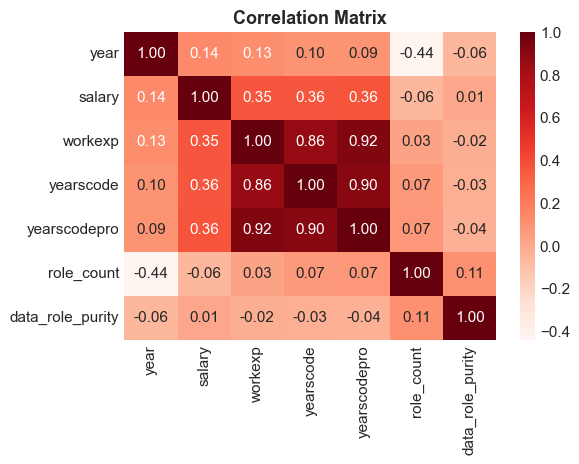

In [32]:
# Correlation Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap=plt.cm.Reds) 
plt.title('Correlation Matrix')
plt.show()

---
## 🔎 1. EDA + Idee für Features Engineering

📈 Analyse der ursprünglichen und logarithmischen Verteilung der Zielvariablen

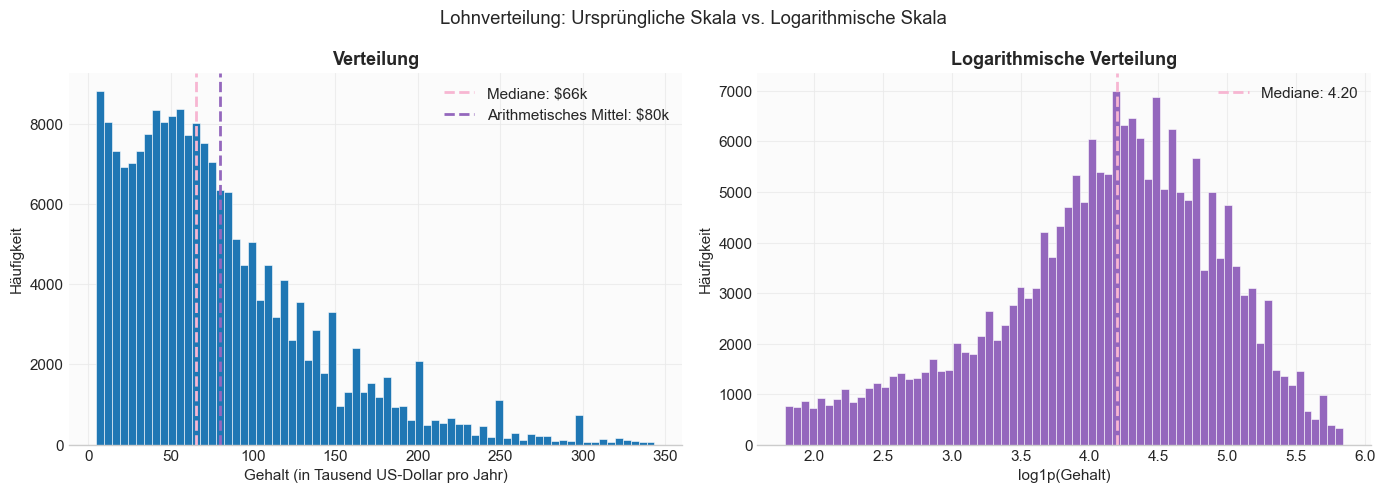

In [33]:
# Initialisieren eines Grafikfensters mit zwei Zeichenbereichen
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Lohnverteilung: Ursprüngliche Skala vs. Logarithmische Skala")

# Ursprüngliche Skala
ax[0].hist(df['salary'], bins=70, color=C_BLUE, edgecolor="white", linewidth=0.4)

# Mediane
ax[0].axvline(df['salary'].median(), color=C_RED, lw=2, ls="--", label=f"Mediane: ${df['salary'].median():.0f}k")

# Arithmetisches Mittel
ax[0].axvline(df['salary'].mean(), color=C_GREEN, lw=2, ls="--", label=f"Arithmetisches Mittel: ${df['salary'].mean():.0f}k")

ax[0].set_xlabel("Gehalt (in Tausend US-Dollar pro Jahr)")
ax[0].set_ylabel("Häufigkeit")
ax[0].set_title("Verteilung")
ax[0].legend()

# Logarithmische Verteilung
ax[1].hist(np.log1p(df['salary']), bins=70, color=C_GREEN, edgecolor="white", linewidth=0.4)

# Mediane
ax[1].axvline(np.log1p(df['salary']).median(), color=C_RED, lw=2, ls="--", label=f"Mediane: {np.log1p(df['salary']).median():.2f}")

ax[1].set_xlabel("log1p(Gehalt)")
ax[1].set_ylabel("Häufigkeit")
ax[1].set_title("Logarithmische Verteilung")
ax[1].legend()

plt.tight_layout()
plt.show()

📊 Visualisierung von Mediangehältern und Datenrollenbesetzung

In [34]:
# Dataframe mit neu der Features
df_grp = df.copy()

# Kaskadierende Ausführung der Transformations-Pipeline
df_grp = normalize_multivalue_column(df_grp, 'devtype_data', mapping=cfg.data_role_mapping)
explore_multivalue_column(df_grp[df_grp['devtype_data'] != 'Unknown'], 'devtype_data', top_n = 100)

🔍 Spaltenanalyse: 'devtype_data'
Zeilen: 29,473     Ausgefüllt (Nicht-NaN): 29,473     Eindeutige Werte: 8
Anzeige der ersten 8 Zeilen:
                                Häufigkeit  Anteil (%)
devtype_data                                          
Database Administrator                7895       26.79
Data Engineer                         7402       25.11
Data Scientist / ML specialist        7194       24.41
Data Analyst                          4605       15.62
Scientist                             1863        6.32
AI/ML Engineer                         312        1.06
Applied scientist                      152        0.52
Financial Analyst                       50        0.17
------------------------------------------------------------



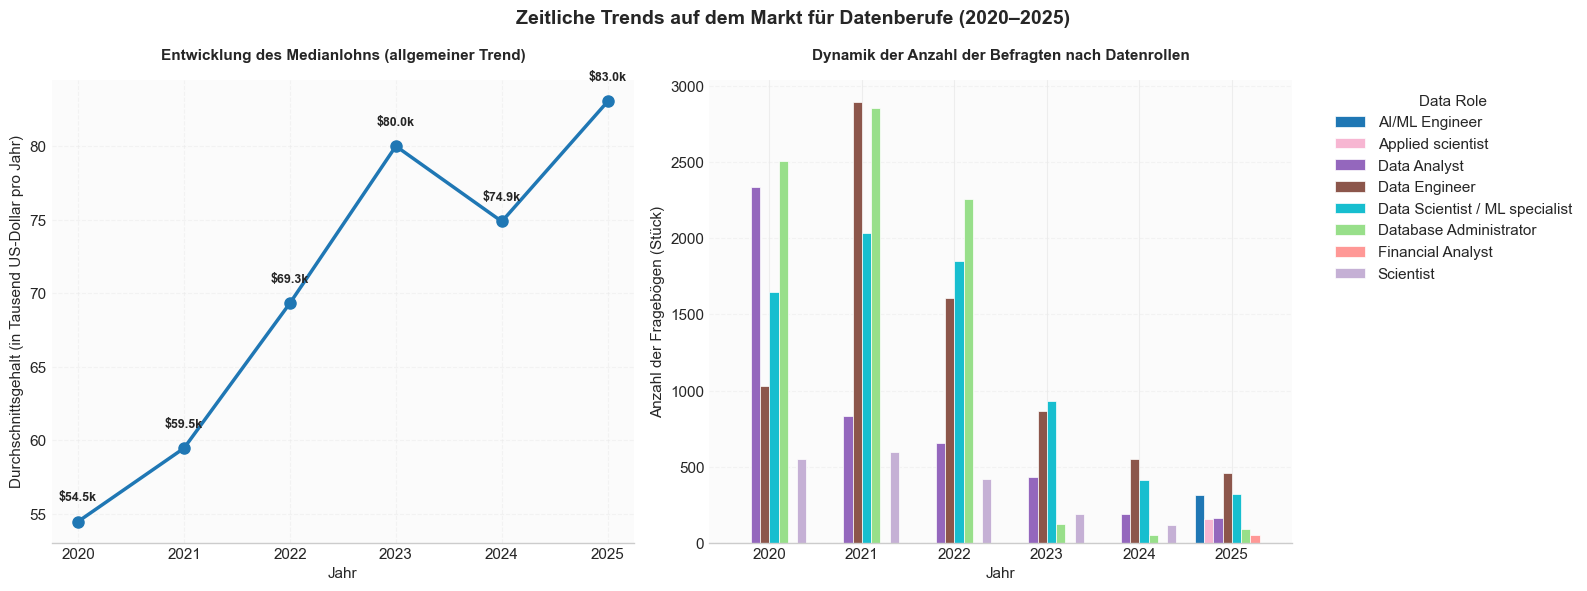

In [35]:
# Initialisieren eines Grafikfensters mit zwei Bereichen
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Zeitliche Trends auf dem Markt für Datenberufe (2020–2025)", fontsize=14, fontweight='bold')

# Aufbereitung aggregierter Daten
yearly_salaries = df_grp[df_grp['devtype_data'] != 'Unknown'].groupby('year')['salary'].median().reset_index()

# Dynamik der Mediangehälter
ax[0].plot(yearly_salaries["year"], yearly_salaries["salary"], 
         marker='o', color=C_BLUE, linewidth=2.5, markersize=8, label="Медиана ($ тыс.)")

# Anbringen von Textbeschriftungen mit genauen Beträgen über den Zeitmarken
for idx, row in yearly_salaries.iterrows():
    ax[0].annotate(f"${row['salary']:.1f}k", 
                 (row['year'], row['salary']),
                 textcoords="offset points", xytext=(0, 15), ha='center', fontsize=9, fontweight='bold')

ax[0].set_title("Entwicklung des Medianlohns (allgemeiner Trend)", fontsize=11, pad=15)
ax[0].set_xlabel("Jahr")
ax[0].set_ylabel("Durchschnittsgehalt (in Tausend US-Dollar pro Jahr)")
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].set_xticks(yearly_salaries["year"])

# Dynamik der Rollenbesetzung

df_exploded = df_grp[df_grp['devtype_data'] != 'Unknown'].assign(data_role_split = df_grp[df_grp['devtype_data'] != 'Unknown']['devtype_data'].str.split(';')
                                                                 ).explode('data_role_split')


df_exploded['data_role_split'] = df_exploded['data_role_split'].str.strip()

df_clean = df_exploded[df_exploded['data_role_split'].notna() & (df_exploded['data_role_split'] != 'None') & 
                       (df_exploded['data_role_split'] != '')]

roles_by_year = df_clean.groupby(['year', 'data_role_split'])['salary'].count().unstack().fillna(0)

roles_by_year.plot(kind="bar", ax=ax[1], edgecolor="white", linewidth=0.5, width=0.8)

ax[1].set_title("Dynamik der Anzahl der Befragten nach Datenrollen", fontsize=11, pad=15)
ax[1].set_xlabel("Jahr")
ax[1].set_ylabel("Anzahl der Fragebögen (Stück)")
ax[1].grid(True, axis='y', linestyle="--", alpha=0.5)
ax[1].tick_params(axis='x', rotation=0)
ax[1].legend(title="Data Role", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 💡 Hinweis
Die Stagnation der Stichprobengröße (n) zwischen 2023 und 2025 deutet weder auf eine Schrumpfung des IT-Marktes noch auf einen Rückgang der Nachfrage nach Data-Science-Fachkräften hin. Dieser Trend spiegelt vielmehr einen systematischen Rückgang der Gesamtzahl der Teilnehmer an der Stack-Overflow-Umfrage sowie eine Änderung der internen Validierungsmethodik des Fragebogens der Plattform wider.

🔄 Normalisierung und Aggregatbildung der Features — Features engineering

In [37]:
# Normalisierung und Aggregatbildung von kategorialer Variablen
for c in ['remote', 'branch', 'industry', 'icorpm', 'aiselect']:
    # Replace
    df_grp[c] = df_grp[c].replace(getattr(cfg, f"{c}_mapping"))
    explore_unique_values(df_grp, c) # Häufigkeitskontrolle der Kategorien

# Erstellung des ordinalen Rangs
df_grp['education'] = df_grp['education'].replace(cfg.education_mapping).astype(object)
explore_unique_values(df_grp, 'education') # Häufigkeitskontrolle der Kategorien

df_grp['education_rank'] = df_grp['education'].replace(cfg.education_rank_mapping).astype(object)
explore_unique_values(df_grp, 'education_rank') # Häufigkeitskontrolle der Kategorien

# Erstellung des ordinalen Rangs
df_grp['orgsize'] = df_grp['orgsize'].replace(cfg.orgsize_mapping).astype(object)
explore_unique_values(df_grp, 'orgsize') # Häufigkeitskontrolle der Kategorien

df_grp['orgsize_rank'] = df_grp['orgsize'].replace(cfg.orgsize_rank_mapping).astype(object)
explore_unique_values(df_grp, 'orgsize_rank') # Häufigkeitskontrolle der Kategorien

# Bereinigung und Standardisierung des Beschäftigungsstatus
df_grp['employment'] = df_grp['employment'].apply(clean_employment_status)
explore_unique_values(df_grp, 'employment') # Häufigkeitskontrolle der Kategorien

# Replace der Land
df_grp['country'] = df_grp['country'].replace({'United States of America': 'United States',
                                               'United Kingdom of Great Britain and Northern Ireland': 'Great Britain'})
# Zusammenfassung von seltenen Ländern zur Reduzierung der Feature-Breite
#df_grp['country'] = group_rare_categories(df_grp, 'country')
explore_unique_values(df_grp, 'country') # Häufigkeitskontrolle der Kategorien

🔍 Spaltenanalyse: 'remote'
Zeilen: 198,628     Ausgefüllt (Nicht-NaN): 198,628     Eindeutige Werte: 4
Anzeige der ersten 4 Zeilen:
         Häufigkeit  Anteil (%)
remote                         
Unknown       77709       39.12
Hybrid        53561       26.97
Remote        51183       25.77
On-site       16175        8.14
------------------------------------------------------------

🔍 Spaltenanalyse: 'branch'
Zeilen: 198,628     Ausgefüllt (Nicht-NaN): 198,628     Eindeutige Werte: 3
Anzeige der ersten 3 Zeilen:
                        Häufigkeit  Anteil (%)
branch                                        
Professional                180927       91.09
Coding at Work/Studies       16513        8.31
Other                         1188        0.60
------------------------------------------------------------

🔍 Spaltenanalyse: 'industry'
Zeilen: 198,628     Ausgefüllt (Nicht-NaN): 198,628     Eindeutige Werte: 13
Anzeige der ersten 5 Zeilen:
                                         Häufigkei

In [38]:
# Standardisierung der Gehaltswährungen
df_grp['currency'] = df_grp['currency'].apply(categorize_currency)
# Zusammenfassung von seltenen Währungszeichen zur Reduzierung der Feature-Breite
#df_grp['currency'] = group_rare_categories(df_grp, 'currency')
explore_unique_values(df_grp, 'currency') # Häufigkeitskontrolle der Kategorien

🔍 Spaltenanalyse: 'currency'
Zeilen: 198,628     Ausgefüllt (Nicht-NaN): 198,628     Eindeutige Werte: 16
Anzeige der ersten 5 Zeilen:
          Häufigkeit  Anteil (%)
currency                        
EUR            53750       27.06
USD            52593       26.48
Other          28712       14.46
GBP            13818        6.96
INR            10312        5.19
... und weitere 11 eindeutige Werte sind ausgeblendet (Parameter top_n anpassen).
------------------------------------------------------------



In [39]:
for c in ['language', 'database', 'platform', 'webframe', 'tech', 'ai', 'opsys', 'activities', 'office_stack']:
    # Dynamisches Laden des passenden Mappings aus der cfg-Klasse (z.B. cfg.language_mapping)
    current_mapping = getattr(cfg, f"{c}_mapping")
    
    # Kaskadierende Ausführung der Transformations-Pipeline
    df_grp = normalize_multivalue_column(df_grp, c, mapping=current_mapping)
    #df_grp = replace_rare_with_other(df_grp, c)
    explore_multivalue_column(df_grp, c, top_n = 100)

🔍 Spaltenanalyse: 'language'
Zeilen: 198,628     Ausgefüllt (Nicht-NaN): 198,628     Eindeutige Werte: 1,200
Anzeige der ersten 100 Zeilen:
                       Häufigkeit  Anteil (%)
language                                     
JavaScript                 130008       65.45
HTML/CSS                   108428       54.59
SQL                        106368       53.55
Python                      88808       44.71
Bash/Shell/PowerShell       81432       41.00
TypeScript                  76895       38.71
Java                        59347       29.88
C#                          58512       29.46
PHP                         38454       19.36
C++                         34900       17.57
C                           28554       14.38
Go                          25077       12.63
Rust                        17734        8.93
Kotlin                      17449        8.78
Node.js                     15294        7.70
Ruby                        14783        7.44
VBA                         1083

In [40]:
overview(df_grp)

,dtype,count,missing_n,missing_%,uniques_n,uniques
year,int64,198628,0,0.000000,6,"[2020, 2021, 2022, 2023, 2024, 2025]"
salary,float64,198628,0,0.000000,28380,"[116.0, 32.315, 40.07, 14.268, 38.916, 66.0, 1..."
currency,str,198628,0,0.000000,16,"[USD, GBP, EUR, CAD, BRL, Other, ILS, CZK, SEK..."
country,str,198628,0,0.000000,186,"[United States, United Kingdom, Spain, Netherl..."
workexp,float64,92147,106481,53.608253,66,"[nan, 6.0, 14.0, 5.0, 4.0, 23.0, 9.0, 21.0, 3...."
yearscode,float64,197951,677,0.340838,66,"[17.0, 8.0, 10.0, 7.0, 35.0, 5.0, 37.0, 9.0, 3..."
yearscodepro,float64,175958,22670,11.413295,52,"[13.0, 4.0, 2.0, 7.0, 20.0, 1.0, 23.0, 3.0, 10..."
remote,str,198628,0,0.000000,4,"[Unknown, Hybrid, Remote, On-site]"
age,str,198628,0,0.000000,8,"[35-44, 18-24, 45-54, 25-34, Unknown, 55-64, 6..."
branch,str,198628,0,0.000000,3,"[Professional, Coding at Work/Studies, Other]"


In [41]:
# Features engineering
df_grp['temporal_weight'] = df_grp['year'].map({2020: 0.5, 
                                                2021: 0.7,
                                                2022: 1.0,
                                                2023: 1.5,
                                                2024: 2.5,
                                                2025: 3.0})

df_grp['country_region'] = (df['country'].map(cfg.region_mapping).fillna('Other'))

df_grp = impute_work_exp(df_grp)

df_grp['country_region'] = (df_grp['country'].map(cfg.region_mapping).fillna('Other')) 

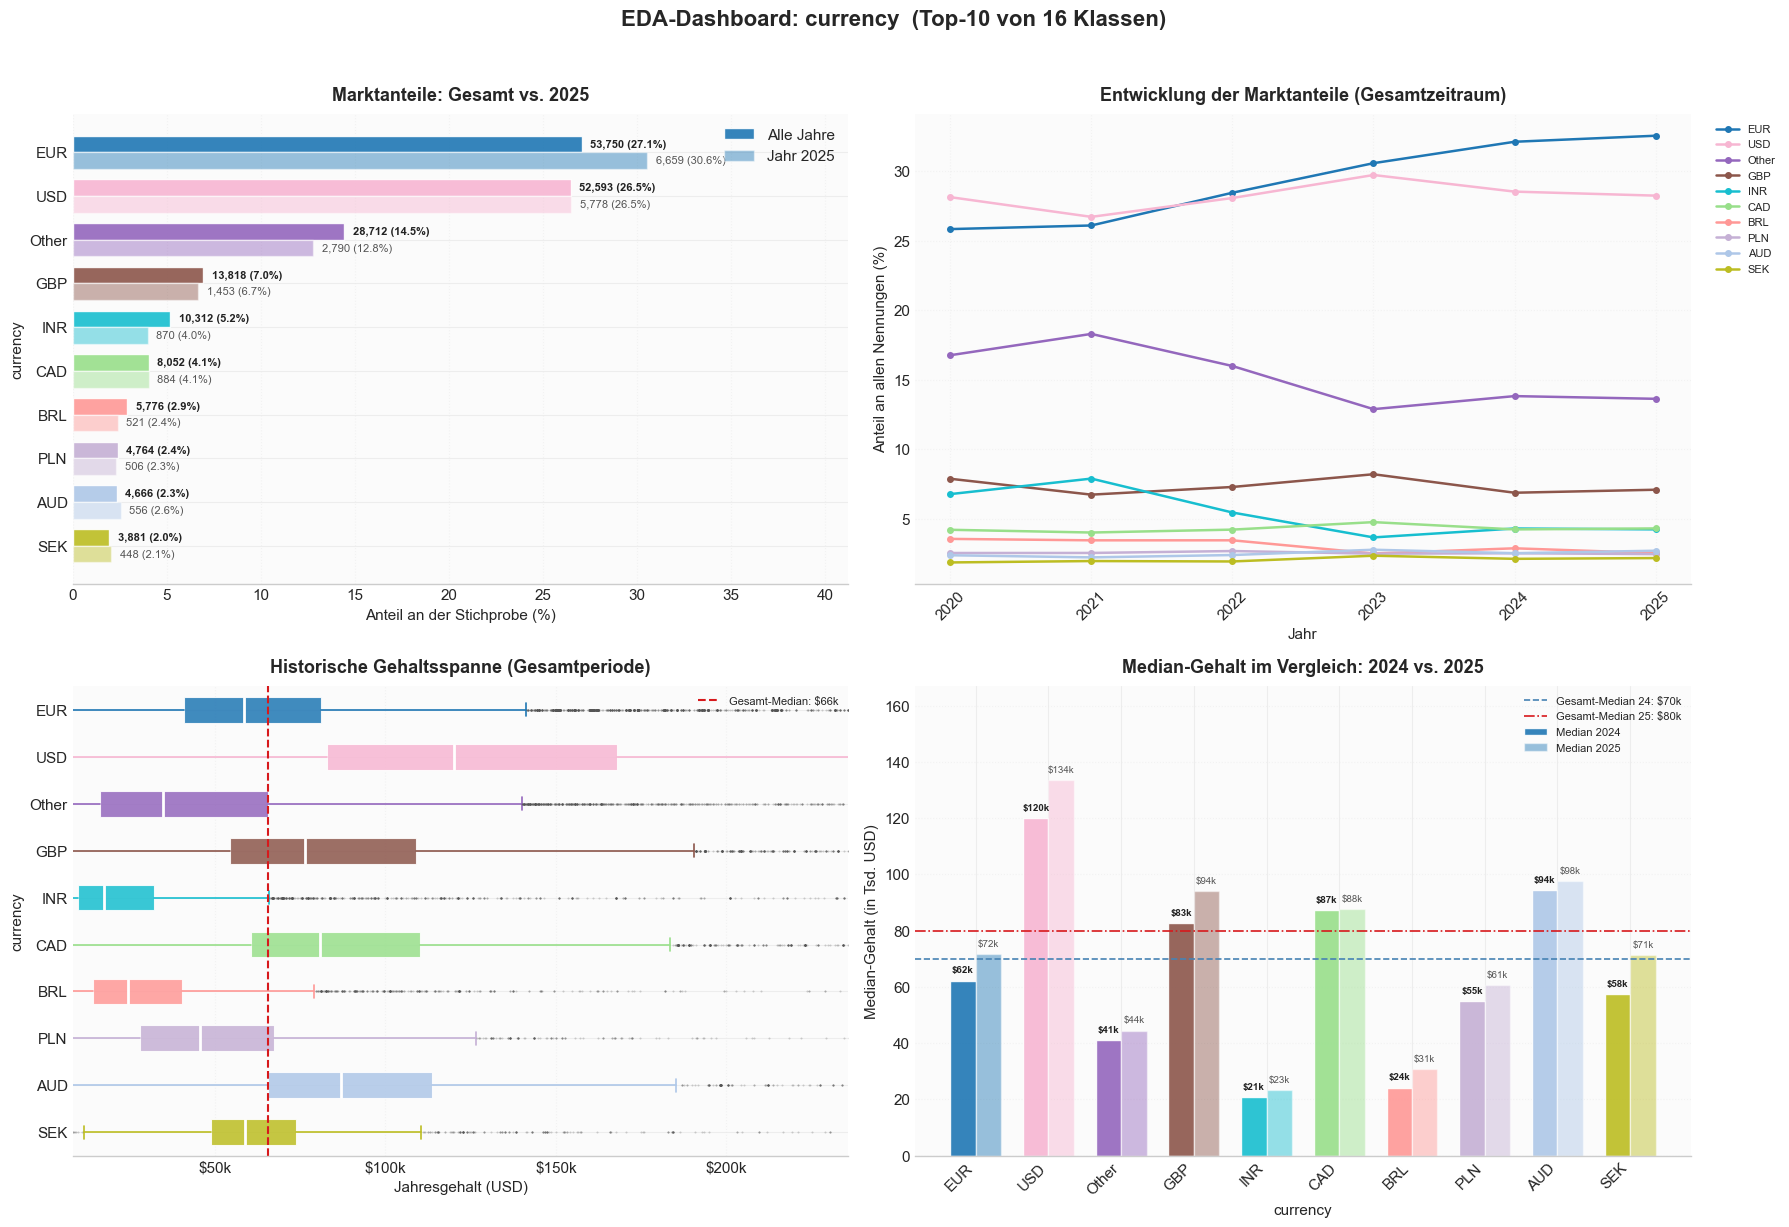

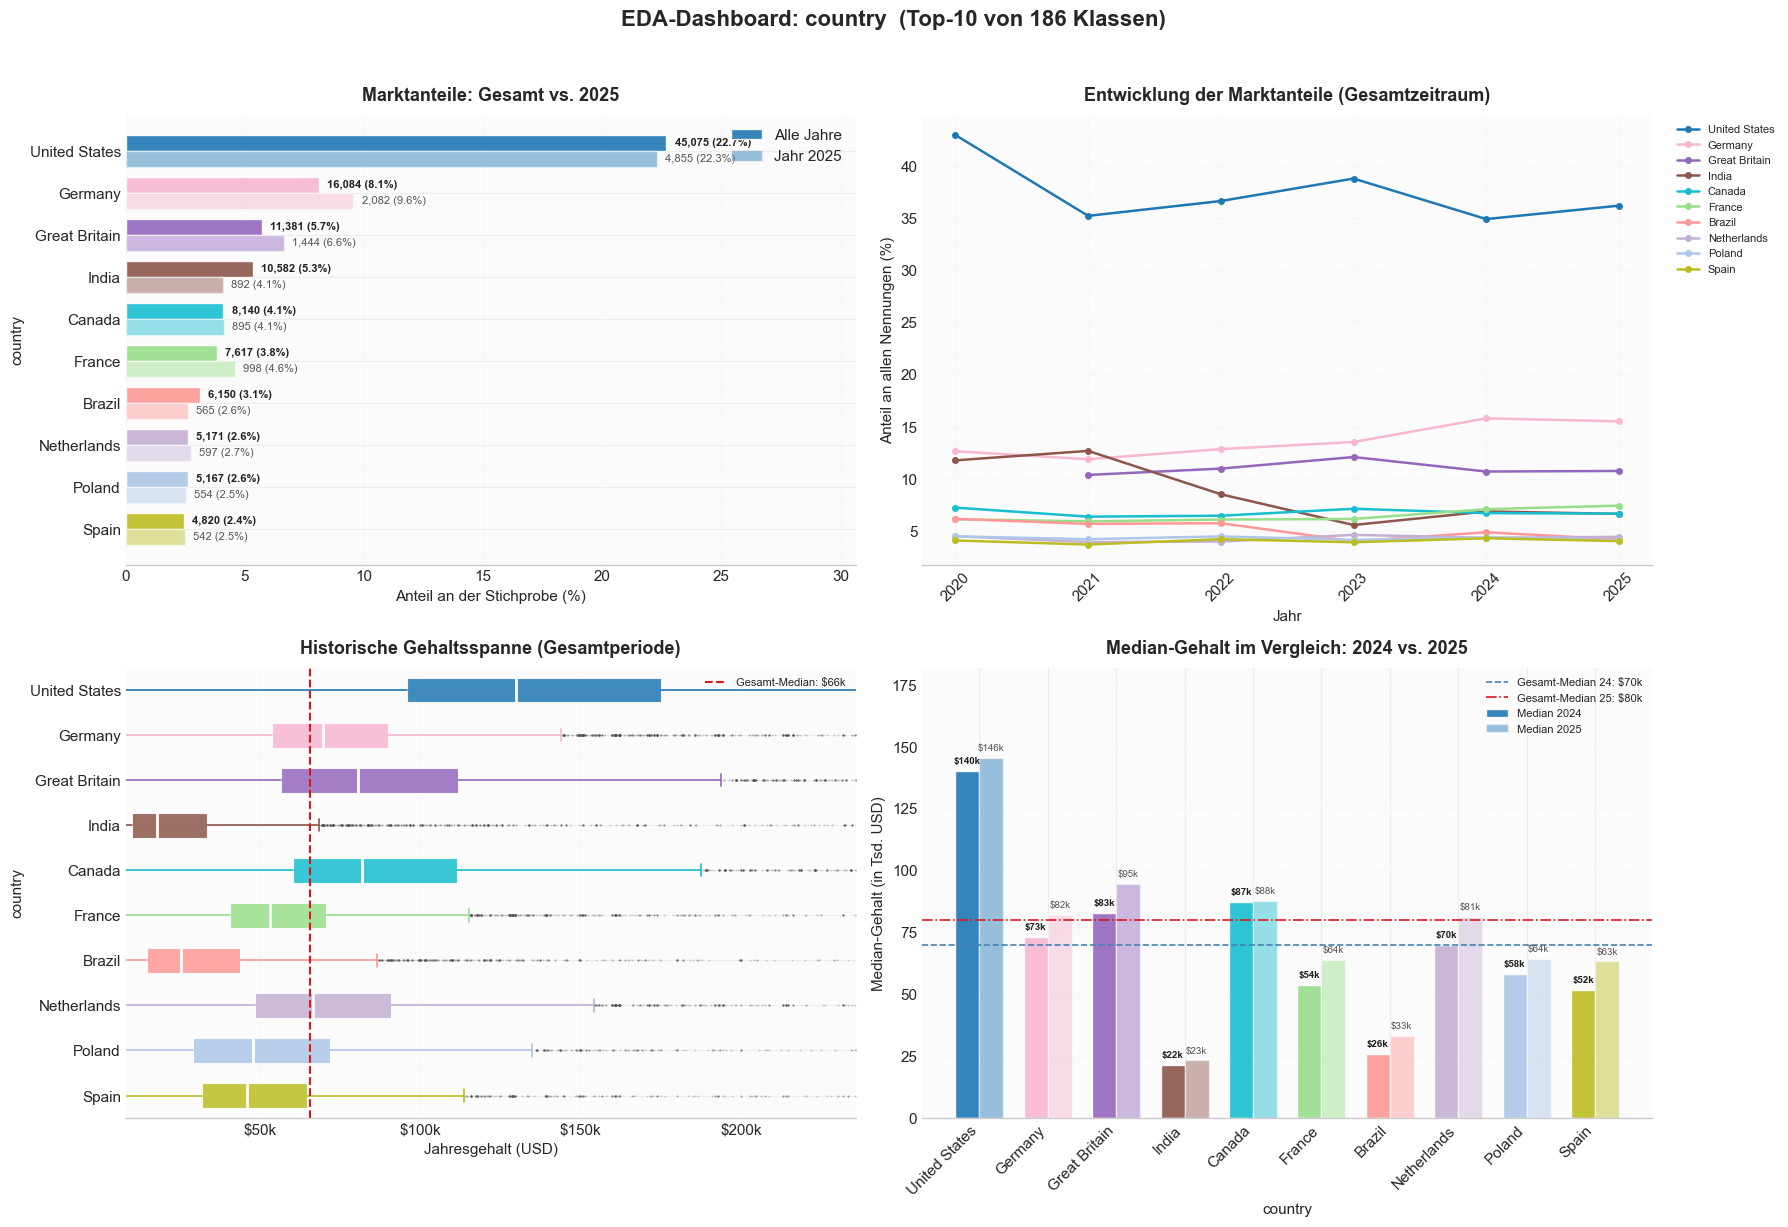

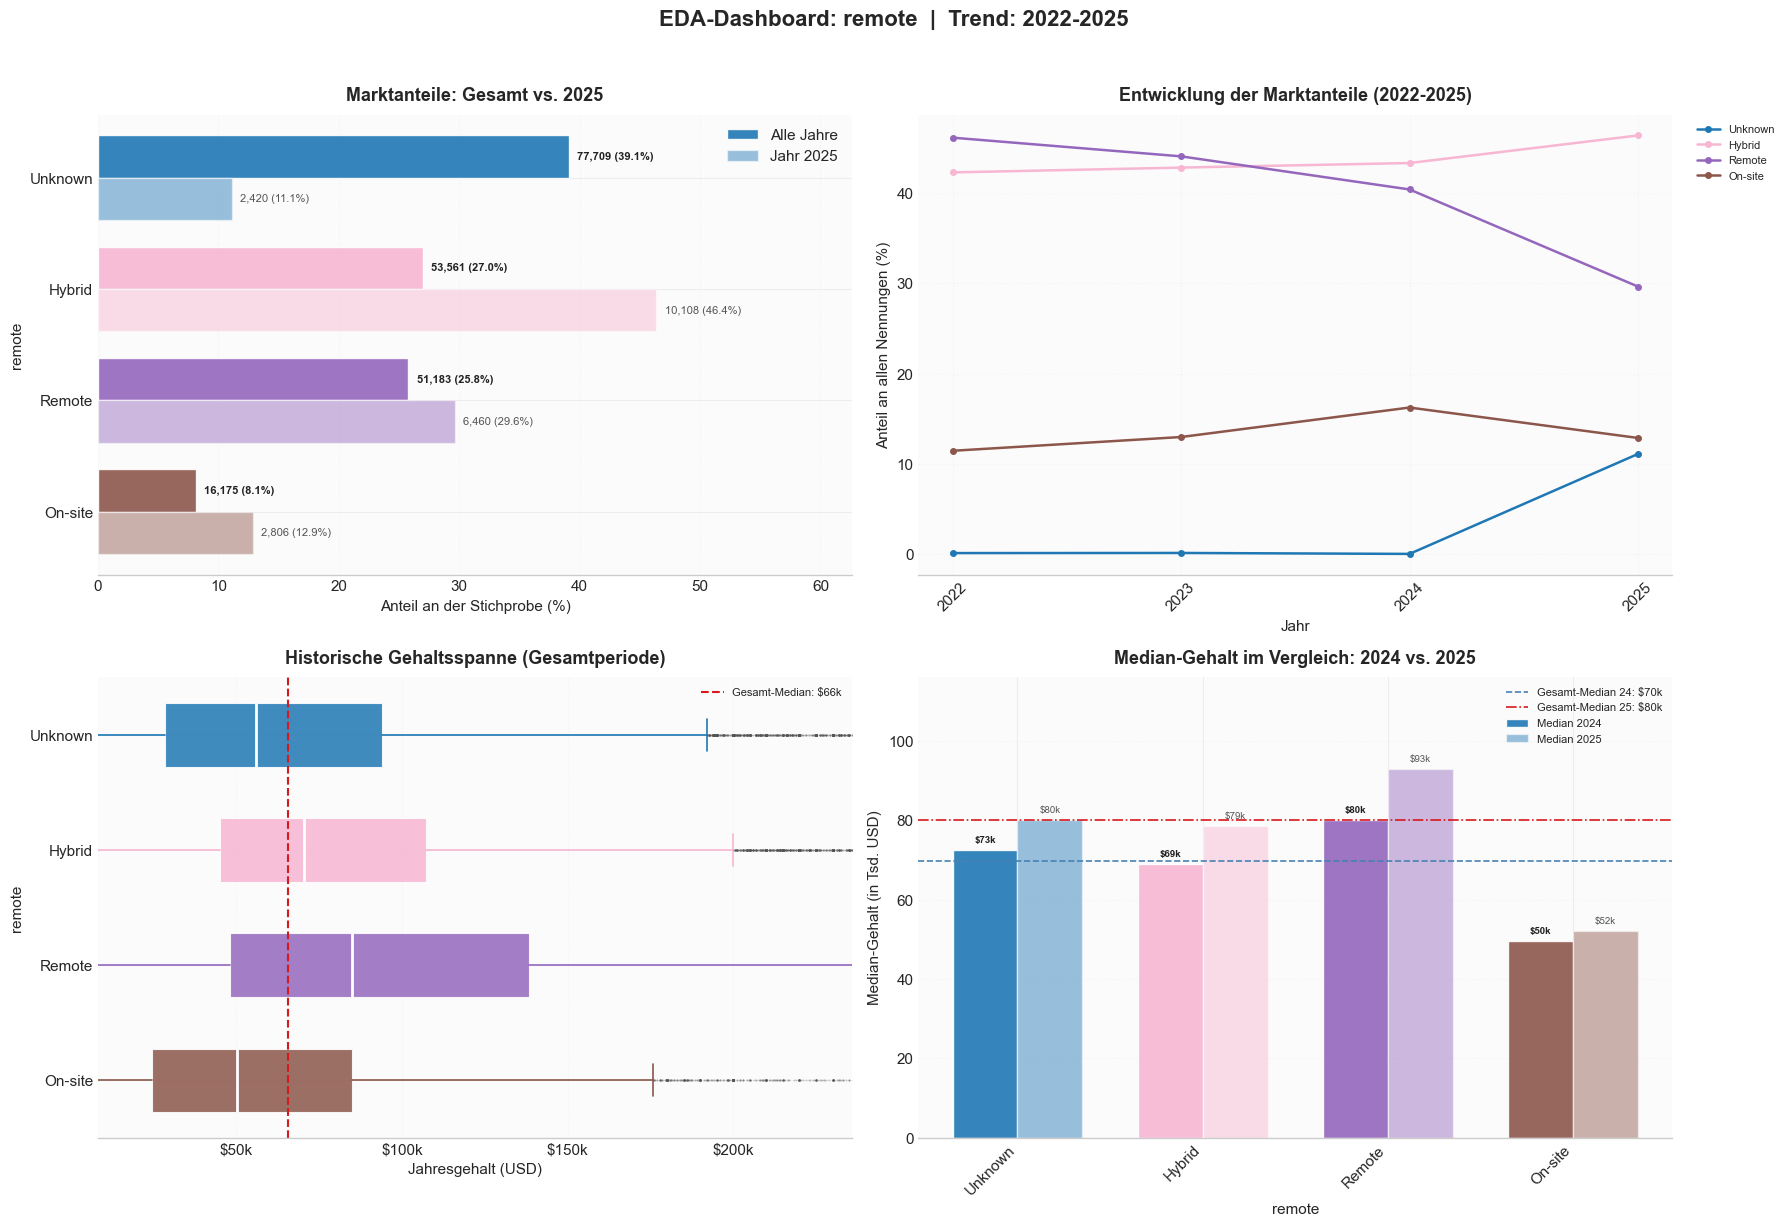

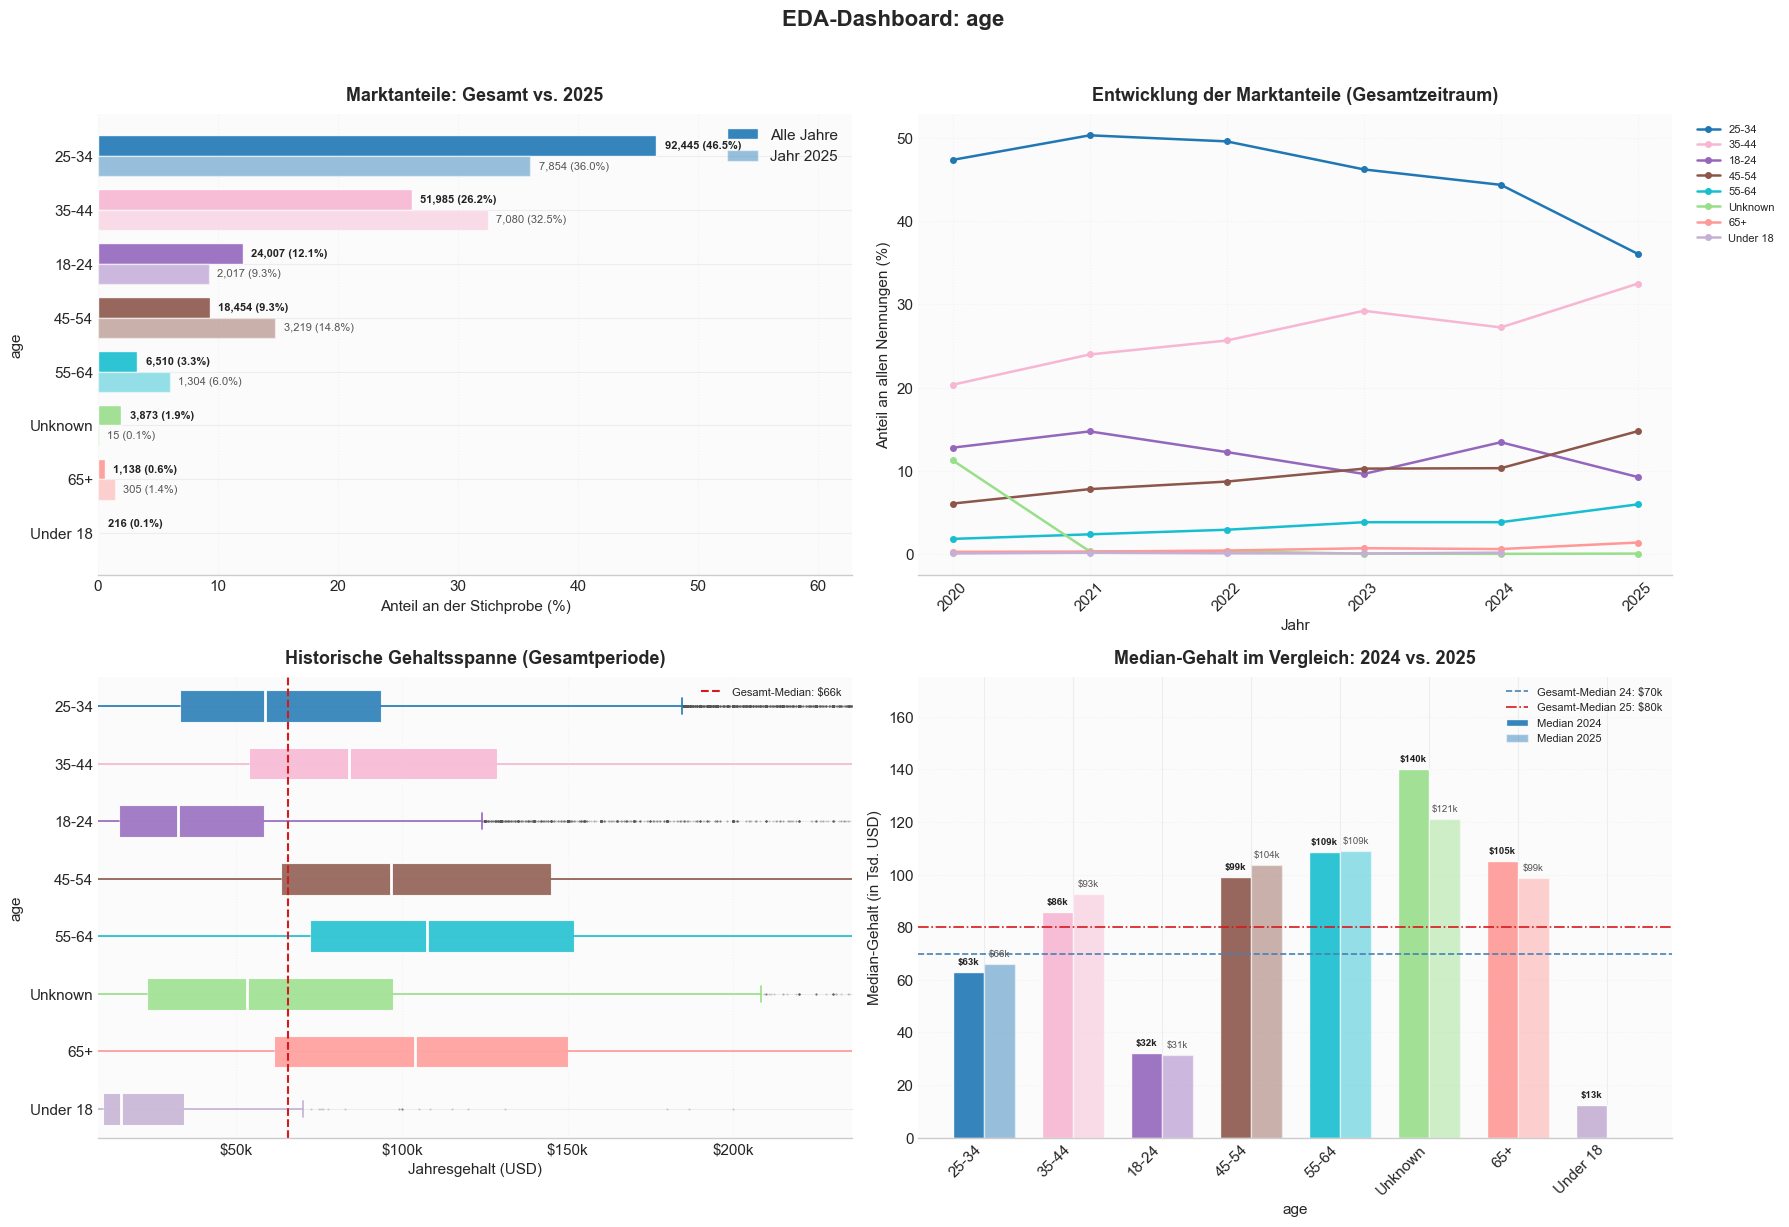

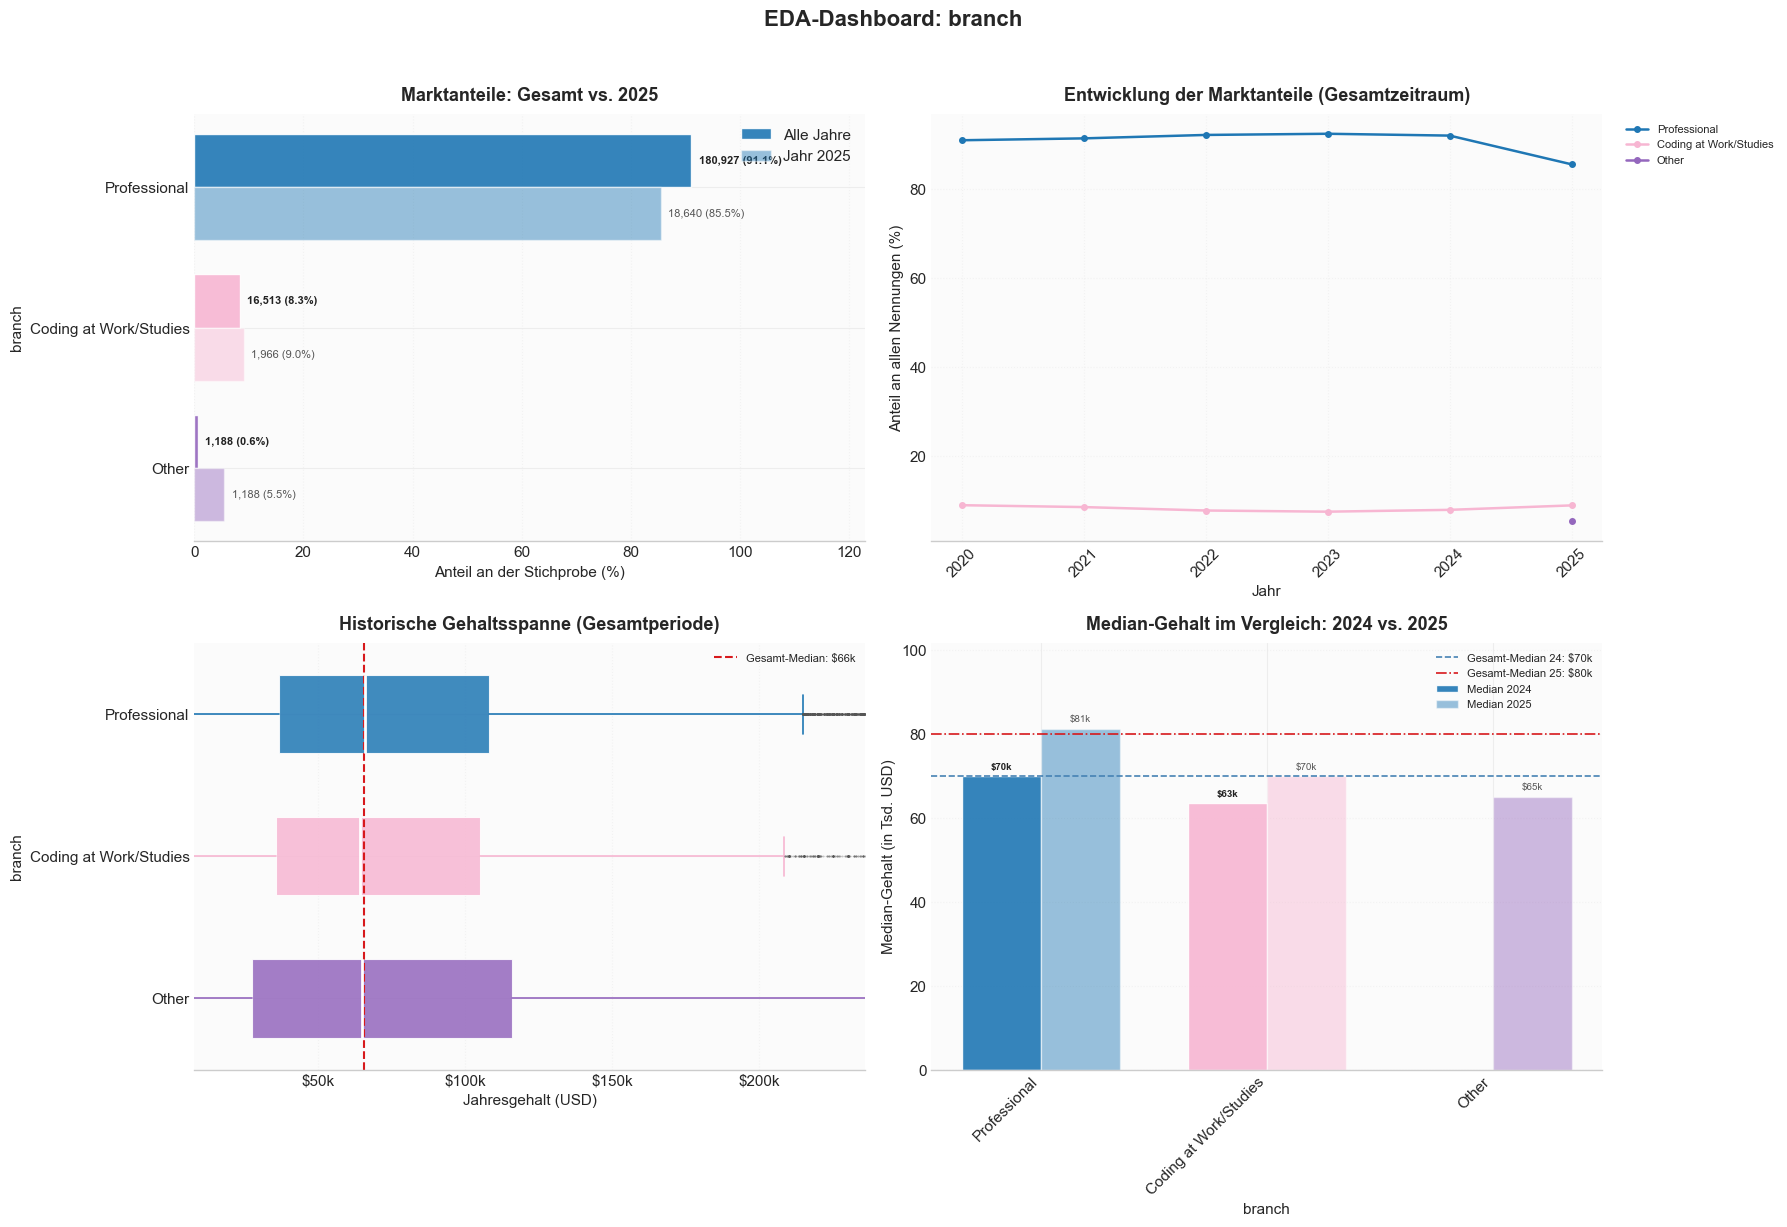

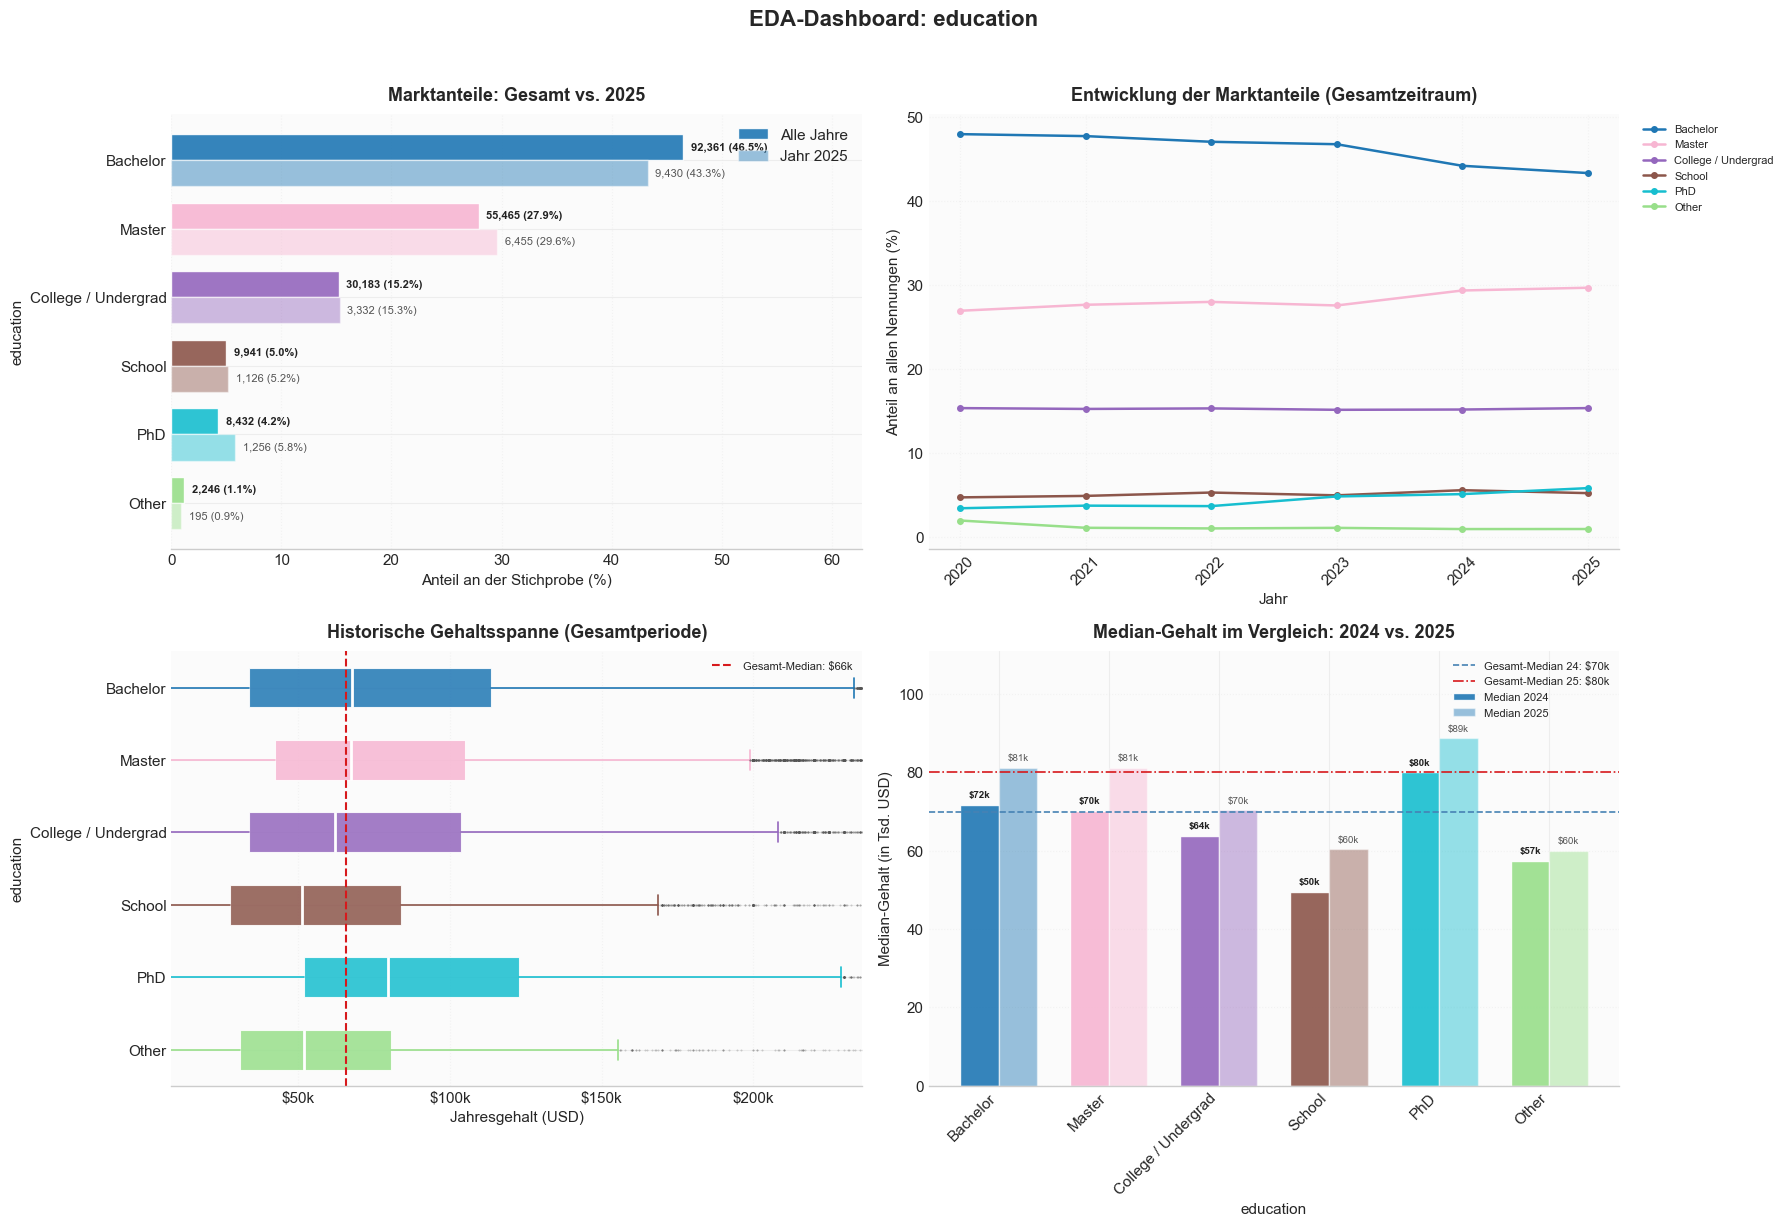

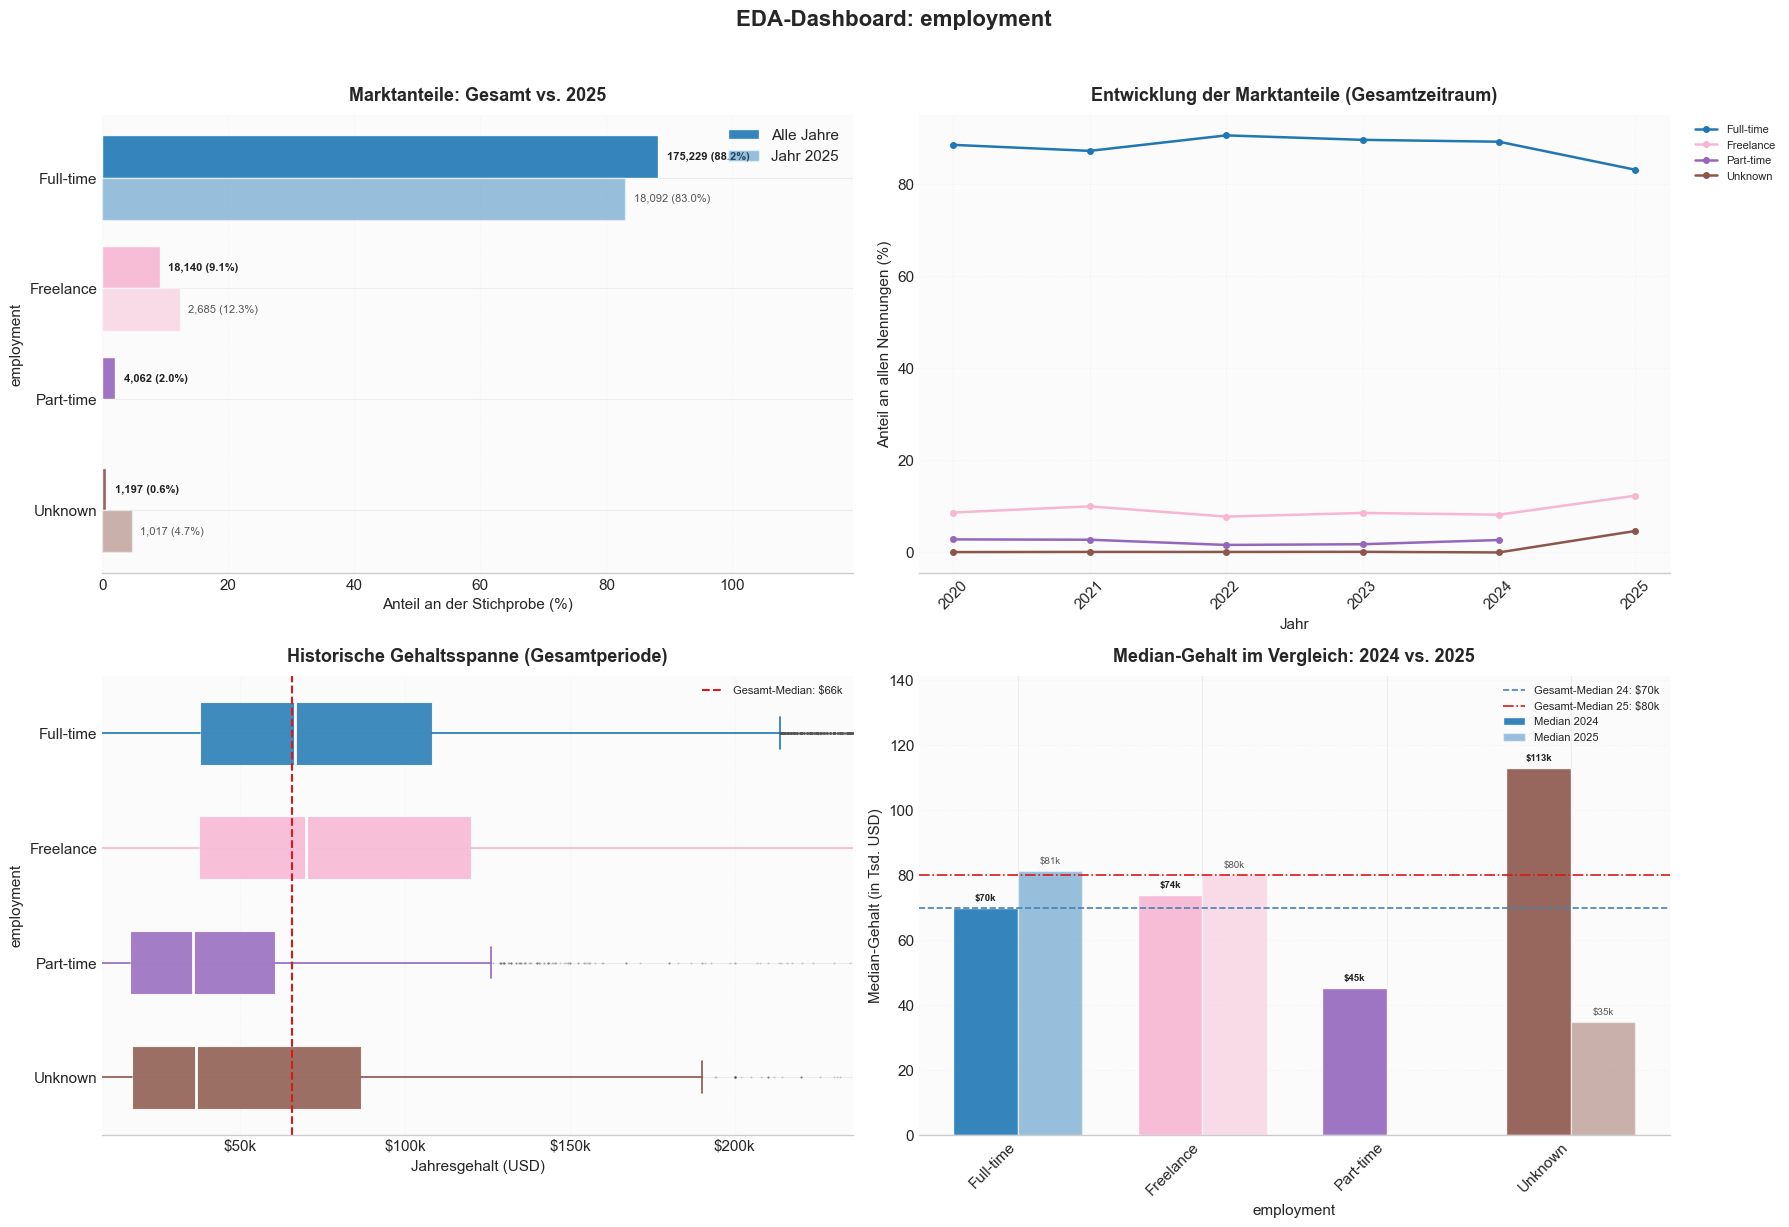

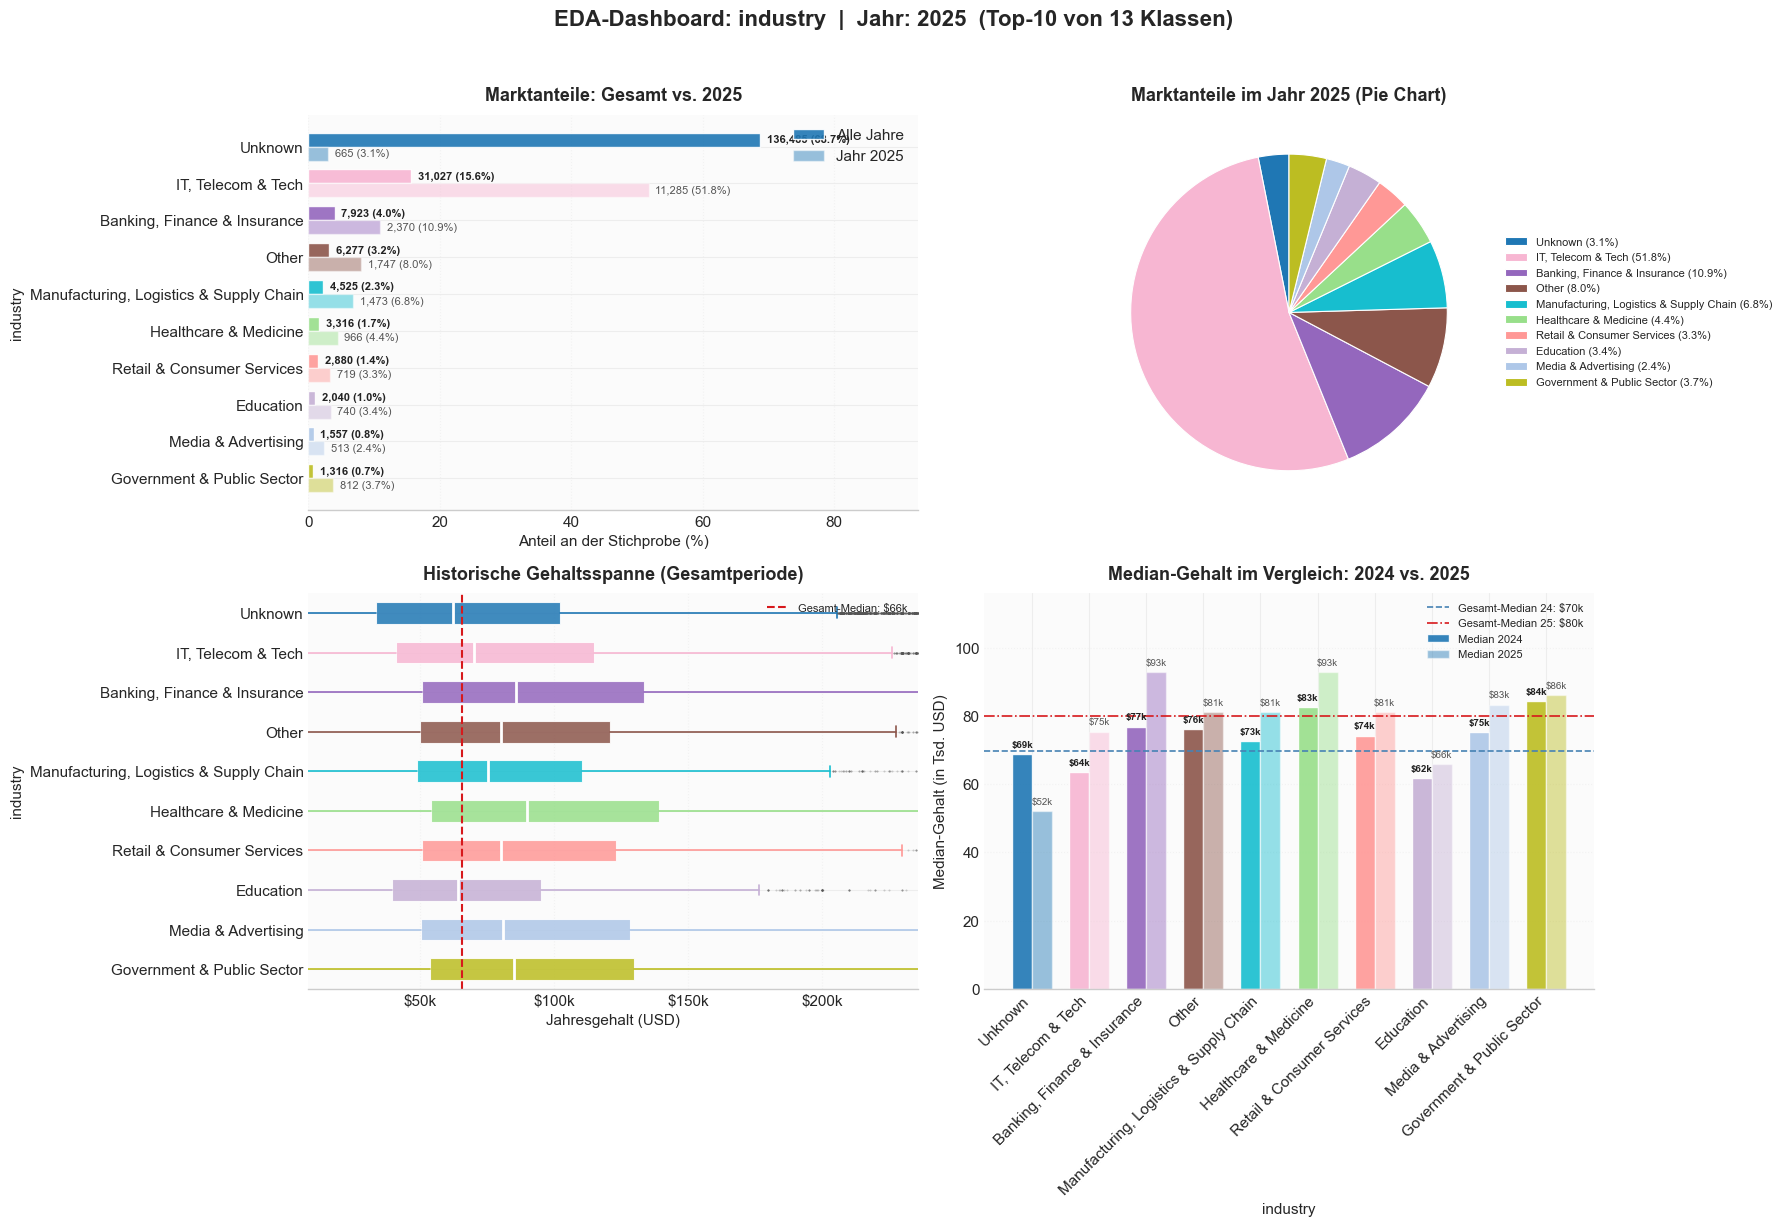

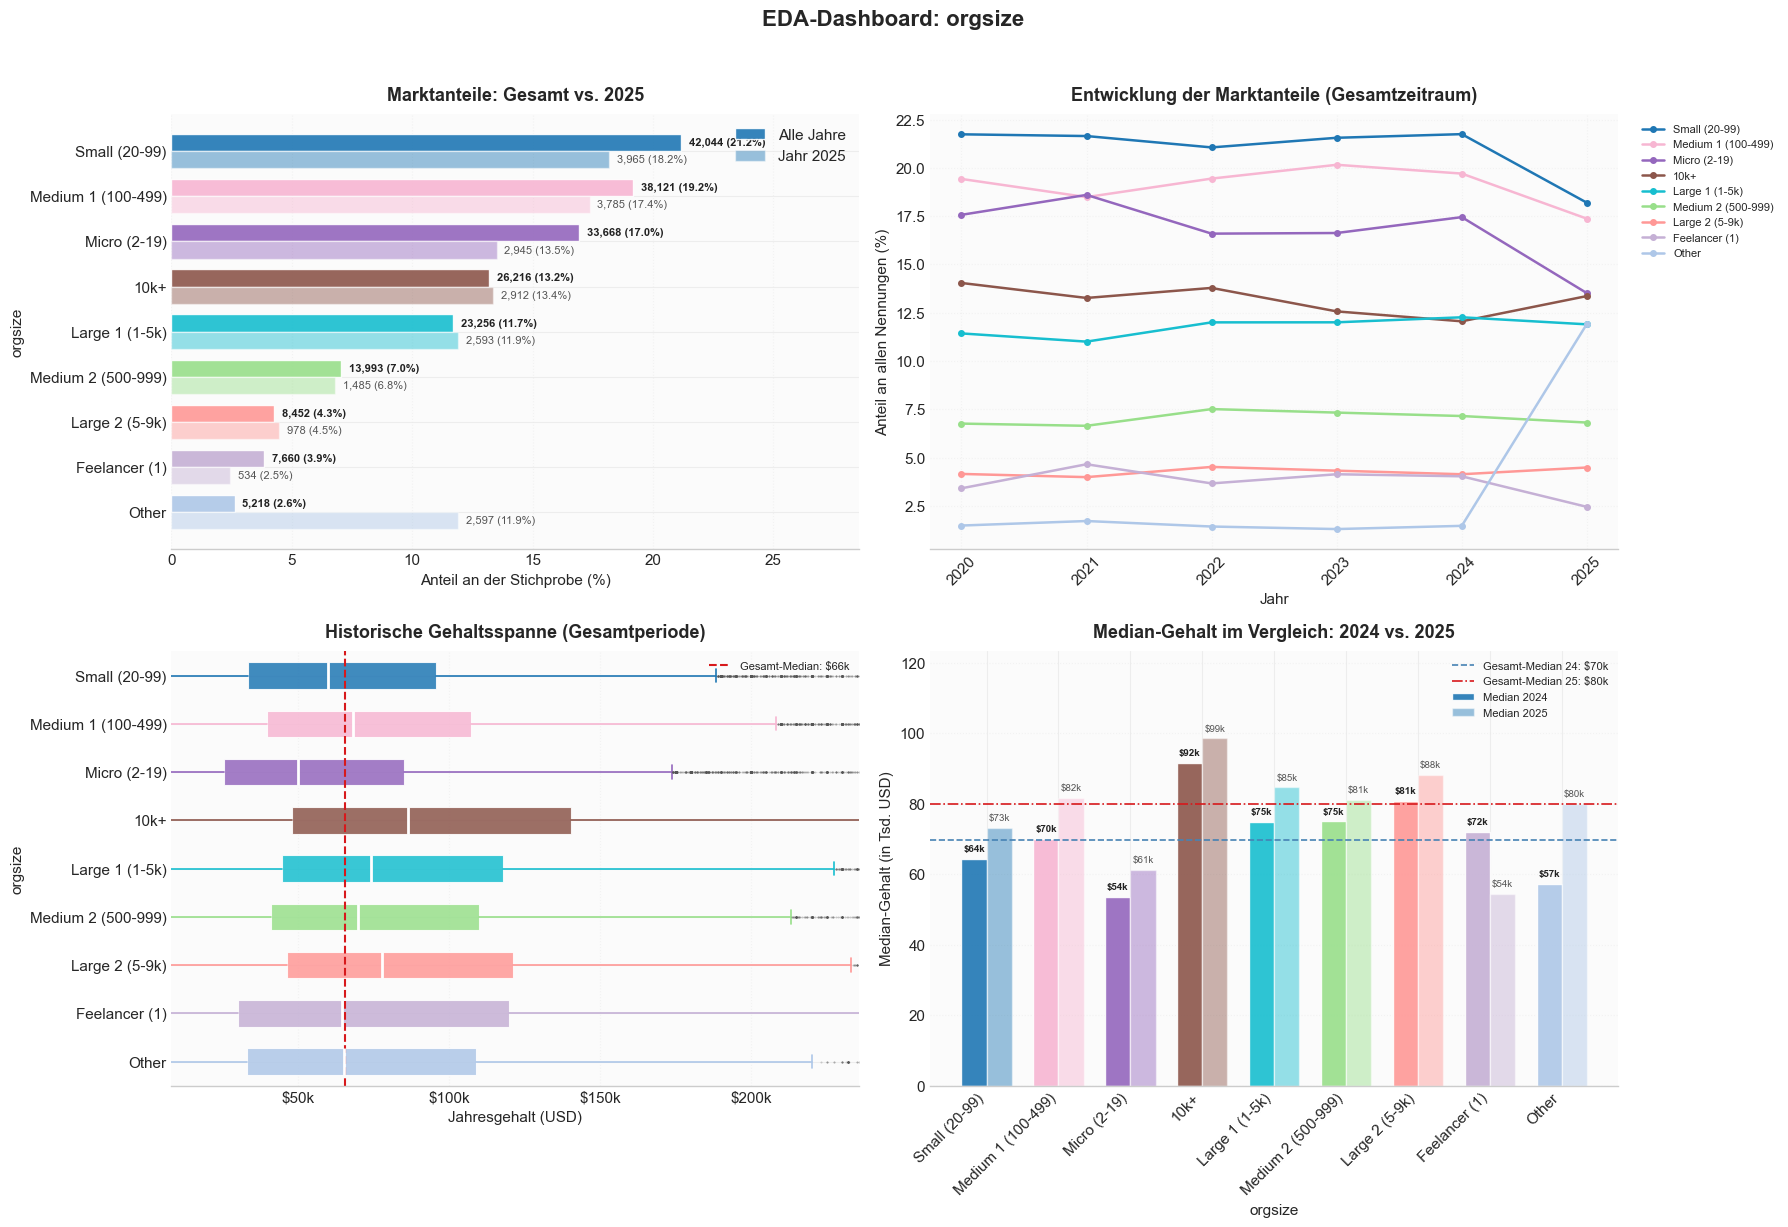

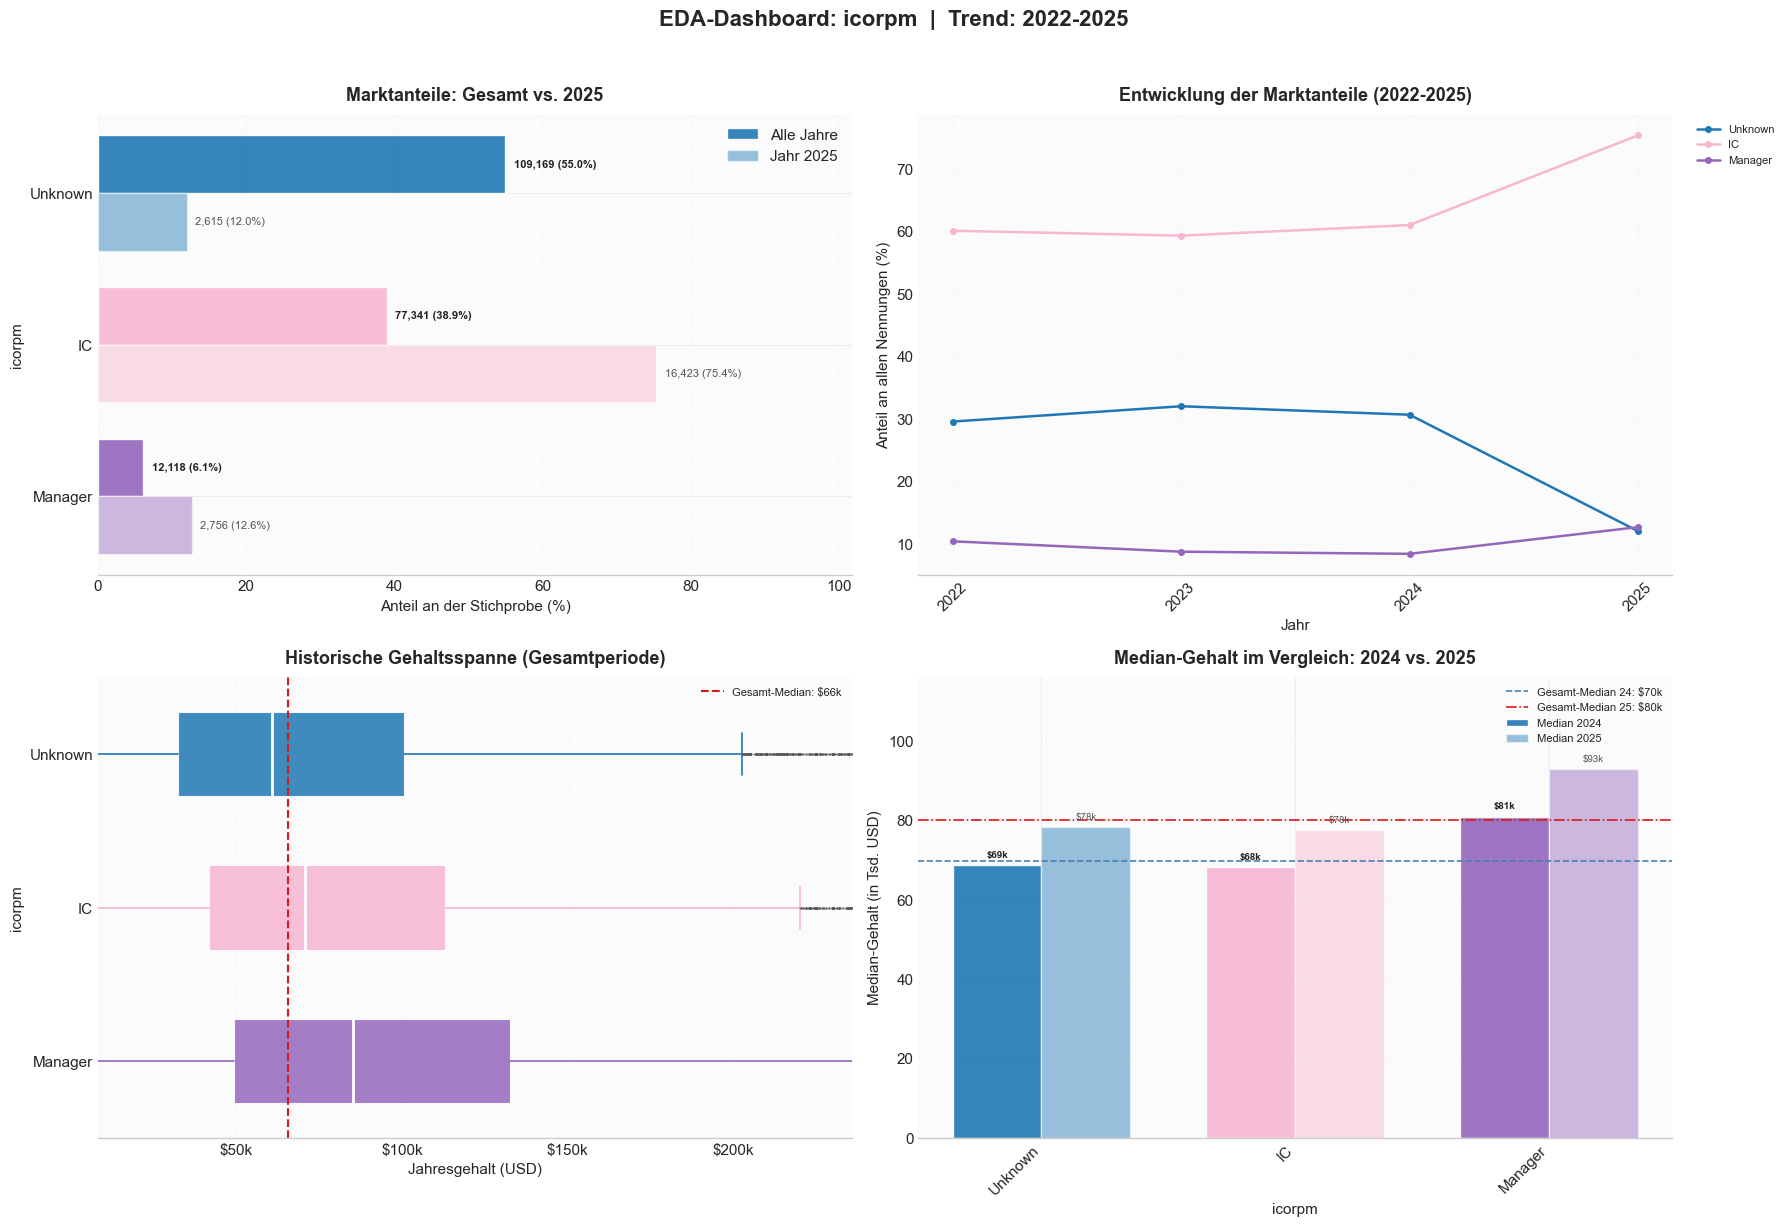

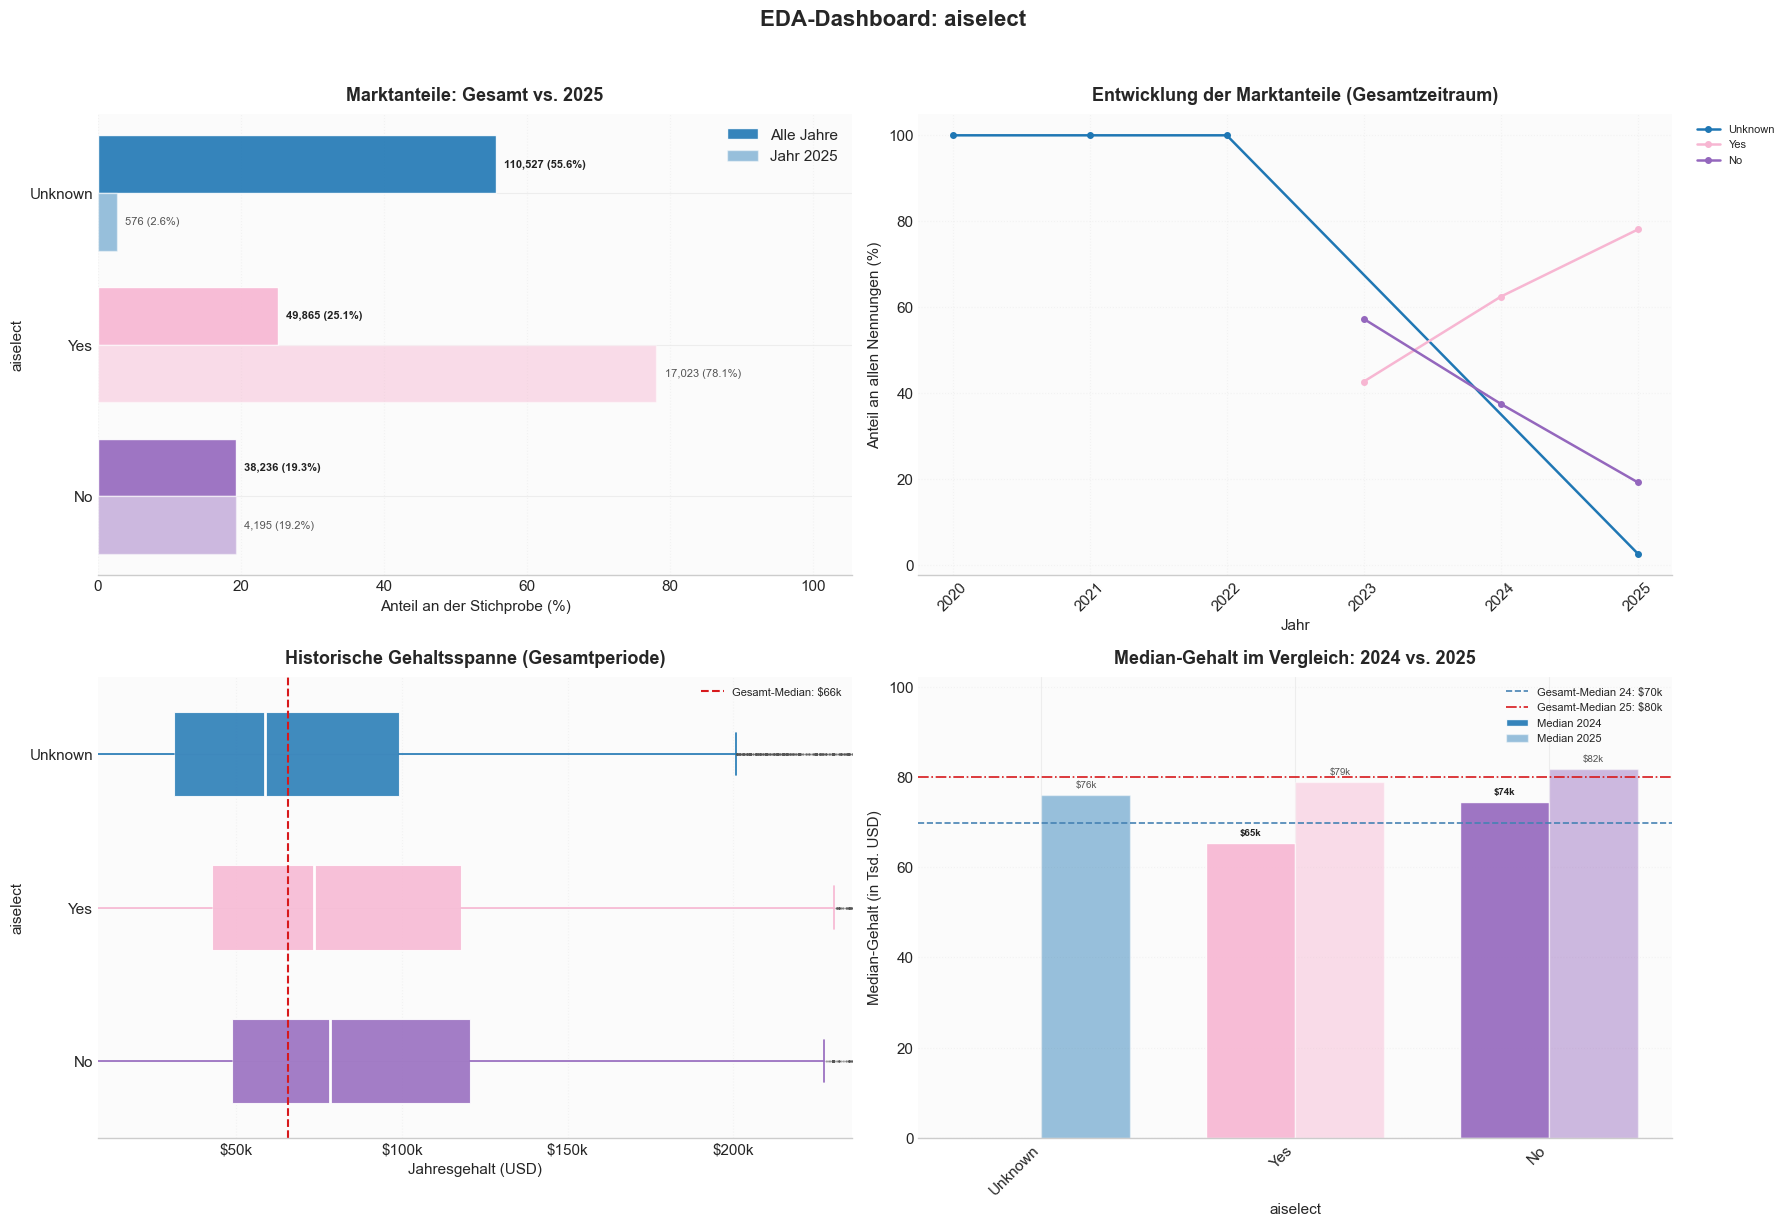

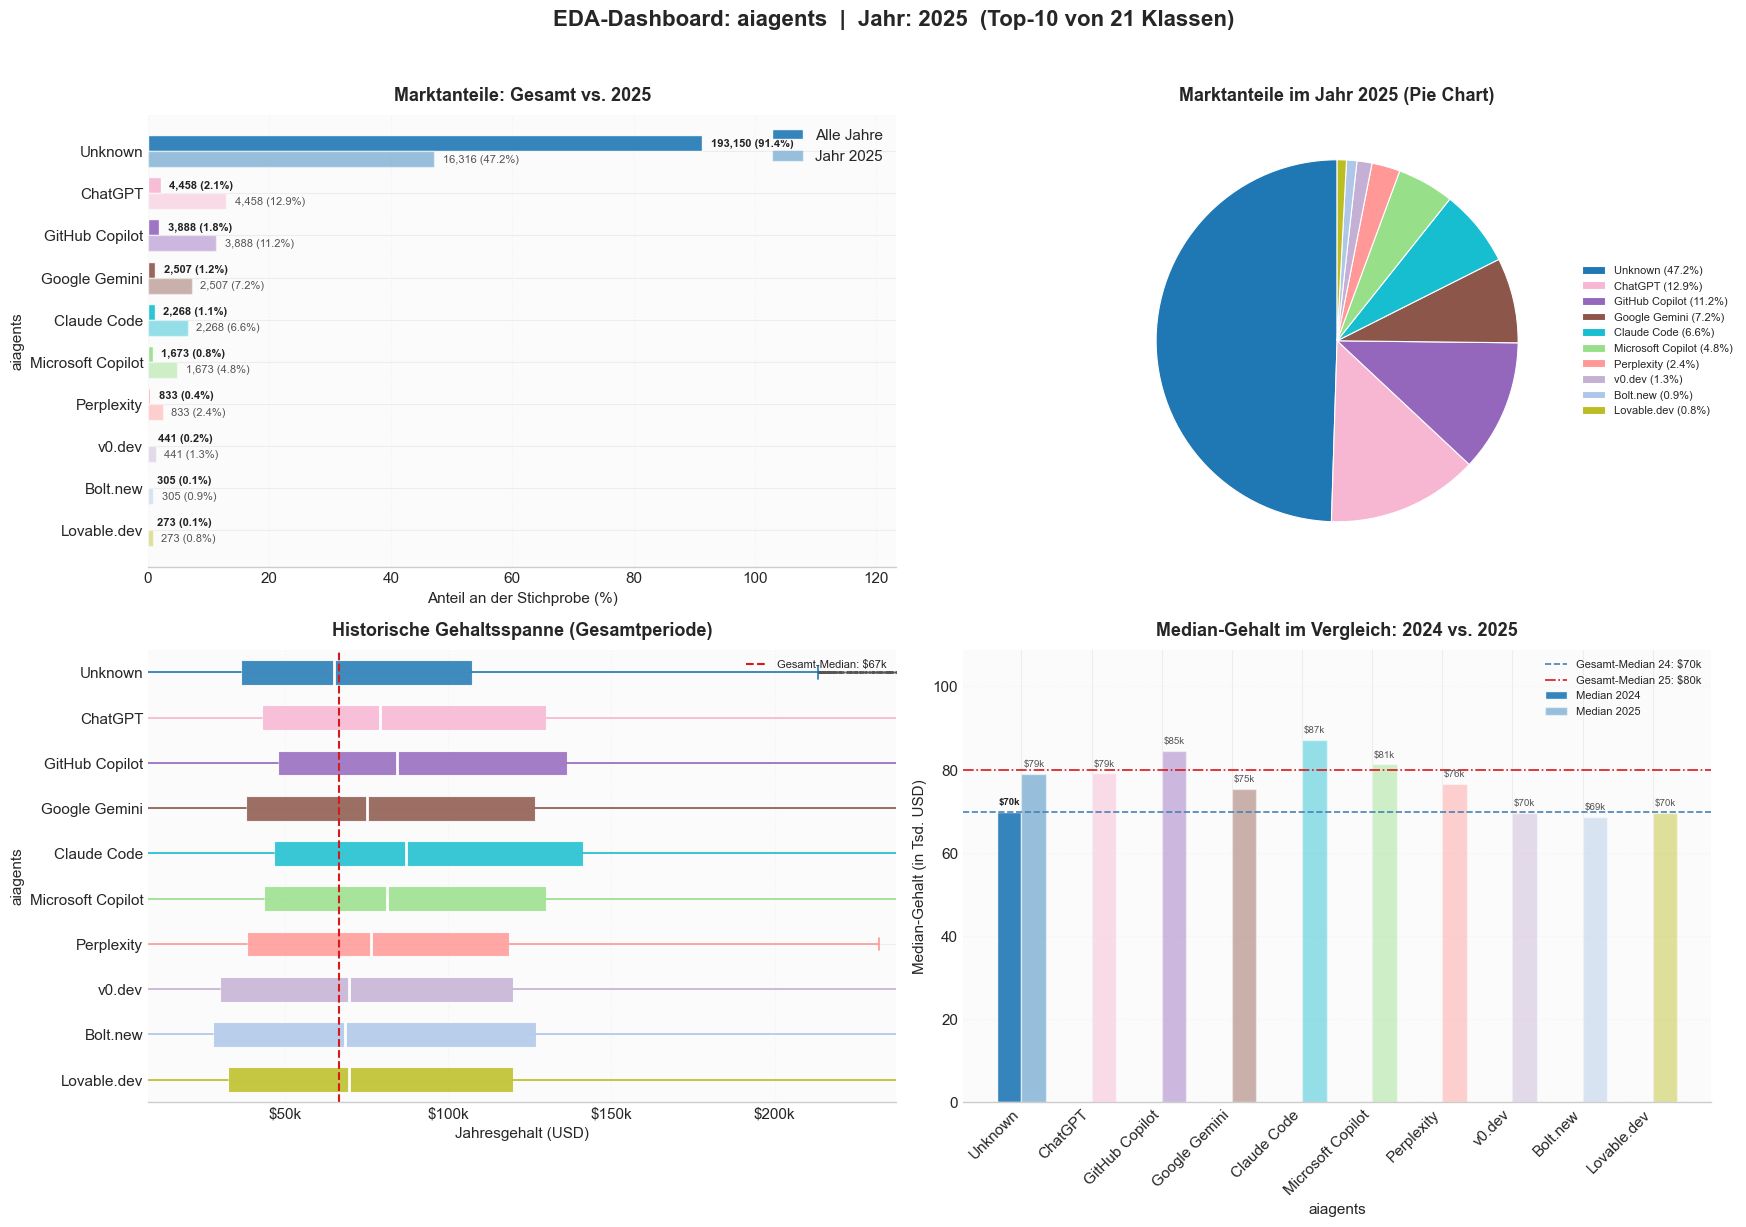

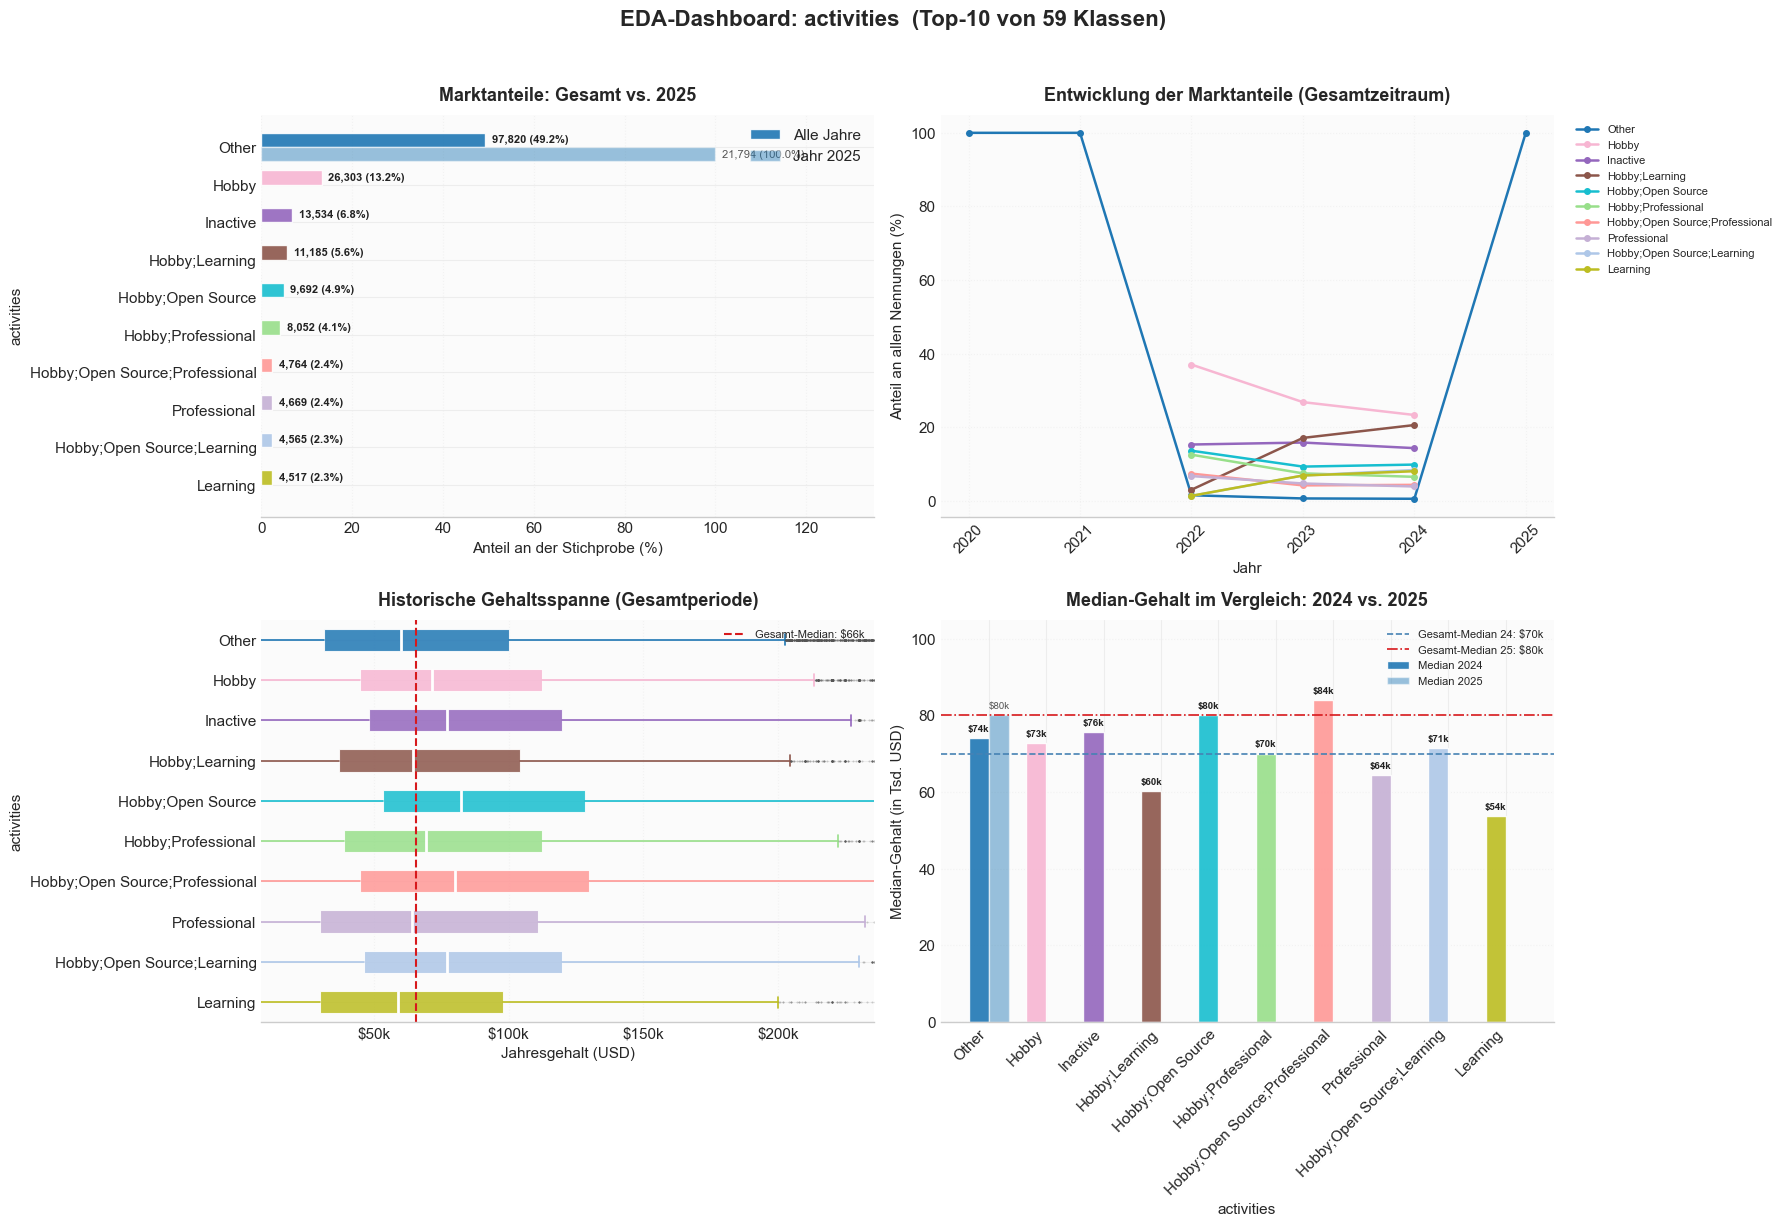

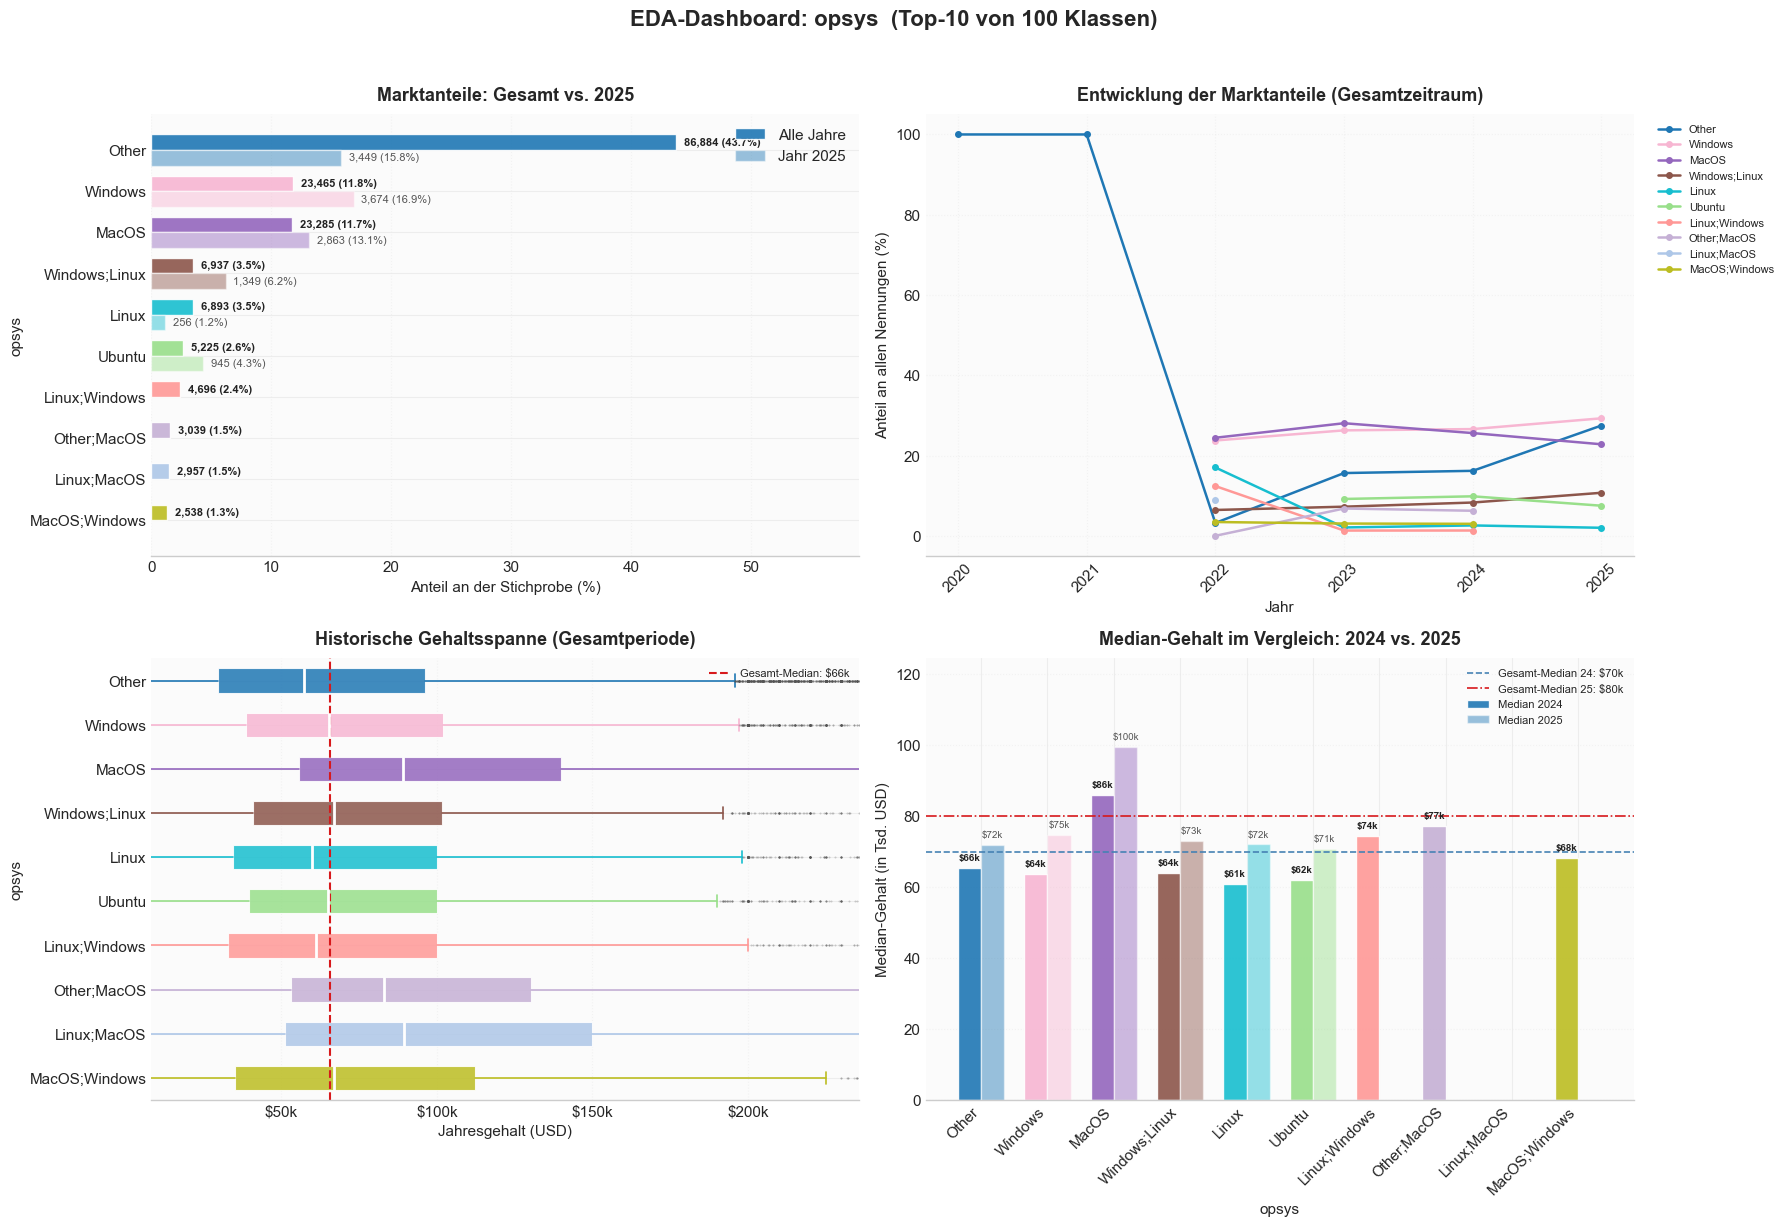

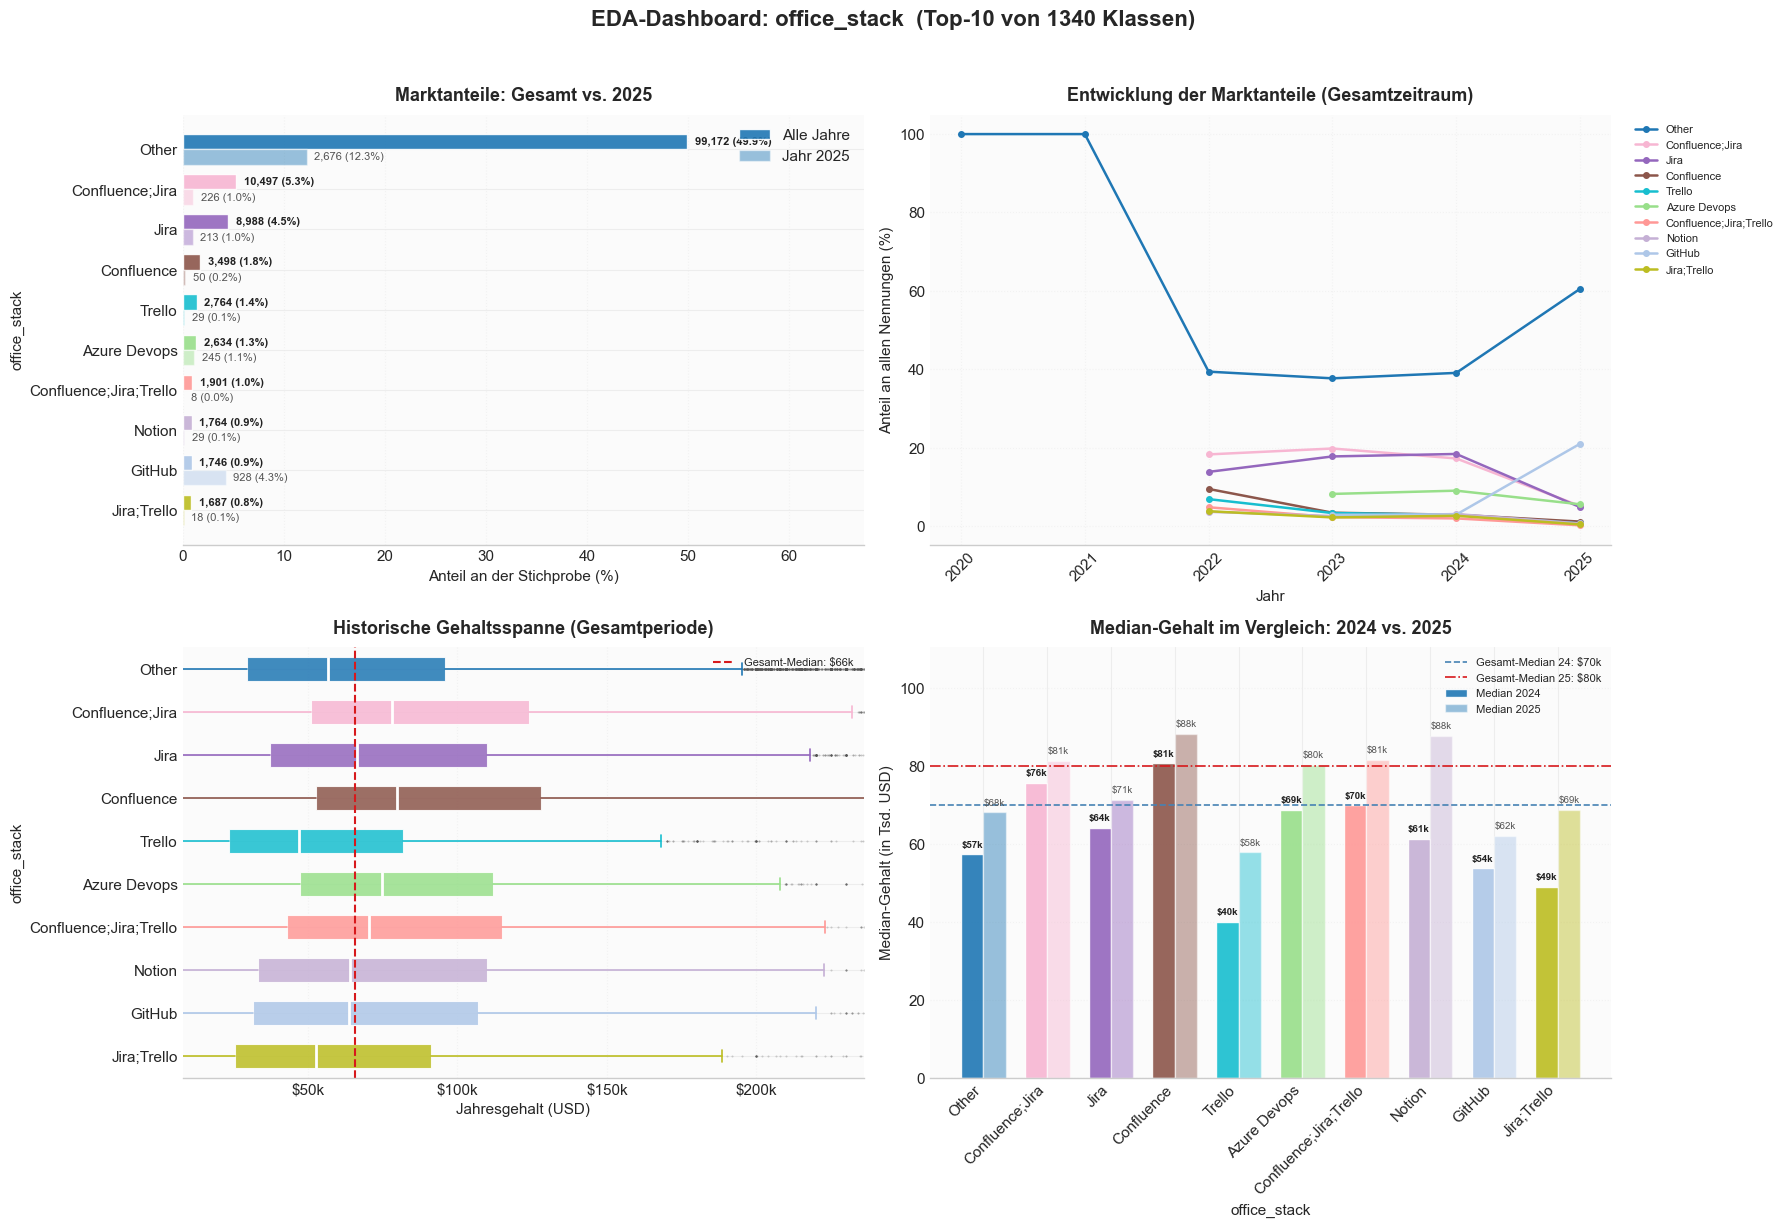

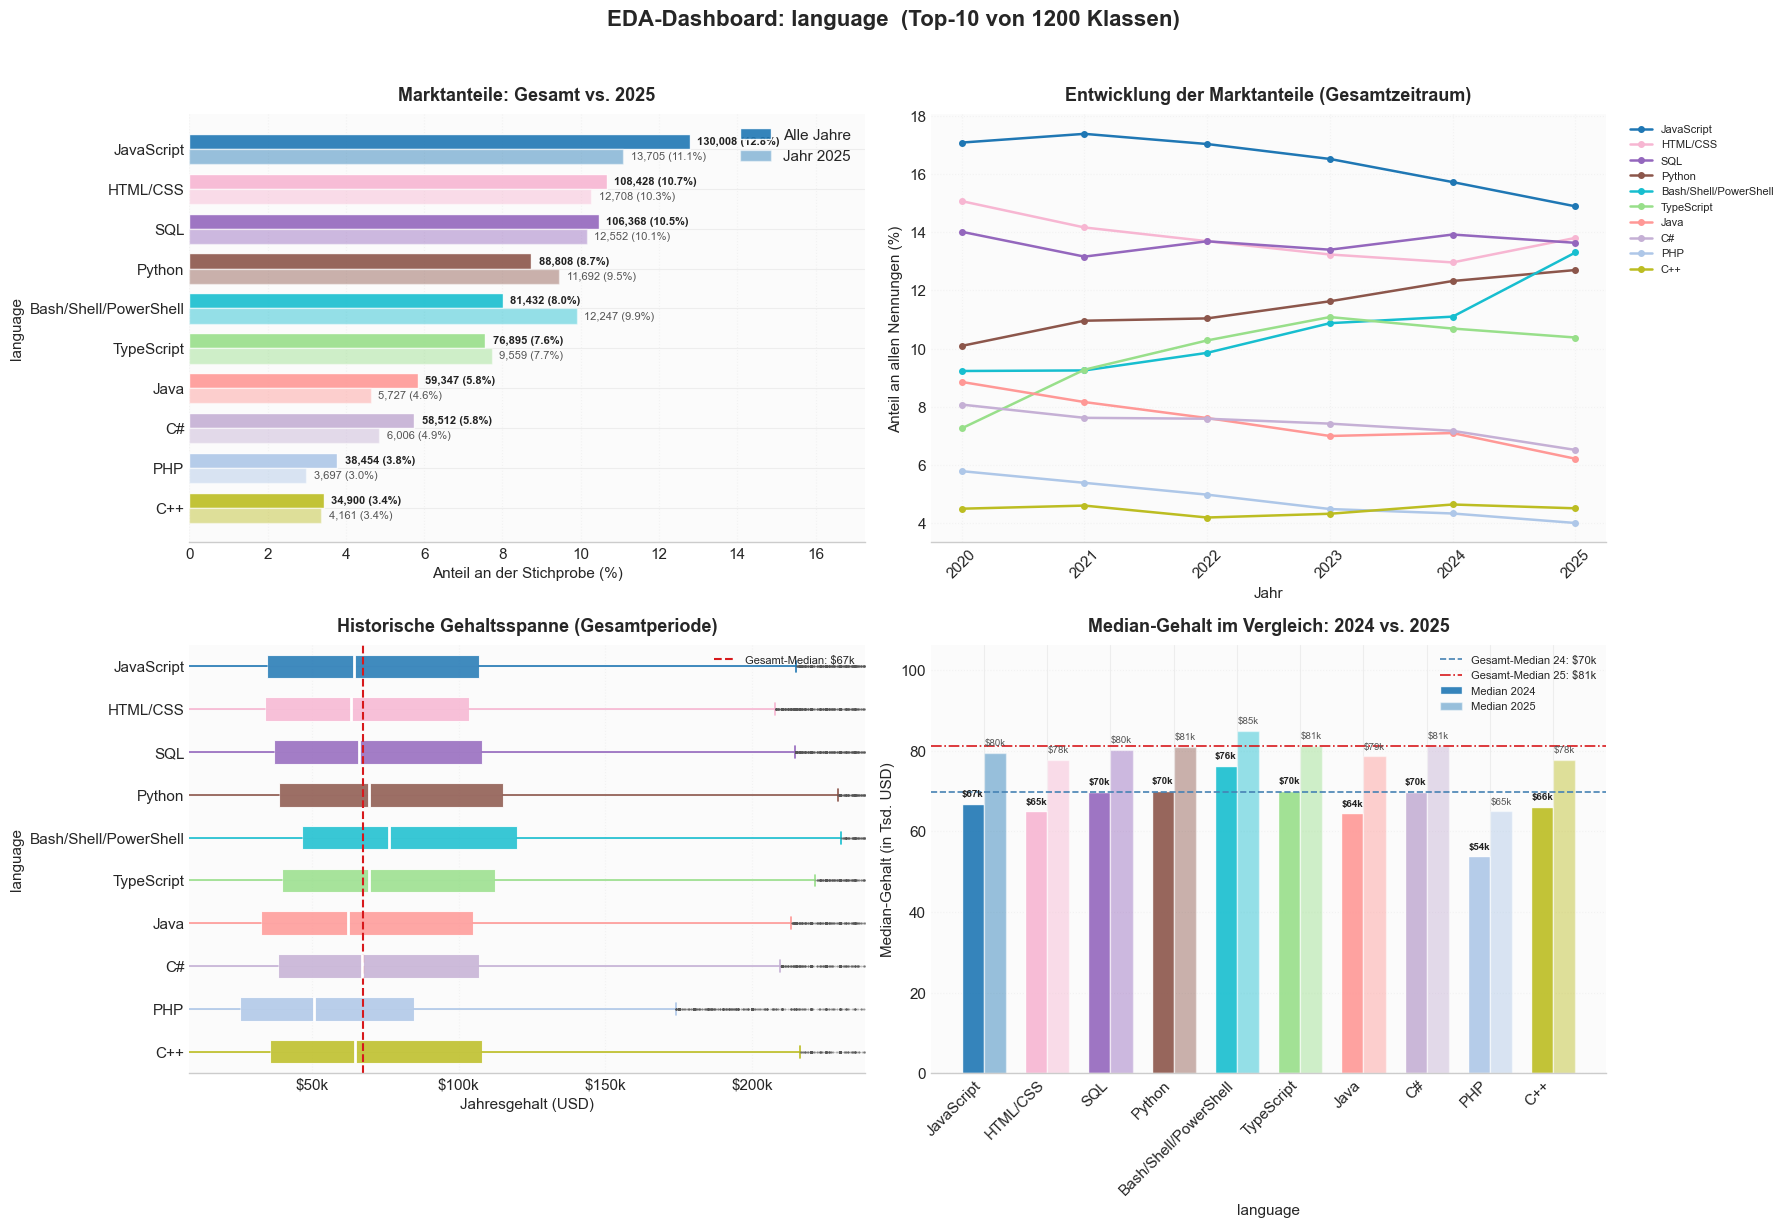

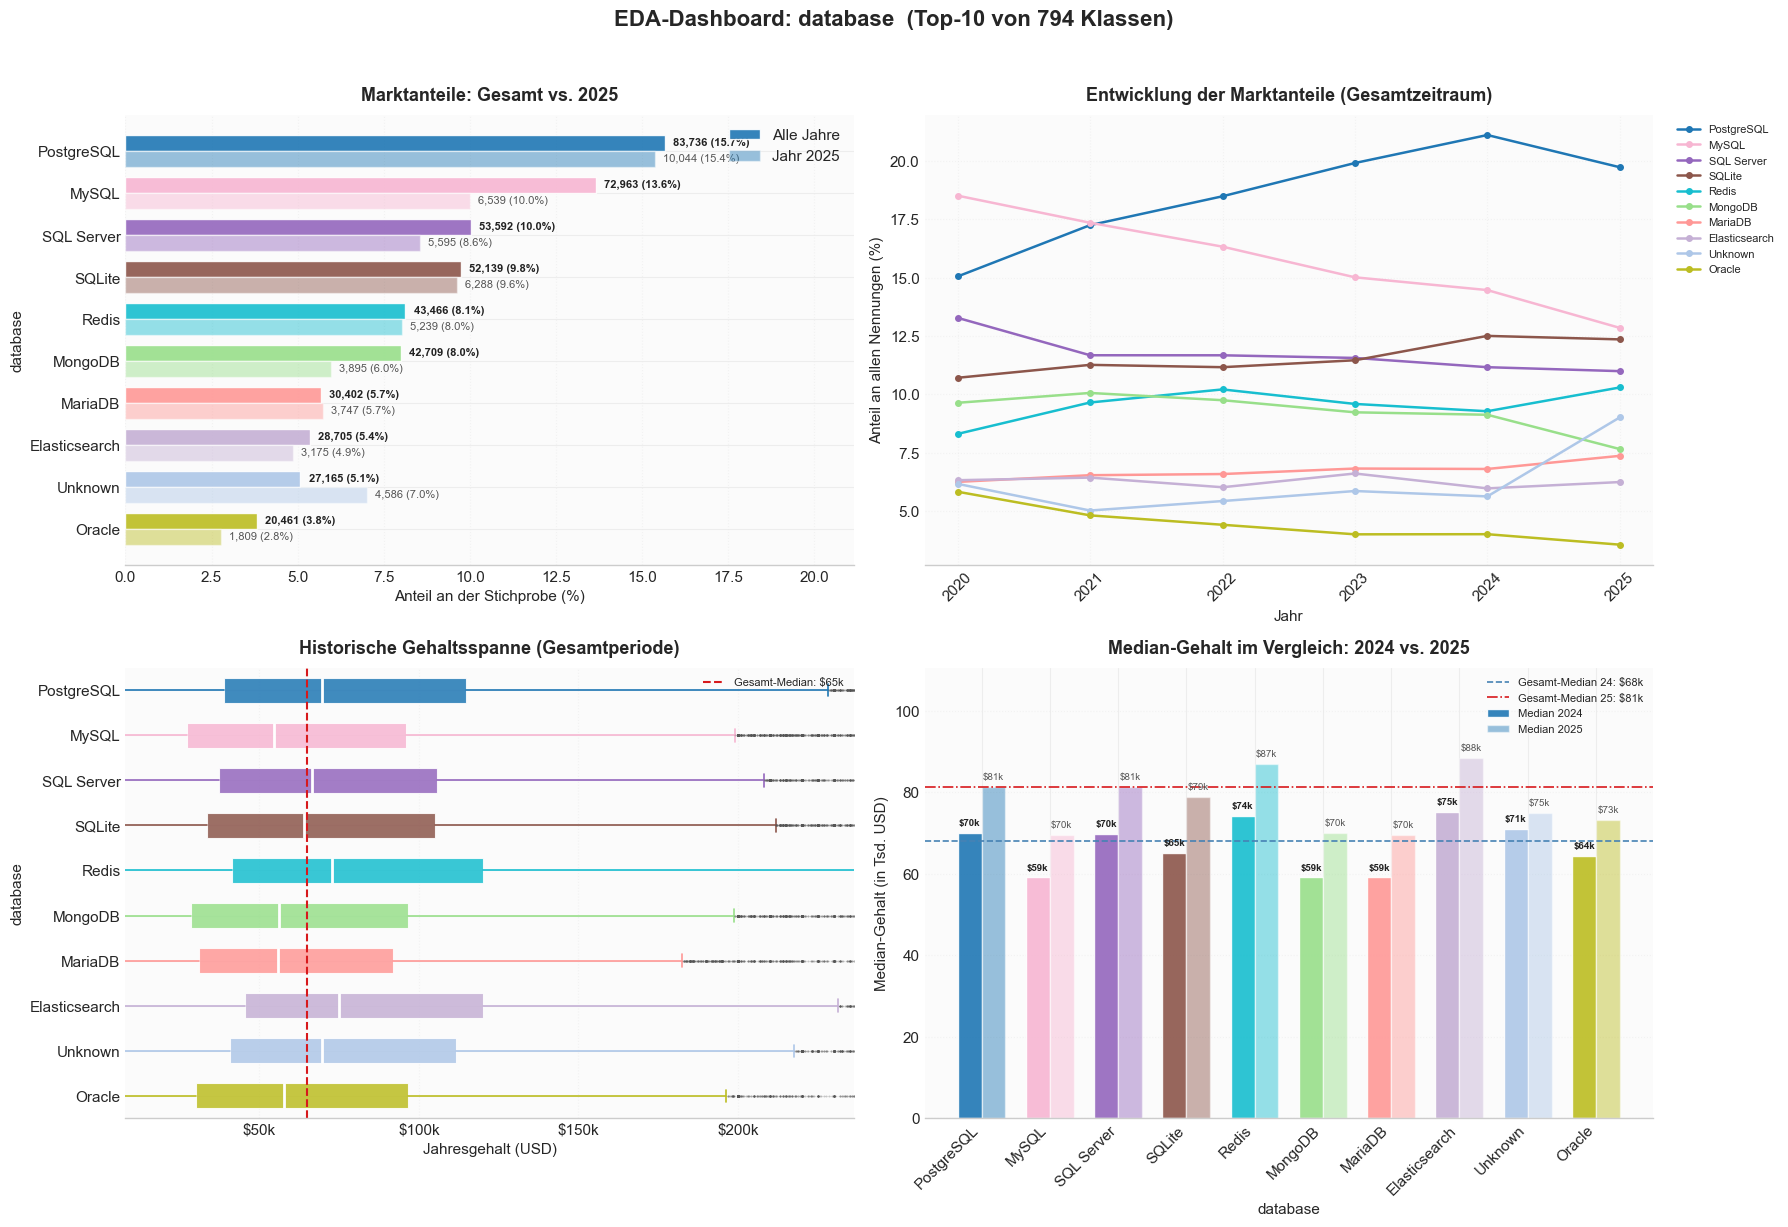

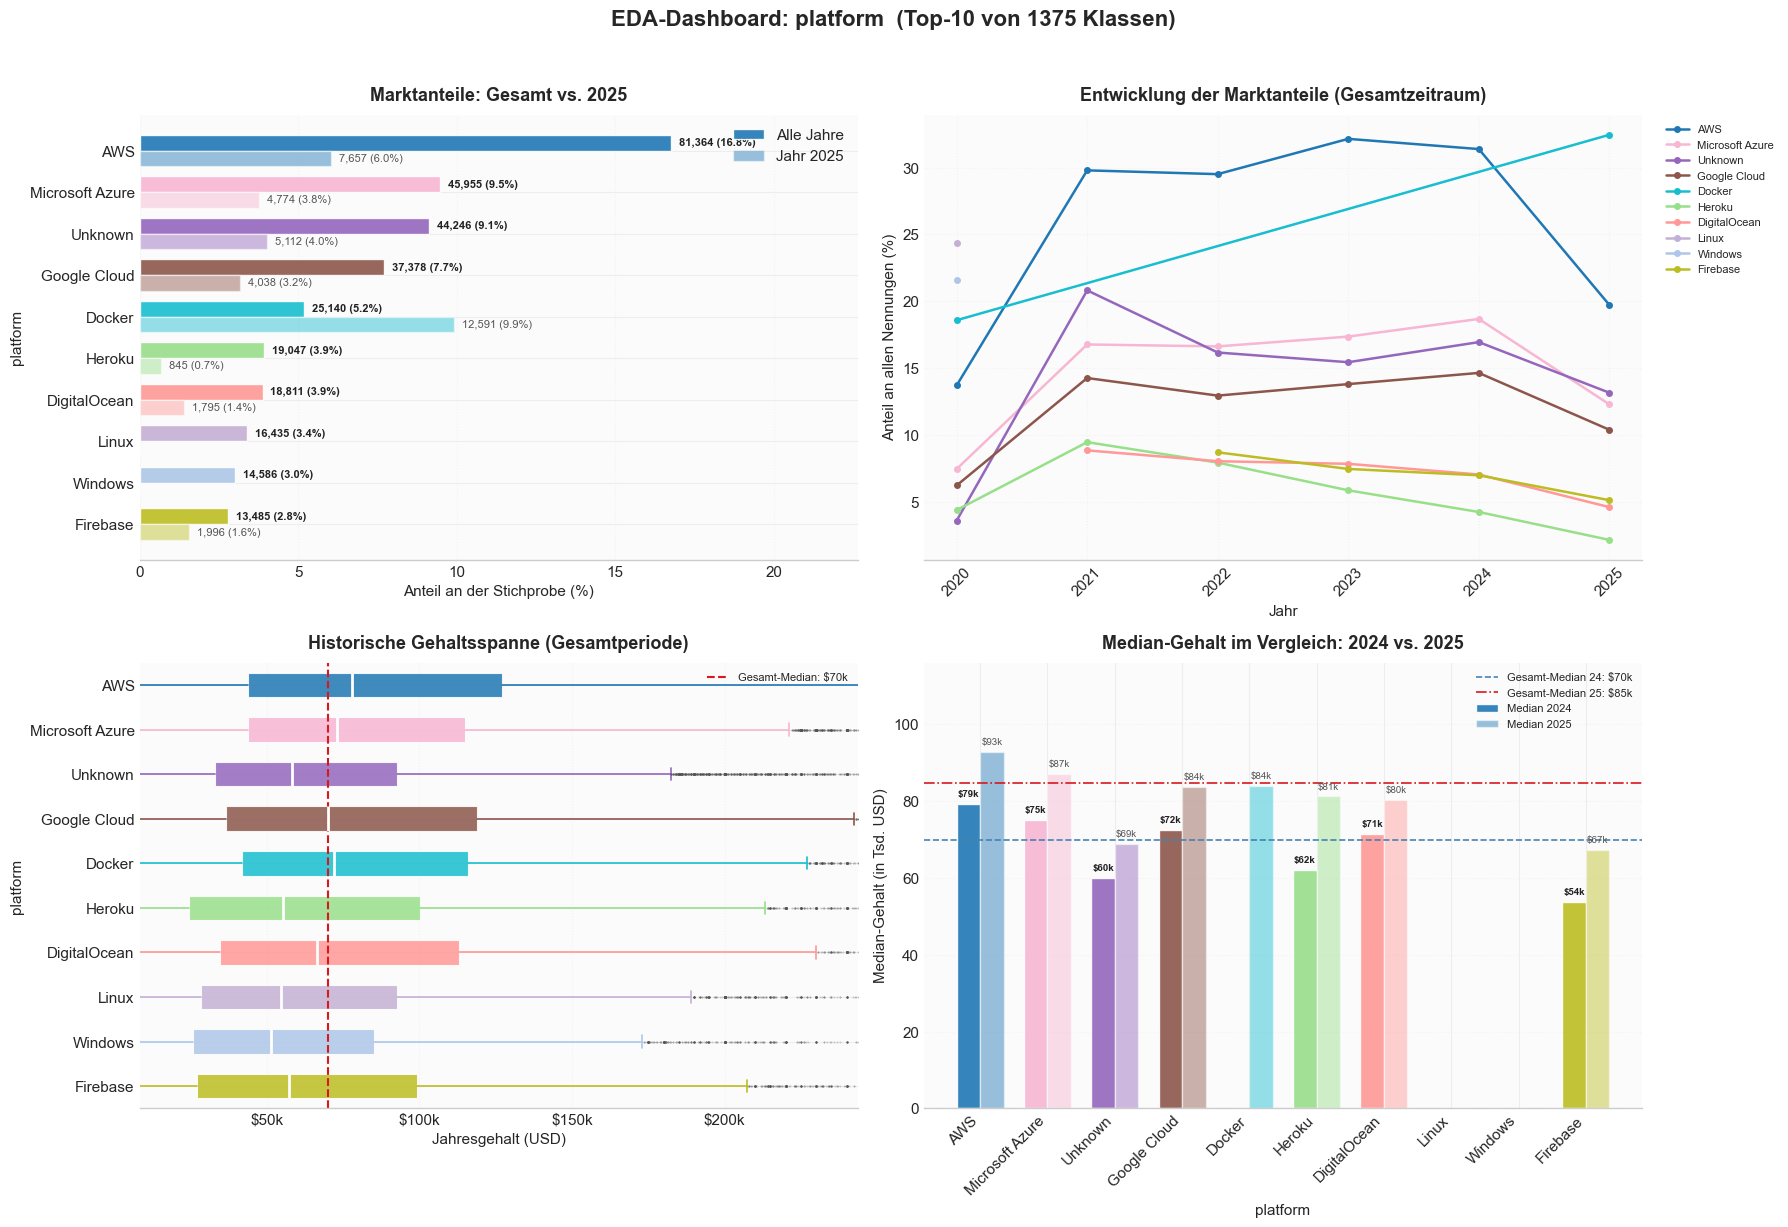

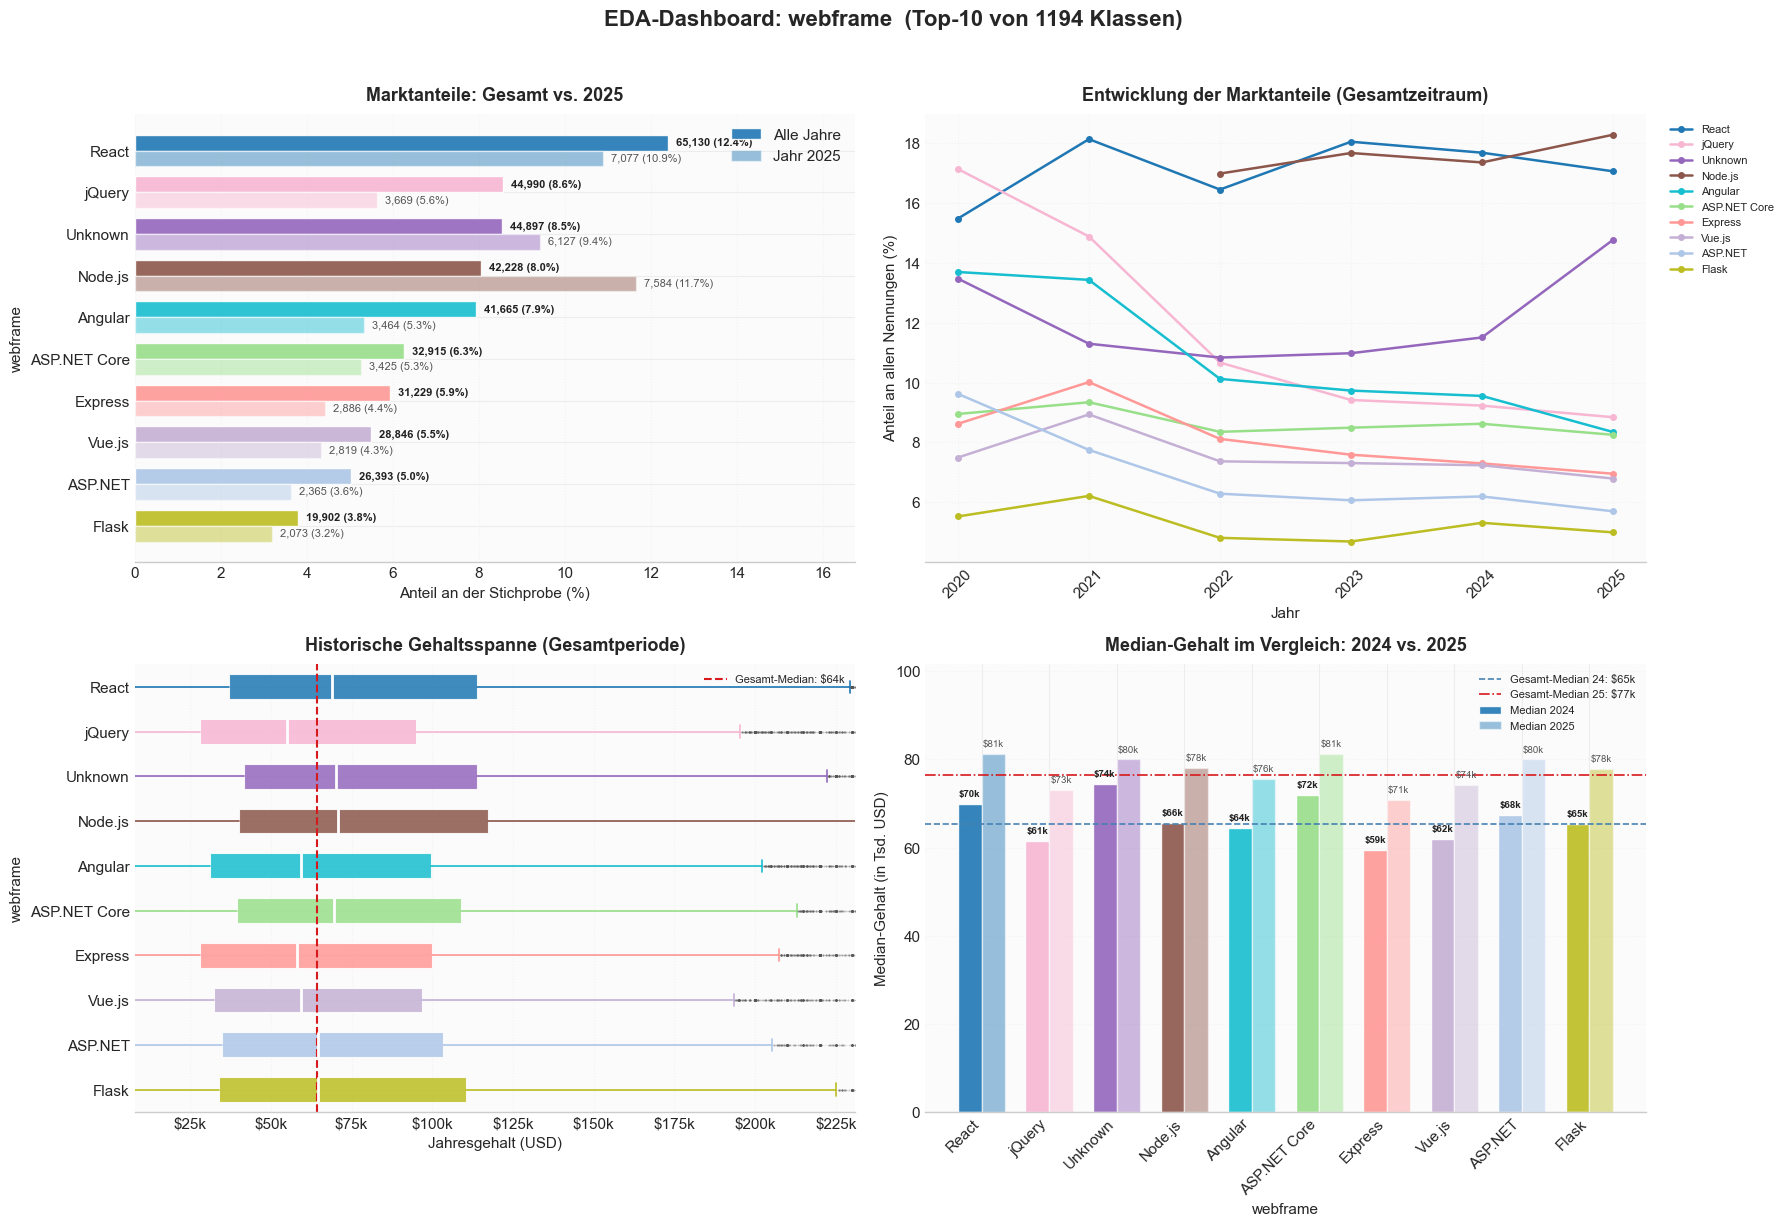

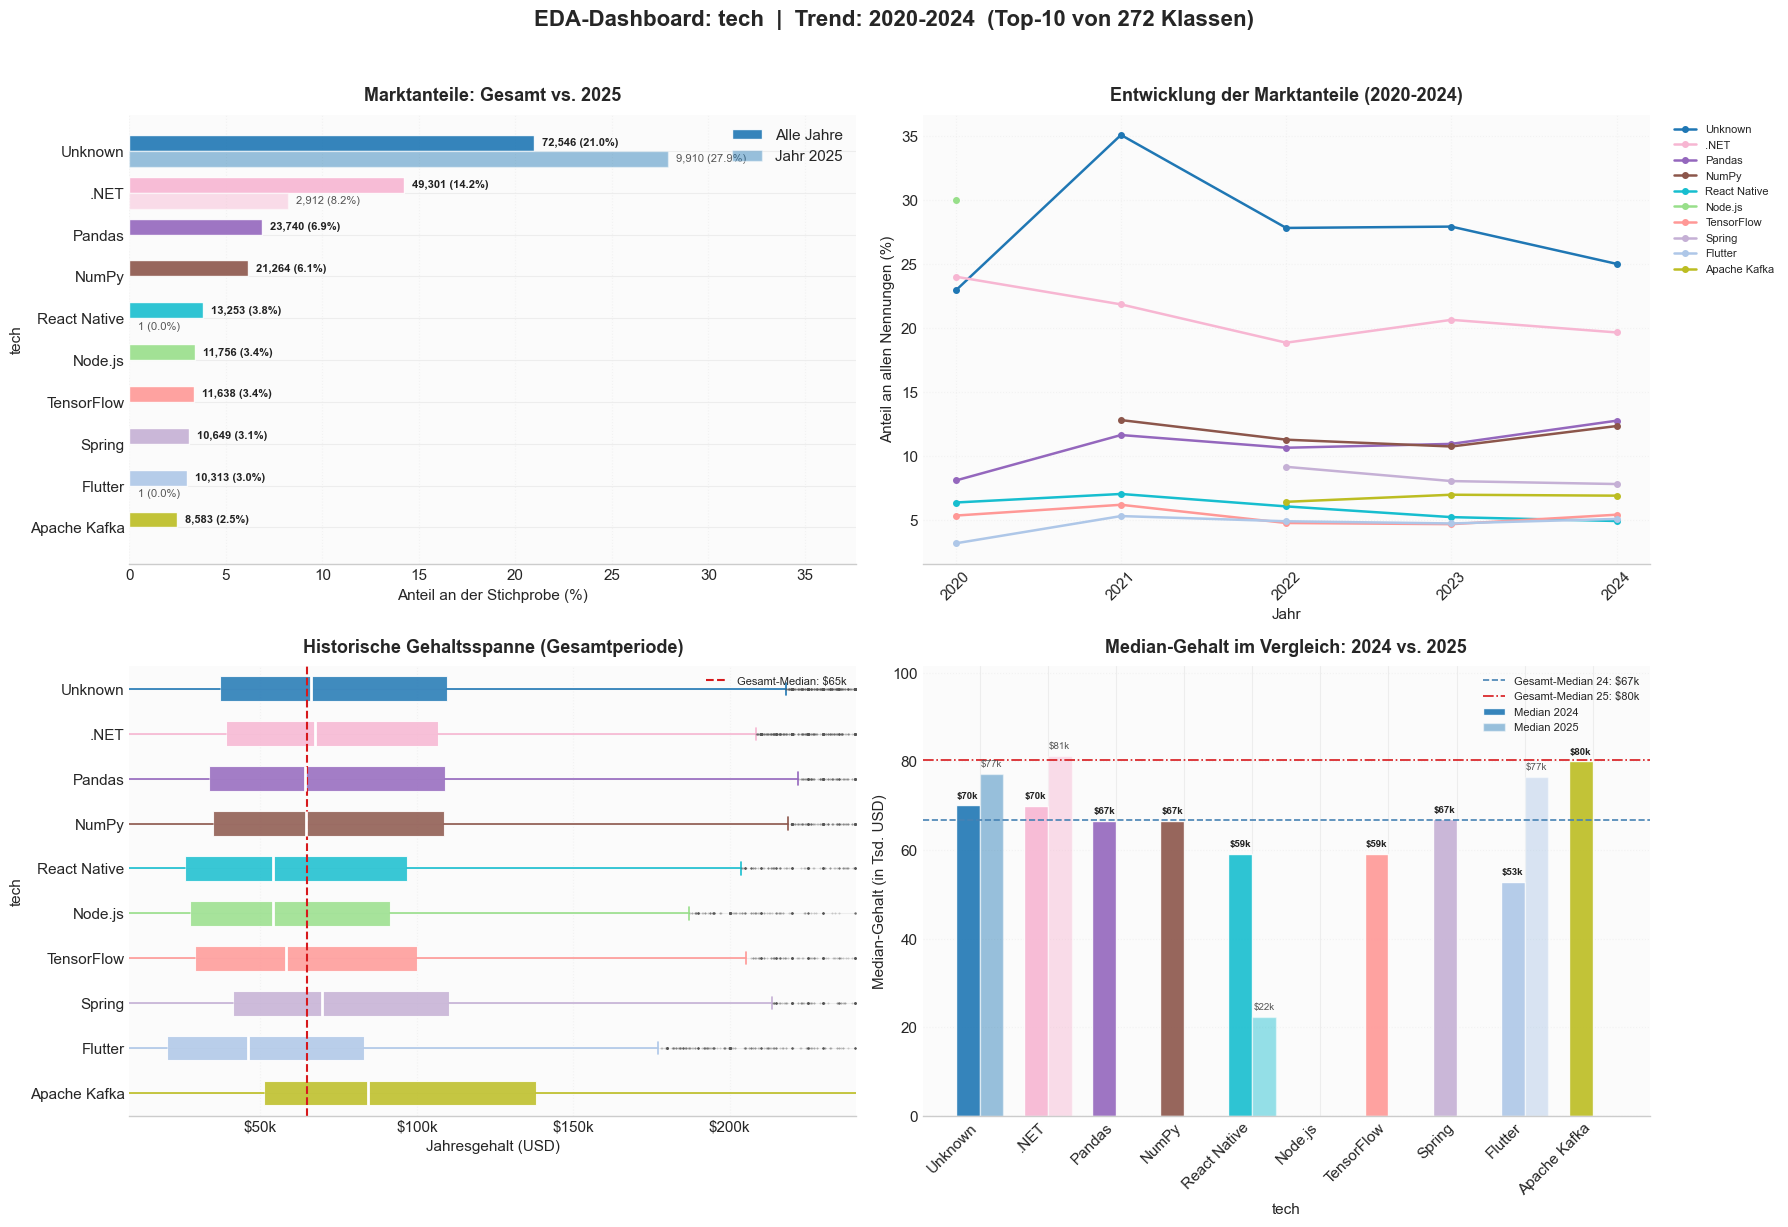

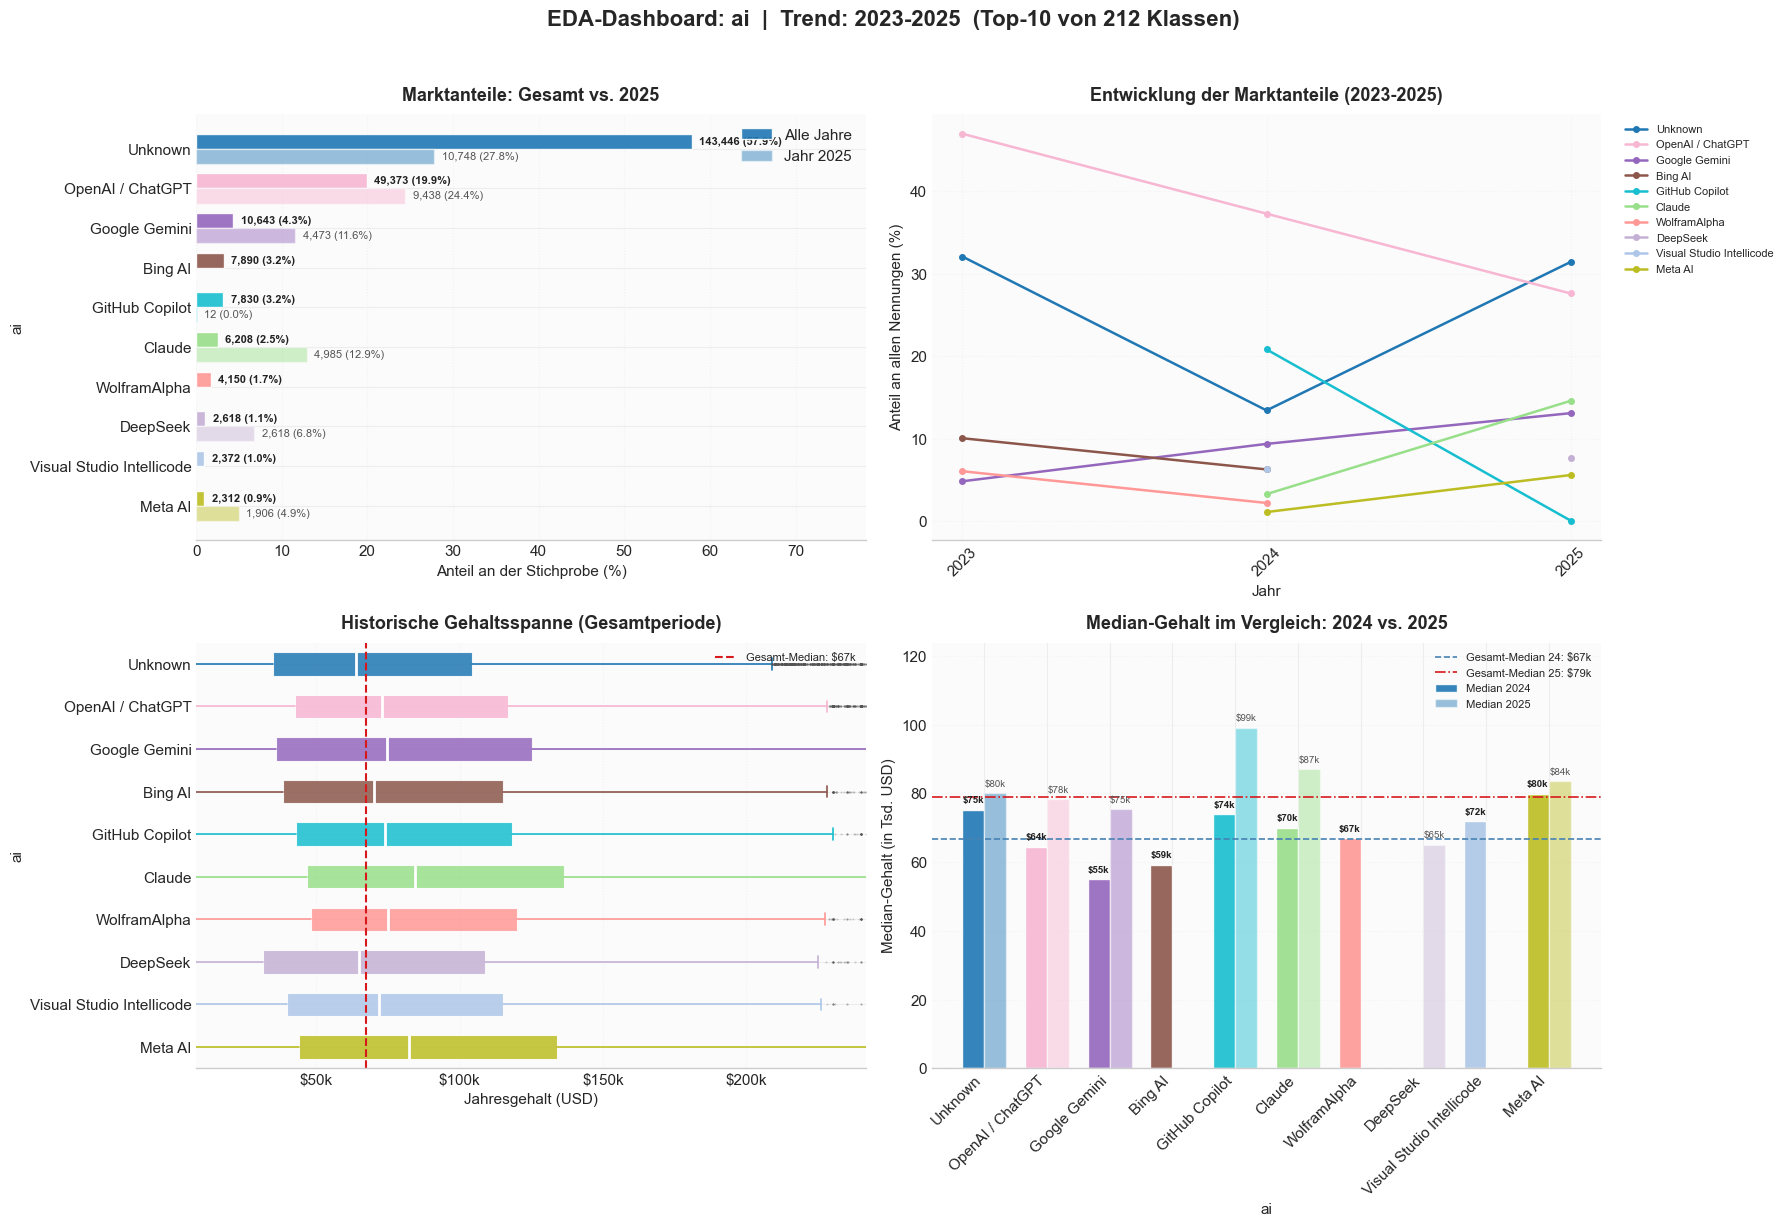

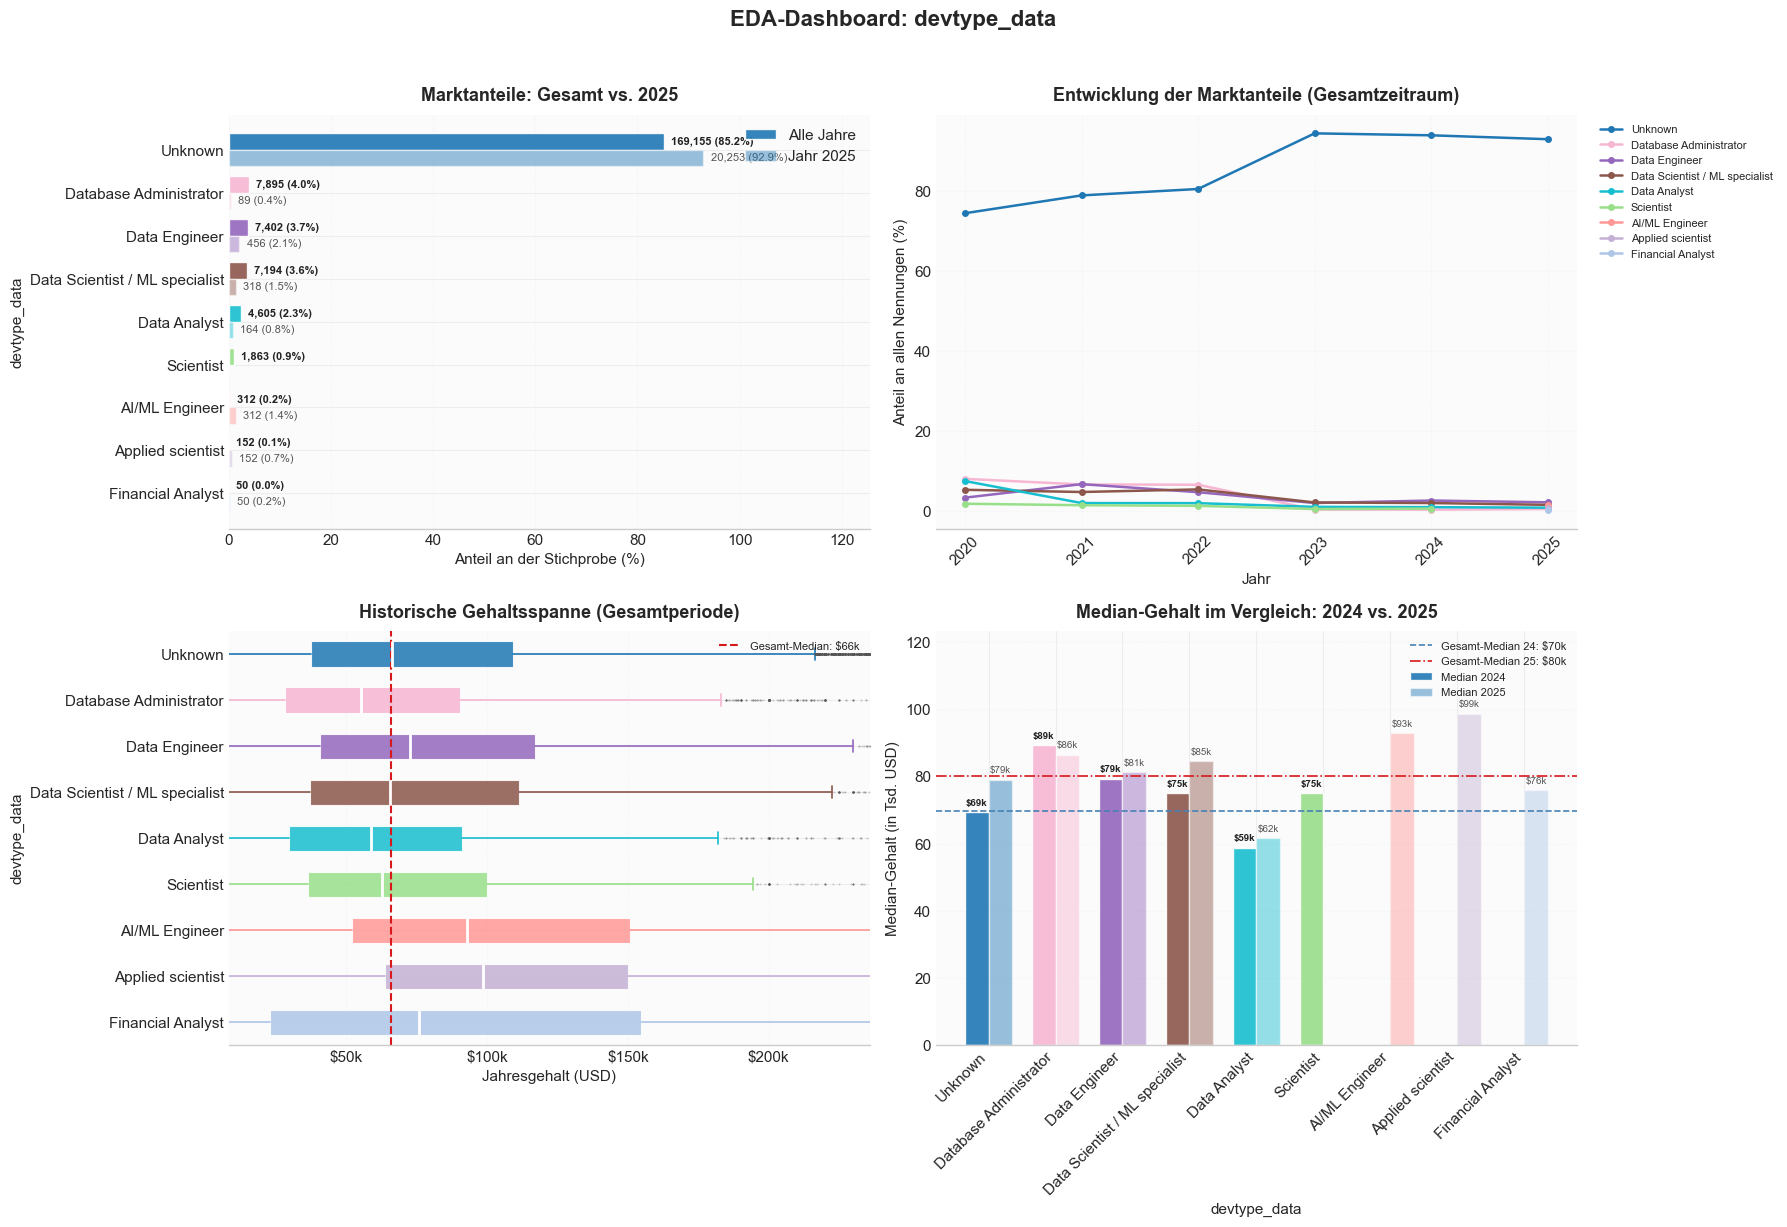

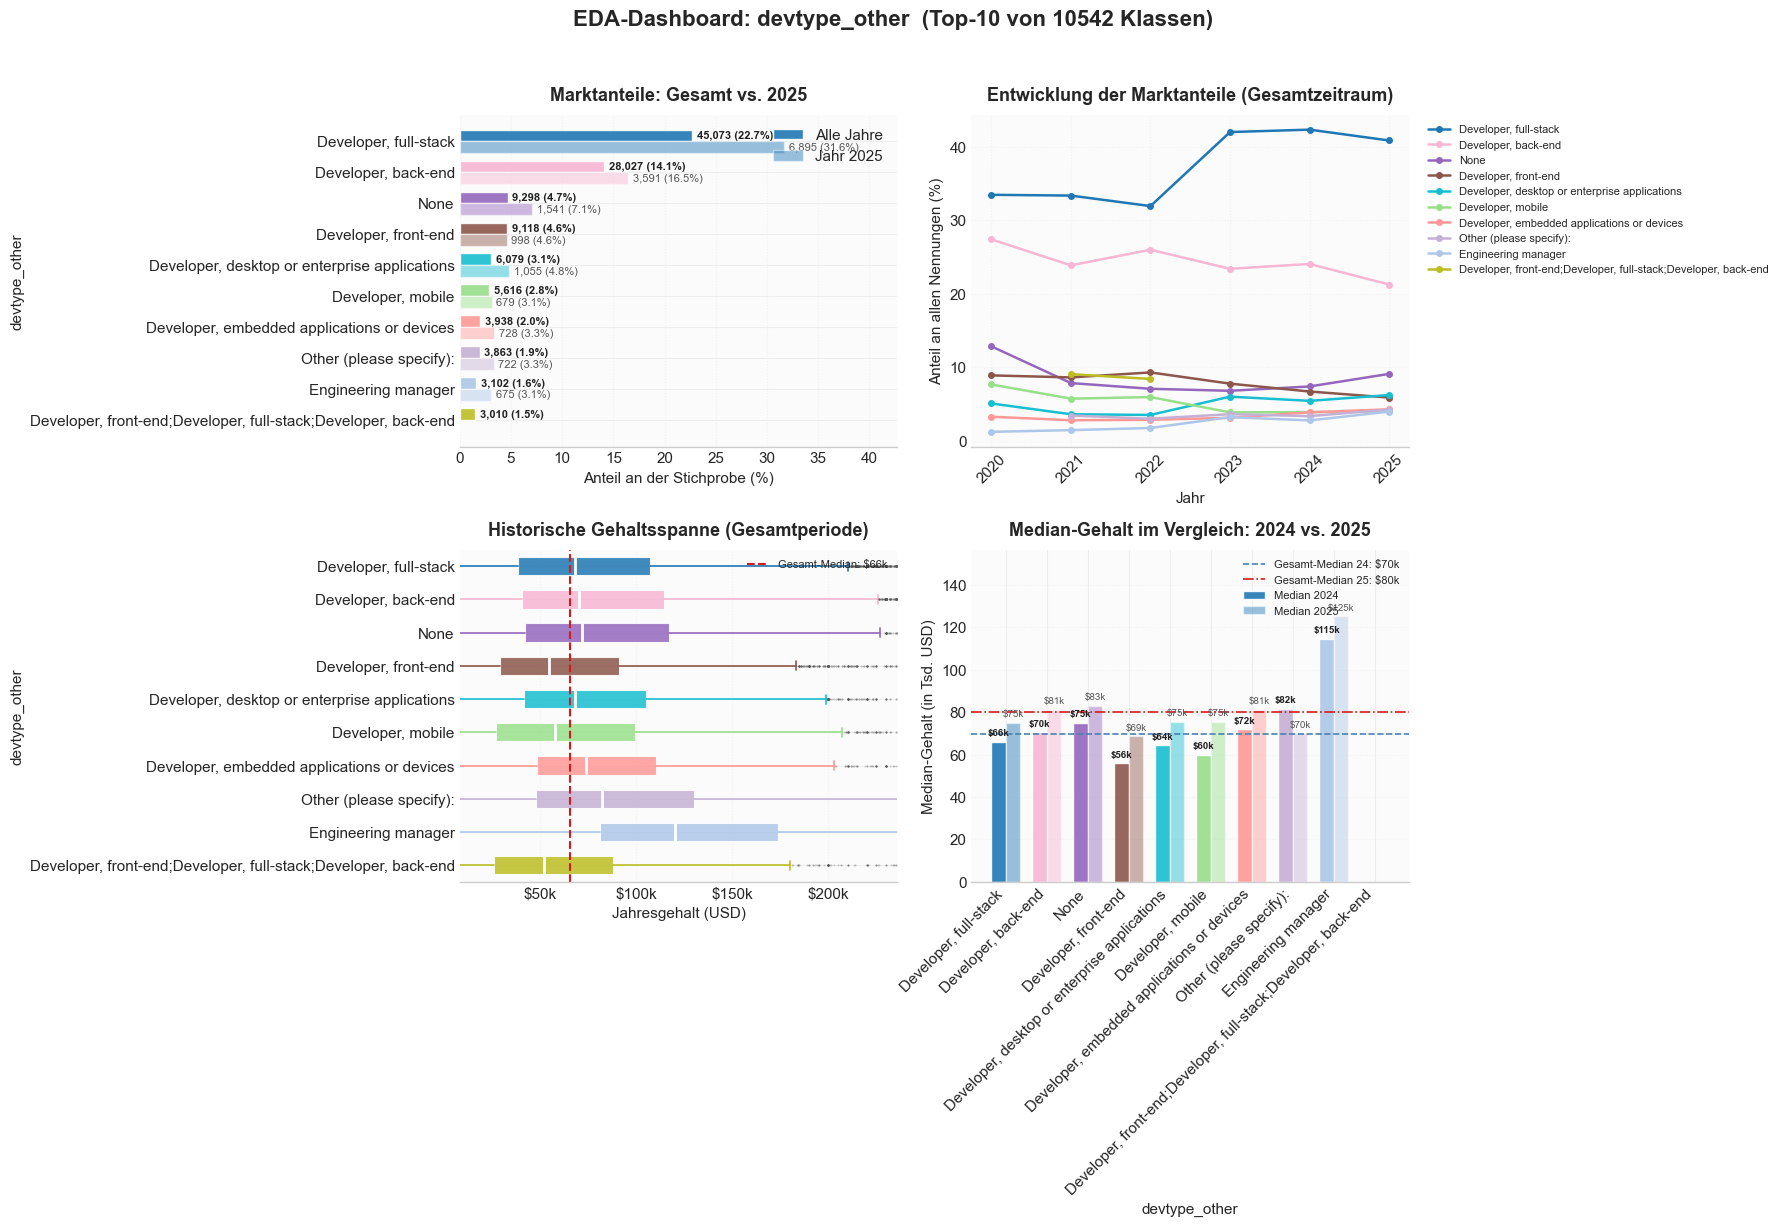

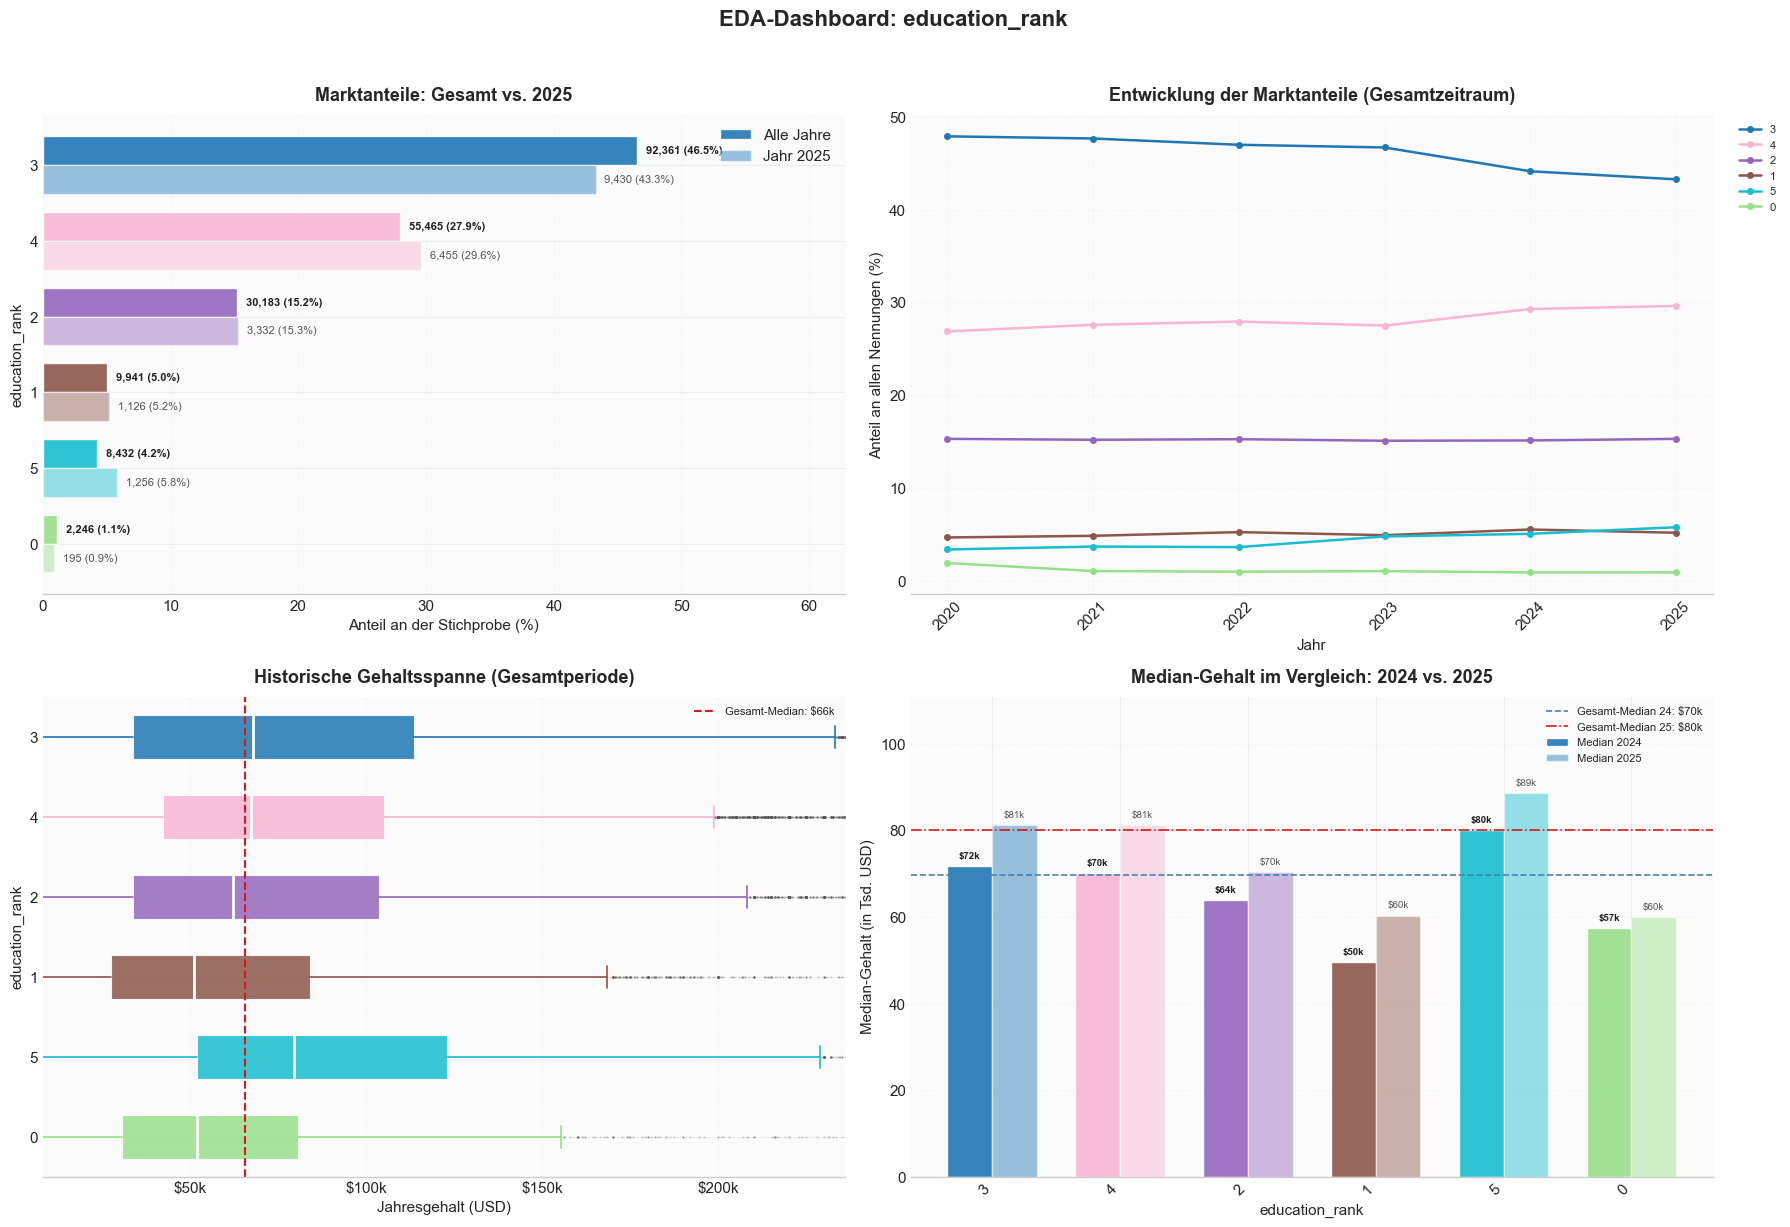

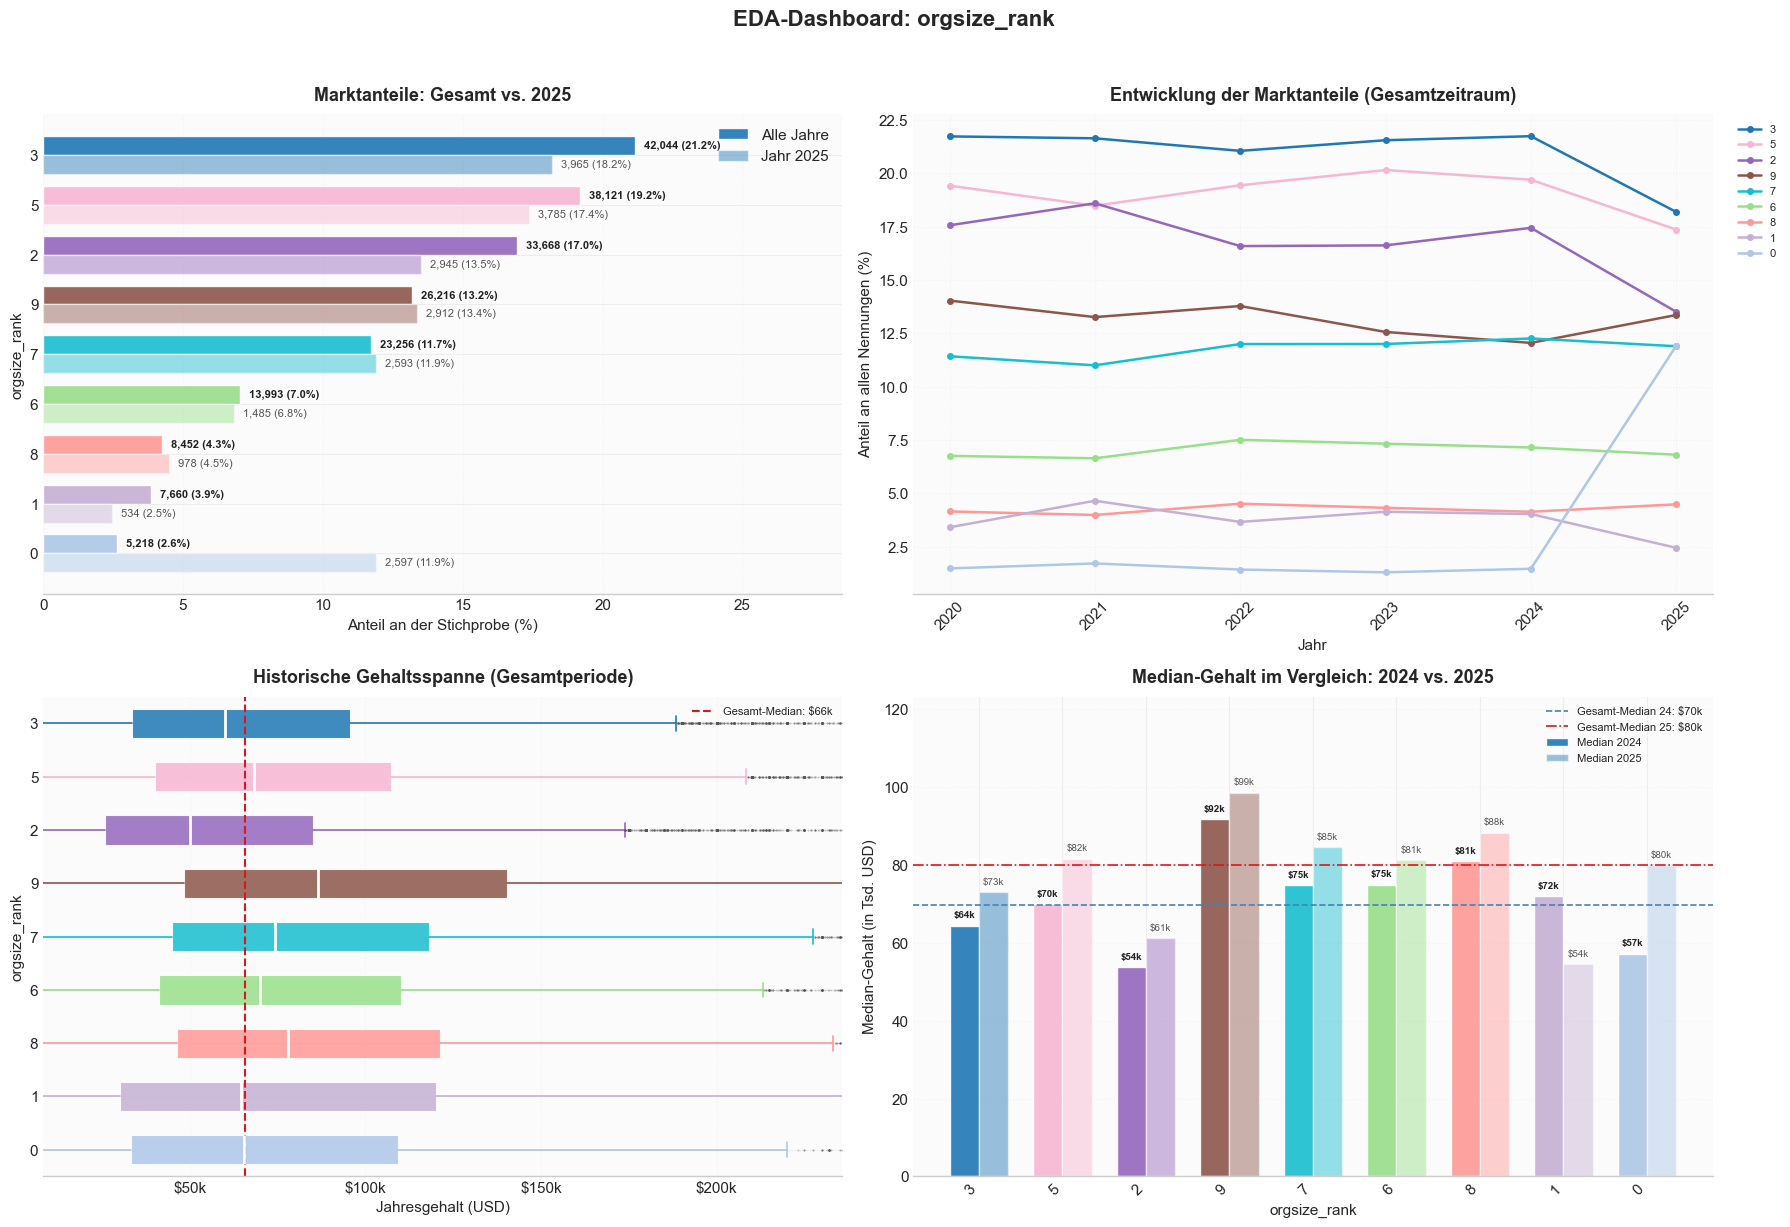

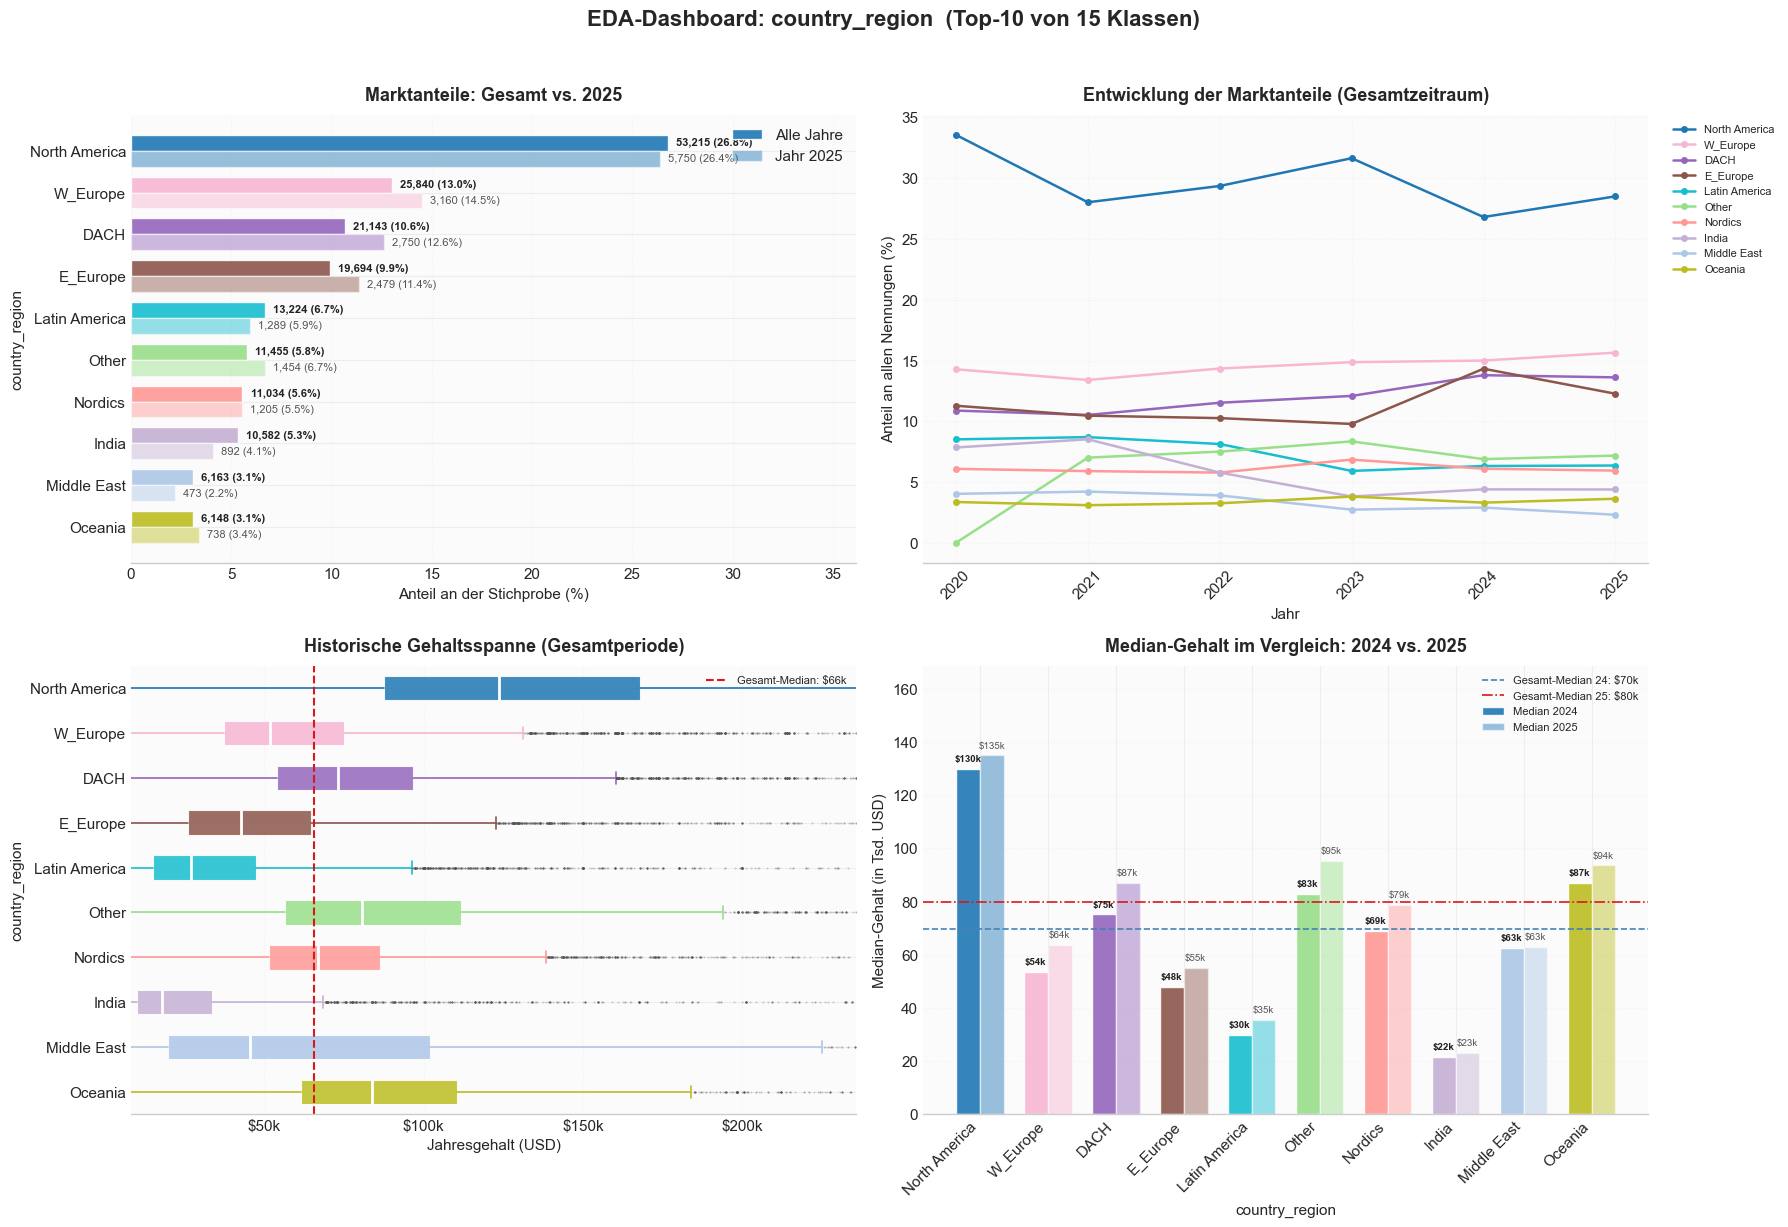

In [42]:
for c in df_grp.select_dtypes(exclude=[np.number]).columns:
    if c in df_grp.columns:
        if c not in ['language', 'database', 'platform', 'webframe', 'tech', 'ai', 'aiagents']:
            if c in ['remote', 'icorpm']:
                eda_categorical(df_grp, c, trend_years=(2022, 2025))
            elif c in ['industry']:
                eda_categorical(df_grp, c, year=2025)
            else:
                eda_categorical(df_grp, c)
        else:
            exploded_df_grp = df_grp.copy()
            exploded_df_grp[c] = exploded_df_grp[c].astype(str).str.split(';') 
            exploded_df_grp = exploded_df_grp.explode(c)
            exploded_df_grp = exploded_df_grp.reset_index(drop=True)
            if c in ['tech']:
                eda_categorical(exploded_df_grp, c, trend_years=(2020, 2024))
            elif c in ['ai']:
                eda_categorical(exploded_df_grp, c, trend_years=(2023, 2025))
            elif c in ['aiselect', 'aiagents']:
                eda_categorical(exploded_df_grp, c, year=2025)
            else:
                eda_categorical(exploded_df_grp, c)


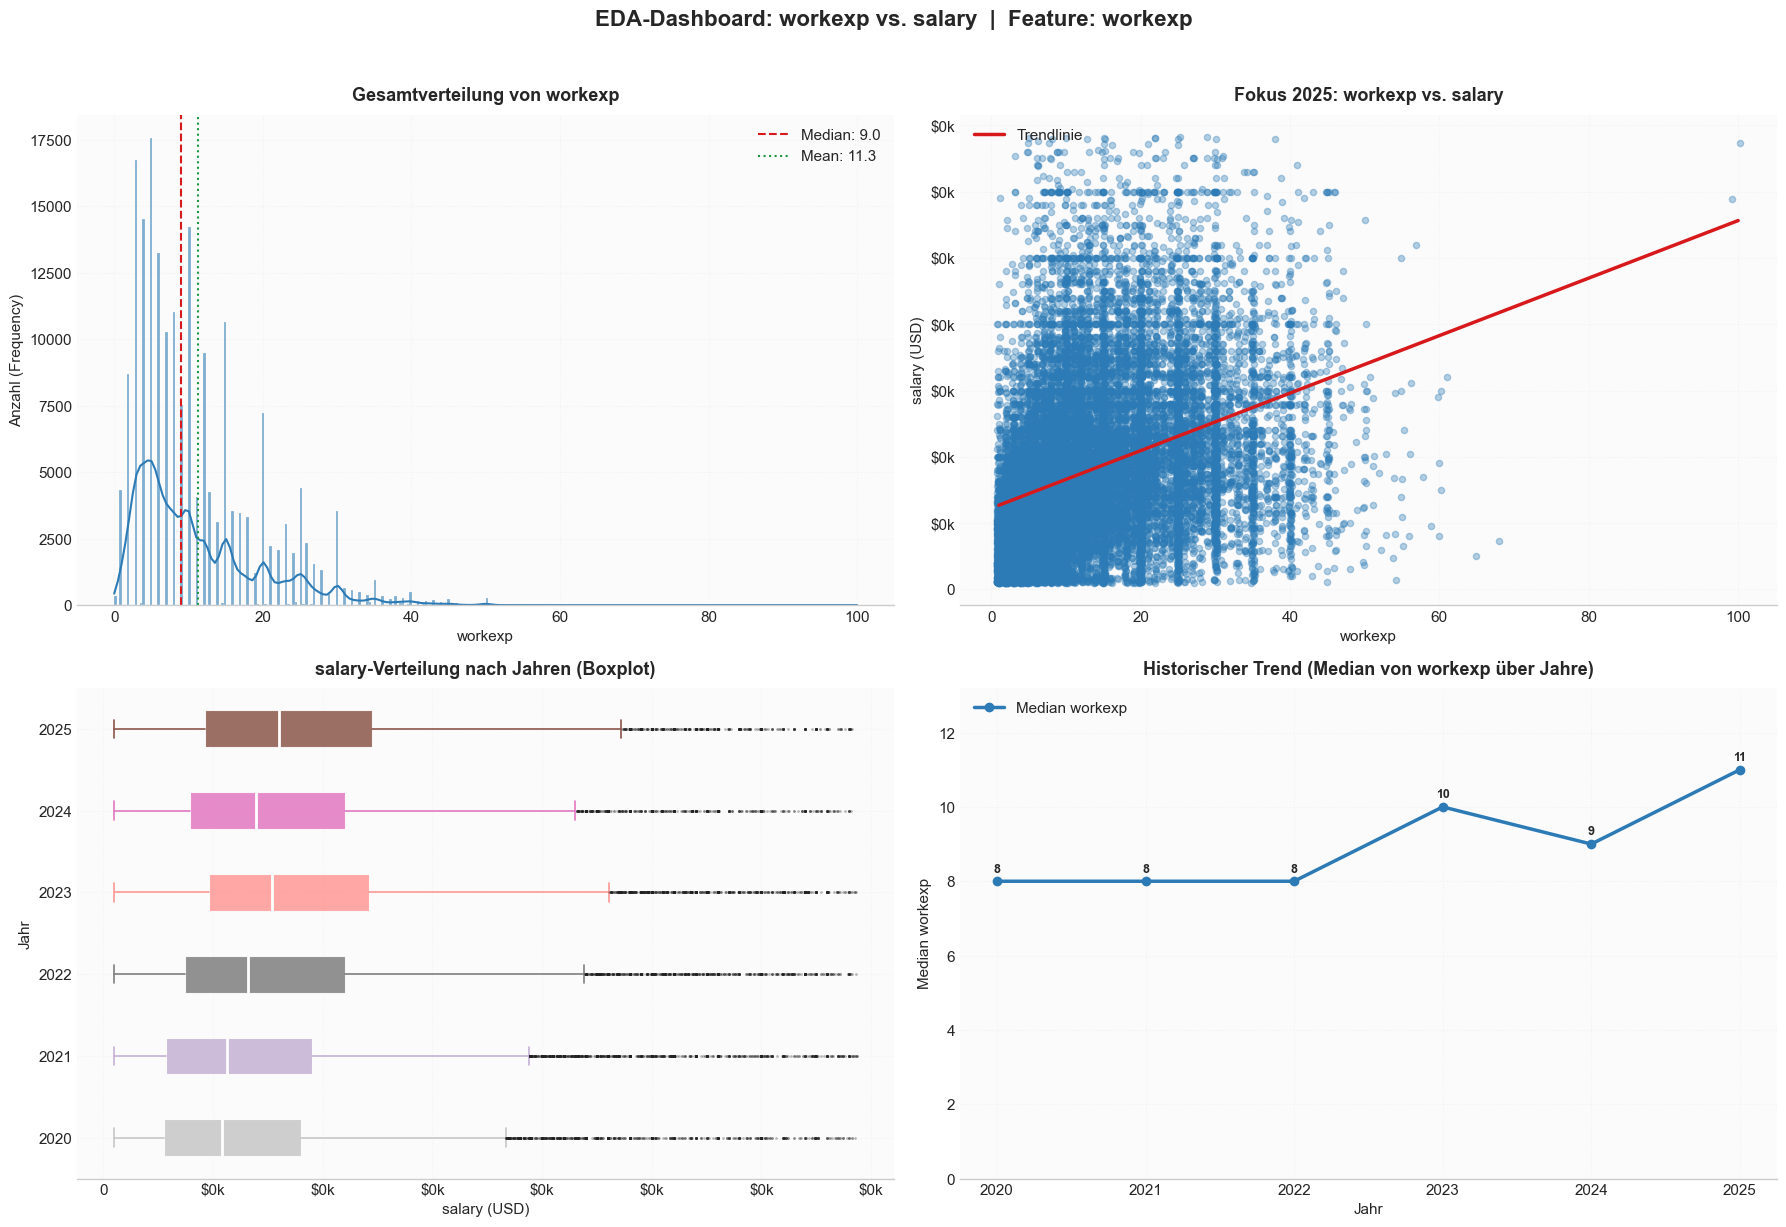

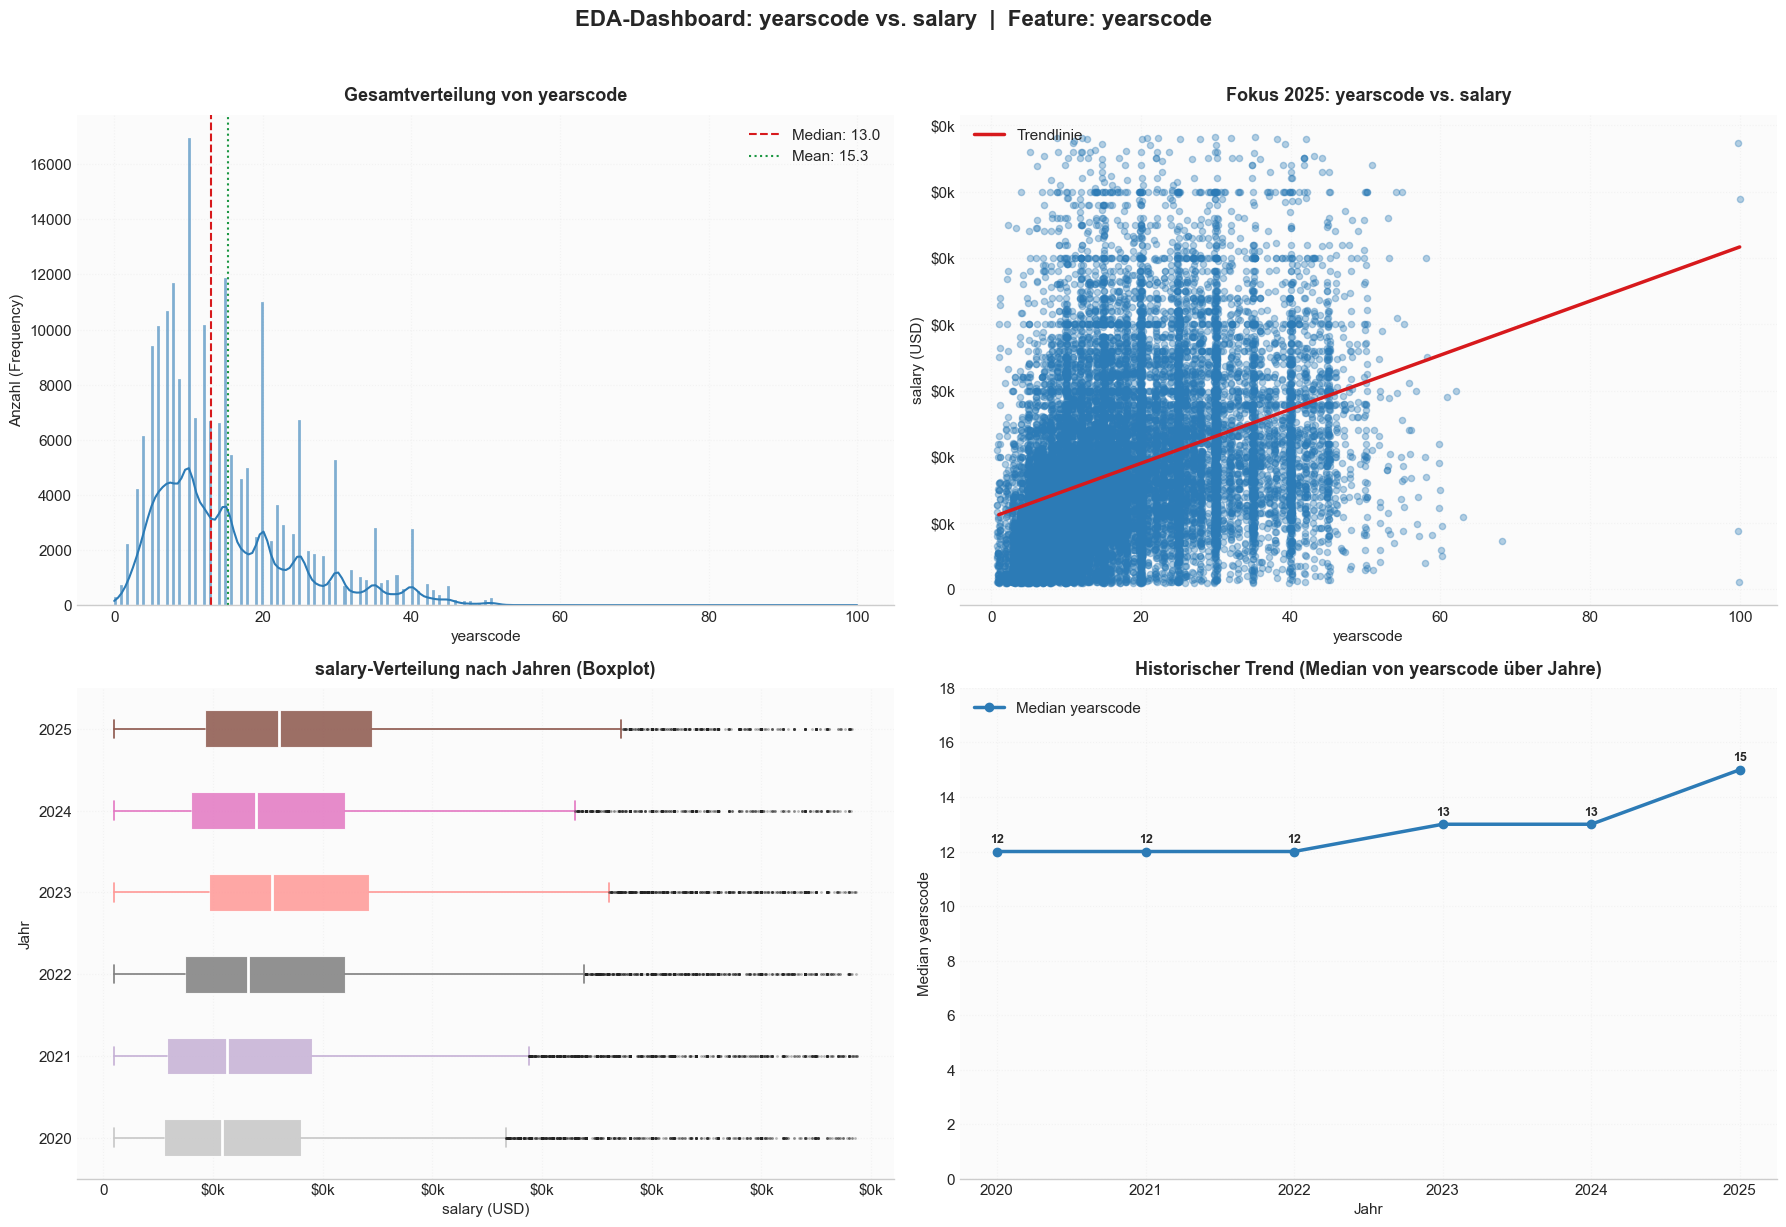

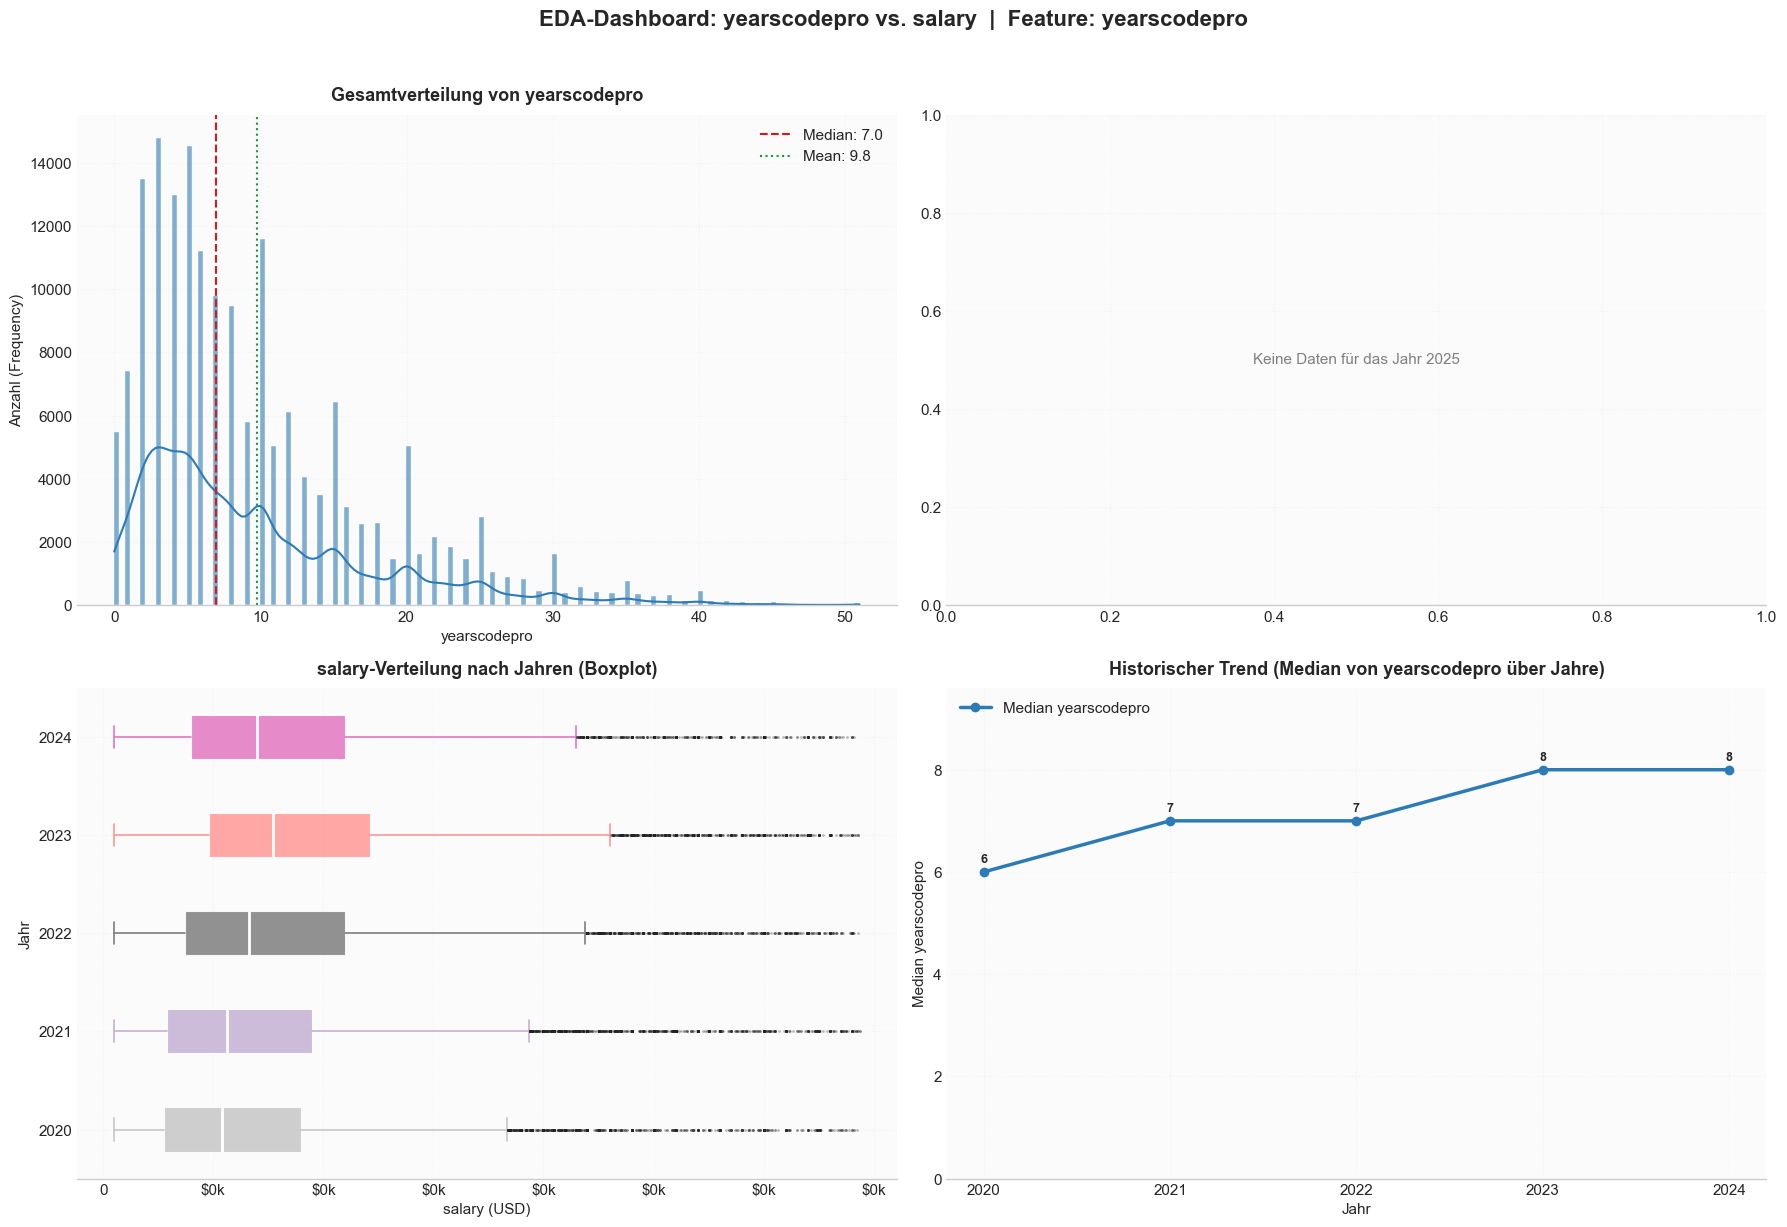

In [ ]:
for c in ['workexp', 'yearscode', 'yearscodepro']:
    if c in df.columns:
        eda_numeric(df_grp, col=c)

---
## ⚙️ 2. Base Model

In [43]:
# Baseline
features_train, features_test, target_train, target_test = data_split(df)

num_cols_raw  = ['year', 'workexp', 'yearscode', 'yearscodepro']
cat_cols_raw  = ['country', 'remote', 'branch', 'education', 'employment', 'industry', 'orgsize', 'icorpm', 'aiselect', 'age']


cat_transformer_raw = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown = 'ignore'))])

num_transformer_raw = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())]) 


preprocessor_raw = ColumnTransformer(transformers = [('cat', cat_transformer_raw, cat_cols_raw),
                                                 ('num', num_transformer_raw, num_cols_raw)], remainder = 'drop') 

model_base = Pipeline(steps = [('preprocessor', preprocessor_raw),
                               ('LinearRegression (base)', LinearRegression())])


model_base.fit(features_train, np.log1p(np.ravel(target_train)))
target_pred_base = np.expm1(model_base.predict(features_test))

df_results = pd.DataFrame(columns=["MAE", "RMSE", "R2"])
df_results.index.name = "Model"

df_results = result(df_results, "LinearRegression (base)", target_test, target_pred_base)

df_results

,MAE,RMSE,R2
Model,,,
LinearRegression (base),36.685539,53.535077,0.256925


---
### ➗ 3. Train-Test-Split

In [44]:
df['country_region'] = (df['country'].map(cfg.region_mapping).fillna('Other')) 
features_train, features_test, target_train, target_test = data_split(df)

In [ ]:
train_df       = df.loc[features_train.index]

global_median  = train_df["salary"].median()

country_median = (train_df.groupby("country")["salary"].median())

country_role_median = (
    train_df
    .assign(primary_role=train_df["devtype_data"].str.split(";").str[0].str.strip())
    .groupby(["country", "primary_role"])["salary"]
    .median()
)

# ШАГ 3 — маппим на весь df
df["country_salary_median"] = (df["country"].map(country_median).fillna(global_median))

df["country_role_median"] = df.apply(lambda row: country_role_median.get((row["country"], str(row["devtype_data"]).split(";")[0].strip()), global_median), 
                                     axis=1,)

# 
region_median = (
    train_df.groupby("country_region")["salary"]
    .median()
    .rename("region_salary_median")
)

region_role_median = (
    train_df.groupby(["country_region", "devtype_data"])["salary"]
    .median()
)

# Маппим на весь df
df["region_salary_median"] = (
    df["country_region"]
    .map(region_median)
    .fillna(global_median)
)

df["region_role_median"] = df.apply(
    lambda row: region_role_median.get(
        (row["country_region"], row["devtype_data"]),
        global_median
    ),
    axis=1,
)

# 
features_train = df.loc[features_train.index].drop(columns=["salary"])
features_test  = df.loc[features_test.index].drop(columns=["salary"])

In [52]:
def features_engineering(df_features):
    df_features = normalize_multivalue_column(df_features, 'devtype_data', mapping=cfg.data_role_mapping)
    for c in ['remote', 'branch', 'industry', 'icorpm', 'aiselect']:
        df_features[c] = df_features[c].replace(getattr(cfg, f"{c}_mapping"))
    df_features['education'] = df_features['education'].replace(cfg.education_mapping).astype(object)
    df_features['education_rank'] = df_features['education'].replace(cfg.education_rank_mapping).astype(object)
    df_features['orgsize'] = df_features['orgsize'].replace(cfg.orgsize_mapping).astype(object)
    df_features['orgsize_rank'] = df_features['orgsize'].replace(cfg.orgsize_rank_mapping).astype(object)
    df_features['employment'] = df_features['employment'].apply(clean_employment_status)
    
    df_features["country_region"] = (df_features["country"].map(cfg.region_mapping).fillna("Other"))    
    # df_features["is_usa"] = (df_features["country"].isin(["United States", "United States of America"])).astype(int)
    # df_features["is_germany"] = (df_features["country"] == "Germany").astype(int)
    # df_features["is_uk"] = (df_features["country"].isin(["United Kingdom", "United Kingdom of Great Britain and Northern Ireland"])).astype(int)
    # df_features["is_india"] = (df_features["country"] == "India").astype(int)
   
    df_features['country'] = df_features['country'].replace({'United States of America': 'United States',
                                                'United Kingdom of Great Britain and Northern Ireland': 'Great Britain'})
    df_features['country'] = group_rare_categories(df_features, 'country')
    df_features['currency'] = df_features['currency'].apply(categorize_currency)
    df_features['currency'] = group_rare_categories(df_features, 'currency')
    for c in ['language', 'database', 'platform', 'webframe', 'tech', 'ai', 'opsys', 'activities', 'office_stack']:
        current_mapping = getattr(cfg, f"{c}_mapping")
        df_features = normalize_multivalue_column(df_features, c, mapping=current_mapping)
        df_features = replace_rare_with_other(df_features, c)
    df_features["temporal_weight"] = df_features["year"].map({2020: 0.5, 2021: 0.7, 2022: 1.0, 2023: 1.5, 2024: 2.5, 2025: 3.0})
    df_features = impute_work_exp(df_features)

    df_features['hobbyyears'] = df_features['yearscode'] - df_features['yearscodepro']
    return df_features

In [53]:
features_train = features_engineering(features_train)
features_test = features_engineering(features_test)

In [54]:
overview(features_train)

,dtype,count,missing_n,missing_%,uniques_n,uniques
year,int64,176834,0,0.000000,5,"[2020, 2021, 2022, 2023, 2024]"
currency,str,176834,0,0.000000,5,"[USD, GBP, EUR, Other, INR]"
country,str,176834,0,0.000000,5,"[United States, Other, Germany, India, Great B..."
workexp,float64,176834,0,0.000000,71,"[12.0, 5.0, 6.0, 26.0, 3.0, 28.0, 4.0, 23.0, 2..."
yearscode,float64,176228,606,0.342694,52,"[17.0, 8.0, 10.0, 7.0, 35.0, 5.0, 37.0, 9.0, 3..."
yearscodepro,float64,175958,876,0.495380,52,"[13.0, 4.0, 2.0, 7.0, 20.0, 1.0, 23.0, 3.0, 10..."
remote,str,176834,0,0.000000,4,"[Unknown, Hybrid, Remote, On-site]"
age,str,176834,0,0.000000,8,"[35-44, 18-24, 45-54, 25-34, Unknown, 55-64, 6..."
branch,str,176834,0,0.000000,2,"[Professional, Coding at Work/Studies]"
education,object,176834,0,0.000000,6,"[Bachelor, Master, College / Undergrad, School..."


---
## 🧠 4. ML

In [ ]:
cat_cols  = ['country', 'currency', 'remote', 'branch', 'employment', 'industry', 'icorpm', 'aiselect', 'education', 
             'orgsize', 'country_region', 'age']

multi_cols = ['language', 'database', 'platform', 'webframe', 'tech', 'ai', 'activities', 'opsys', 'office_stack',
              'devtype_data', 'devtype_other'] 

pca_cols  = []

num_cols   = ['year', 'education_rank', 'orgsize_rank', 'workexp', 'yearscode', 'hobbyyears',
            #'temporal_weight',
            'country_salary_median', 'country_role_median', 'region_salary_median', 'region_role_median'] 

for c in cat_cols:
    features_train[c] = features_train[c].fillna('Unknown')
    features_train[c] = features_train[c].astype('category')

for c in num_cols:
    # Umwandlung in Fließkommazahlen und Imputation fehlender Werte durch den Median
    features_train[c] = features_train[c].fillna(features_train[c].median())
    features_train[c] = features_train[c].astype('float32')
    
    # Durchführung der automatischen Typoptimierung basierend auf Wertebereichen
    if (features_train[c] % 1 != 0).any():
        # Zuweisung des Datentyps 'float32' bei Vorhandensein von Nachkommastellen
        features_train[c] = features_train[c].astype('float32')
    else:
        if features_train[c].min() < 0:
            # Klassifizierung für vorzeichenbehaftete Ganzzahlen
            if features_train[c].min() >= -128 and features_train[c].max() <= 127:
                features_train[c] = features_train[c].astype('int8')
            elif features_train[c].min() >= -32768 and features_train[c].max() <= 32767:
                features_train[c] = features_train[c].astype('int16')
            else:
                features_train[c] = features_train[c].astype('int32')
        else:
            # Klassifizierung für vorzeichenlose Ganzzahlen
            if features_train[c].max() < 255:
                features_train[c] = features_train[c].astype('uint8')
            elif features_train[c].max() < 65535:
                features_train[c] = features_train[c].astype('uint16')
            else:
                features_train[c] = features_train[c].astype('int32')

# weights_all = compute_sample_weights(features_train, strategy='purity')
# weights_train = weights_all.loc[features_train.index]

In [ ]:
# Transformation für numerische Daten: Imputation durch Median und Skalierung
num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                             ('scaler', StandardScaler())]) 

# Transformation für PCA-Komponenten: Median-Imputation, Skalierung und anschließend PCA
pca_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', StandardScaler()), 
                                    ('pca', PCA(n_components=1))])

# Transformation für kategoriale Daten: Imputation durch häufigsten Wert und One-Hot-Encoding
cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))])

# Multilabel-Vektorisierung mittels CountVectorizer (Trennung durch Semikolon)
vectorizer_step = CountVectorizer(tokenizer=lambda x: str(x).split(';'), lowercase=False)

# Liste der Transformer für den ColumnTransformer
transformers_list = [('num', num_transformer, num_cols),
                     ('cat', cat_transformer, cat_cols),
                     ('pca', pca_transformer, pca_cols)]

# Automatische Hinzufügung jeder Multivalue-Spalte einzeln.
# Dies stellt sicher, dass der ColumnTransformer sie als 1D-Vektoren verarbeitet
for col in multi_cols:
    transformers_list.append((f'multi_{col}', vectorizer_step, col))
    
# Initialisierung des finalen Preprocessors
preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')

In [57]:
# Daten durch den Preprocessor leiten (Training und Transformation)
features_transformed = preprocessor.fit_transform(features_train)

# Namen der neuen Spalten abrufen, die durch OHE und CountVectorizer generiert wurden
column_names = preprocessor.get_feature_names_out()

# Den DataFrame wieder schön zusammenbauen
# Falls das Ergebnis eine sparse matrix (scipy) ist, 
# nutzen wir .toarray(), ansonsten verwenden wir die Daten direkt
if hasattr(features_transformed, "toarray"):
    df_transformed = pd.DataFrame(features_transformed.toarray(), columns=column_names, index=df.index)
else:
    df_transformed = pd.DataFrame(features_transformed, columns=column_names, index=features_train.index)

print(f"Dimensionen des DataFrames VORHER: {features_train.shape}")
print(f"Dimensionen des DataFrames NACHHER: {df_transformed.shape}")
display(df_transformed.head())

Dimensionen des DataFrames VORHER: (176834, 39)
Dimensionen des DataFrames NACHHER: (176834, 216)


,num__year,num__education_rank,num__orgsize_rank,num__workexp,num__yearscode,num__hobbyyears,num__country_salary_median,num__country_role_median,num__region_salary_median,num__region_role_median,...,multi_devtype_other__None,multi_devtype_other__Other (please specify):,multi_devtype_other__Product manager,multi_devtype_other__Project manager,multi_devtype_other__Research & Development role,multi_devtype_other__Security professional,"multi_devtype_other__Senior Executive (C-Suite, VP, etc.)",multi_devtype_other__Senior executive/VP,multi_devtype_other__Student,multi_devtype_other__System administrator
7,-1.457177,-0.076299,-0.699298,0.113671,0.208799,-0.294857,1.015937,0.984936,1.447741,1.503598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,-1.457177,0.983747,-1.094120,-0.712703,-0.727230,-0.294857,-0.139442,-0.342769,0.198233,-0.174919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,-1.457177,-0.076299,1.669631,-0.594650,-0.519224,0.667482,-0.139442,-0.148934,0.198233,0.206945,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,-1.457177,-1.136345,-1.094120,-0.712703,-0.831234,-1.257197,-0.681913,-0.644618,-0.509223,-0.499231,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,-1.457177,-2.196392,-1.094120,1.766421,2.080859,2.351577,-0.133611,-0.143211,-0.509223,-0.499231,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
# # Wörterbuch der Modelle
# models = {'LinearRegression': LinearRegression(),
#           'Ridge': Ridge(random_state=42),
#           'XGBoost': xgb.XGBRegressor(random_state=42),
#           'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1),
#           'CatBoostRegressor': CatBoostRegressor(random_state=42, verbose=0),
#           'DecisionTree': DecisionTreeRegressor(random_state=42),
#           'ExtraTrees': ExtraTreesRegressor(random_state=42),
#           'RandomForest': RandomForestRegressor(random_state=42),
#           'ElasticNet': ElasticNet(alpha=0.01)}

# for name, model_instance in models.items():
#     print(f"Modelltraining: {name}...")
    
#     # Pipeline-Erstellung und -Training, Vorhersage
#     pipeline = Pipeline(steps=[('preprocessor', preprocessor),
#                                ('regressor', model_instance)])
    
#     pipeline.fit(features_train, np.log1p(np.ravel(target_train)))
#     target_pred = np.expm1(pipeline.predict(features_test))
    
#     # Das Ergebnis in eine Tabelle schreiben
#     result(df_results, name, target_test, target_pred)

# df_results

In [59]:
# Stacking /  Ensemble?

In [60]:
# best_model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', CatBoostRegressor(random_state=42))])

# best_model.fit(features_train, np.log1p(np.ravel(target_train)))
# target_pred = np.expm1(best_model.predict(features_test))

# result(df_results, 'best_model', target_test, target_pred)

🏋️ Modelltraining & Hyperparameter-Optimierung

In [61]:
# def catboost_objective(trial):
#     params = {
#         "loss_function":   "MAE",
#         "iterations":      trial.suggest_int("iterations", 500, 4000),
#         "depth":           trial.suggest_int("depth", 3, 7),
#         "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
#         "l2_leaf_reg":     trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
#         "subsample":       trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
#         "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 5, 50),
#         "random_state":    42,
#         "verbose":         False,
#     }

#     model = Pipeline([
#         ("preprocessor", preprocessor),
#         ("regressor",    CatBoostRegressor(**params)),
#     ])
#     model.fit(
#         features_train,
#         np.log1p(np.ravel(target_train)),
#         #regressor__sample_weight=weights_train.values,
#     )
#     pred = np.expm1(model.predict(features_test))
#     return mean_absolute_error(target_test, pred)


# study = optuna.create_study(direction="minimize")
# study.optimize(catboost_objective, n_trials=50, show_progress_bar=True)
# best_params = study.best_params

# print(f"\nBest MAE:    {study.best_value:.3f}")
# print(f"Best params: {study.best_params}")

In [62]:
# best_params.update({"loss_function": "MAE", "random_state": 42, "verbose": 100})
# Best MAE:    25.533
# Best params: {'iterations': 3634, 'depth': 7, 'learning_rate': 0.045257016800331624, 'l2_leaf_reg': 5.764550436421908, 'subsample': 0.8948328494399703, 'colsample_bylevel': 0.7314666943171524, 'min_data_in_leaf': 34}
# Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

In [63]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor",    CatBoostRegressor(**{'loss_function': 'MAE',
                                          'iterations': 3634, 'depth': 7, 'learning_rate': 0.045257016800331624, 
                                          'l2_leaf_reg': 5.764550436421908, 'subsample': 0.8948328494399703, 
                                          'colsample_bylevel': 0.7314666943171524, 'min_data_in_leaf': 34,
                                          'random_state': 42}))])

best_model.fit(
    features_train,
    np.log1p(np.ravel(target_train)),
    #regressor__sample_weight=weights_train.values,
)

target_pred = np.expm1(best_model.predict(features_test))
result(df_results, "best_model_optuna", target_test, target_pred)
df_results

0:	learn: 0.6361163	total: 179ms	remaining: 10m 48s
1:	learn: 0.6182883	total: 206ms	remaining: 6m 14s
2:	learn: 0.6015188	total: 235ms	remaining: 4m 44s
3:	learn: 0.5859286	total: 264ms	remaining: 3m 59s
4:	learn: 0.5709420	total: 291ms	remaining: 3m 31s
5:	learn: 0.5567047	total: 320ms	remaining: 3m 13s
6:	learn: 0.5438156	total: 350ms	remaining: 3m 1s
7:	learn: 0.5321234	total: 379ms	remaining: 2m 51s
8:	learn: 0.5208839	total: 413ms	remaining: 2m 46s
9:	learn: 0.5103236	total: 439ms	remaining: 2m 39s
10:	learn: 0.4996630	total: 470ms	remaining: 2m 34s
11:	learn: 0.4899740	total: 503ms	remaining: 2m 31s
12:	learn: 0.4804192	total: 529ms	remaining: 2m 27s
13:	learn: 0.4720194	total: 558ms	remaining: 2m 24s
14:	learn: 0.4636177	total: 600ms	remaining: 2m 24s
15:	learn: 0.4558745	total: 635ms	remaining: 2m 23s
16:	learn: 0.4485485	total: 672ms	remaining: 2m 22s
17:	learn: 0.4416254	total: 704ms	remaining: 2m 21s
18:	learn: 0.4354085	total: 734ms	remaining: 2m 19s
19:	learn: 0.4292797	t

,MAE,RMSE,R2
Model,,,
LinearRegression (base),36.685539,53.535077,0.256925
best_model_optuna,25.532914,39.027704,0.605087


---
### 🤖 5. SHAP-Analyse & Modellinterpretation

SHAP-Werte werden berechnet...
shap_df (gesamt):  (21794, 216)
Reine Zeilen im Testset (purity=1.0): 1541
shap_df_pure:   (1541, 216)
Globaler Median: 65.7k  (= $65,663)

Erstelle SHAP-Stichprobe aus features_train (2020-2024)...
shap_df_sample: (35367, 216)
Jahresverteilung:
year
2020    6255
2021    8744
2022    6798
2023    9280
2024    4290
Name: count, dtype: int64
Data-Rollen in sample: 35367

══════════════════════════════════════════════════════════════
  BLOCK A — Gesamter Testdatensatz (2025)
══════════════════════════════════════════════════════════════

Gesamter Test (2025)
  MAE : $4,136,248,849,904,668,947,475,688,226,797,353,397,631,029,222,237,437,313,396,899,516,706,842,215,414,346,844,171,886,679,568,107,461,964,080,203,928,871,805,965,865,403,988,866,007,809,654,784.0k
  R²  : -1.9490
  N   : 21,794

SHAP — alle Merkmale (gesamter Test 2025) — Top-20 Merkmale


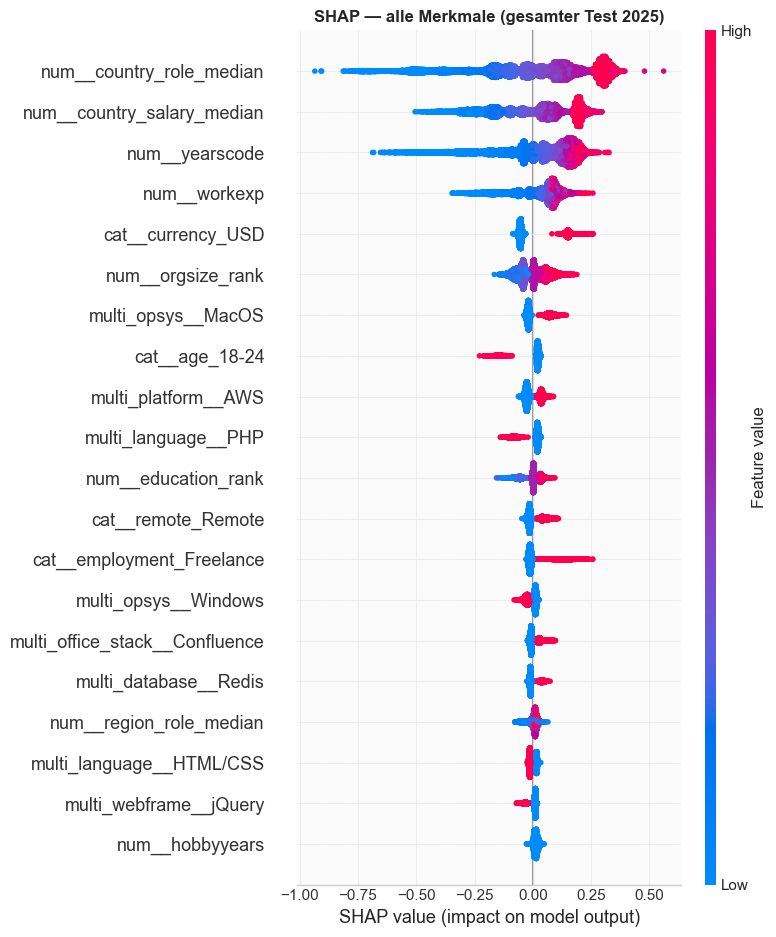

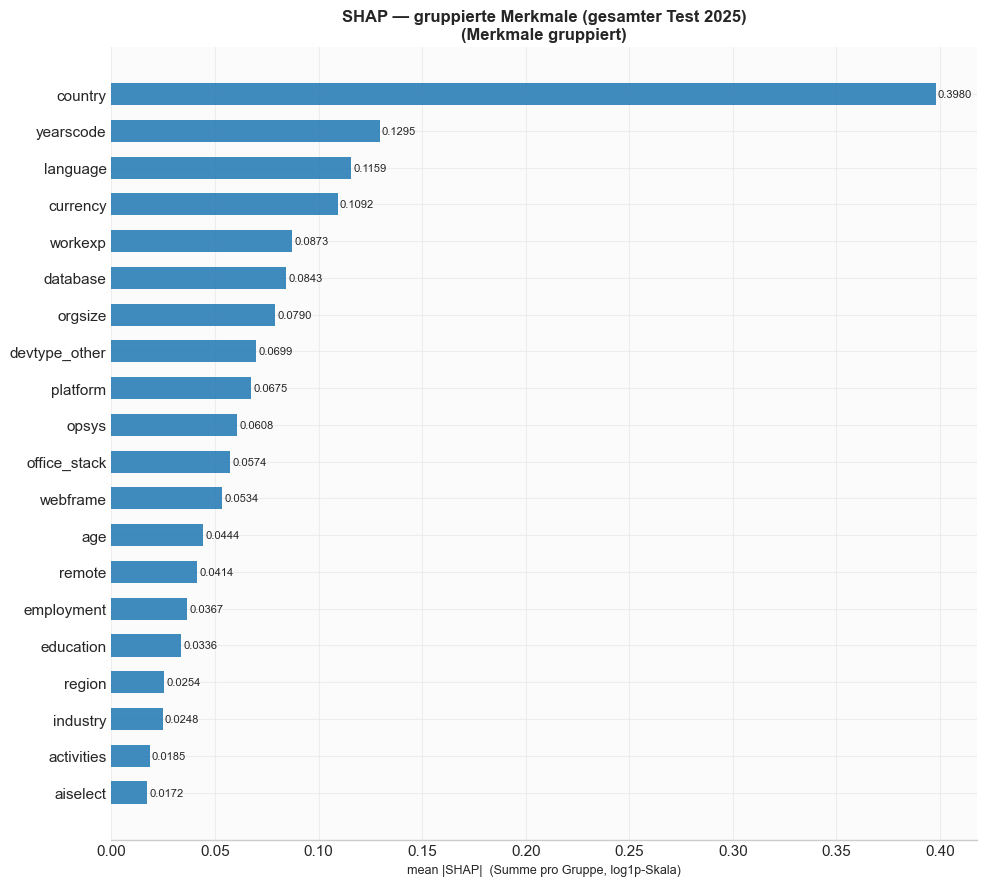


══════════════════════════════════════════════════════════════
  BLOCK B — Reine Data-Rollen (purity=1.0, 2025)
══════════════════════════════════════════════════════════════

Reine Data-Rollen (2025)
  MAE : $15,709,853,750,004,135,572,031,064,766,396,398,595,926,551,707,338,938,918,141,068,695,536,682,715,486,422,203,171,987,022,780,005,796,420,158,668,778,422,750,008,410,326,397,180,073,123,774,464.0k
  R²  : -1.9279
  N   : 1,541

SHAP — alle Merkmale (reine Data-Rollen 2025) — Top-20 Merkmale


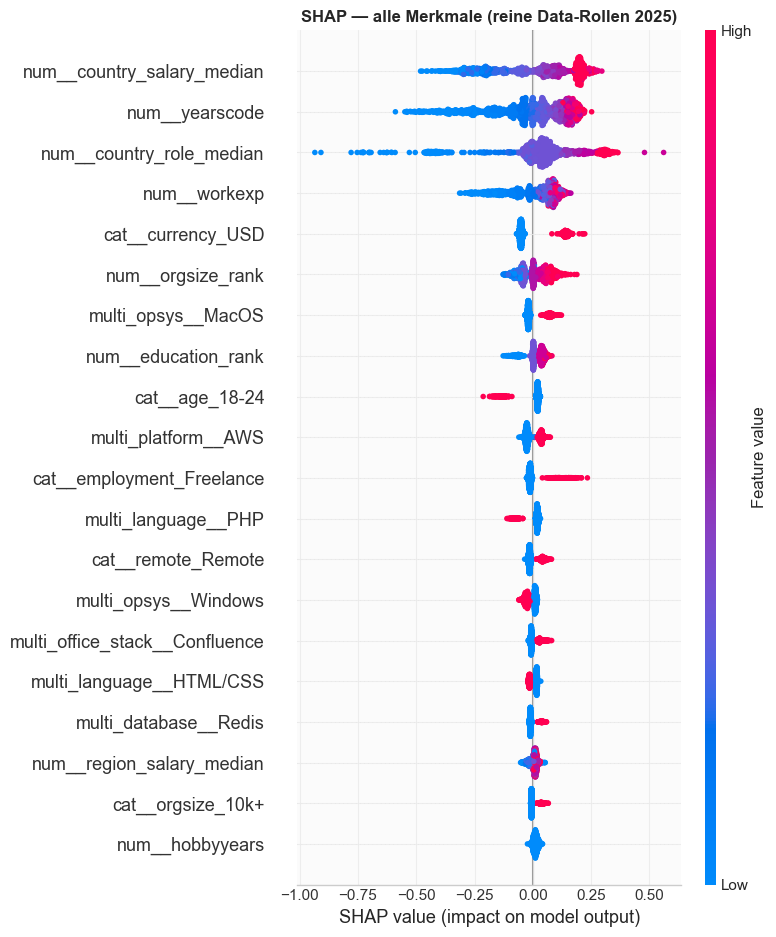

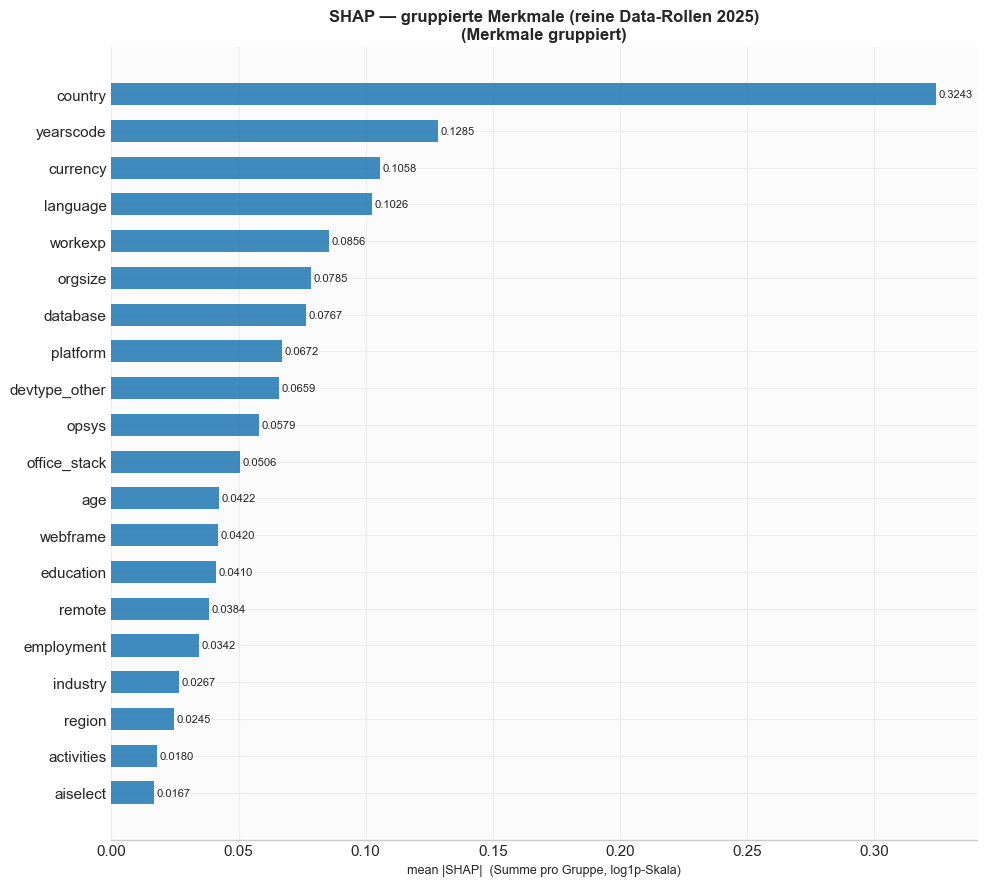


══════════════════════════════════════════════════════════════
  BLOCK C — Skill-Interpretation alle Rollen (2020-2024)
══════════════════════════════════════════════════════════════


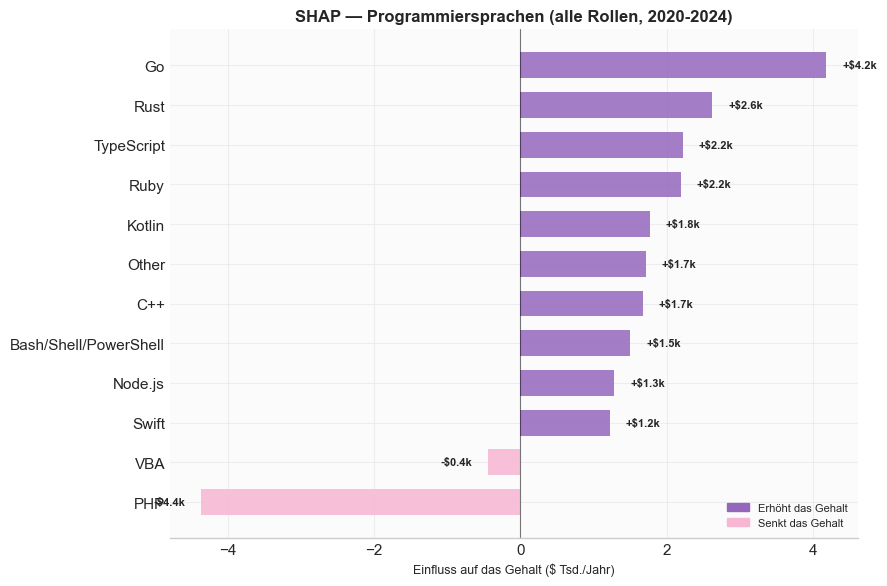

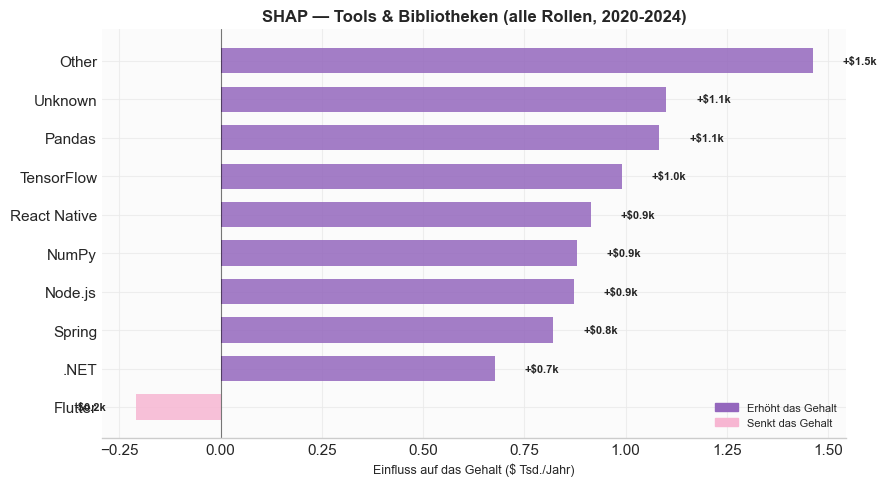

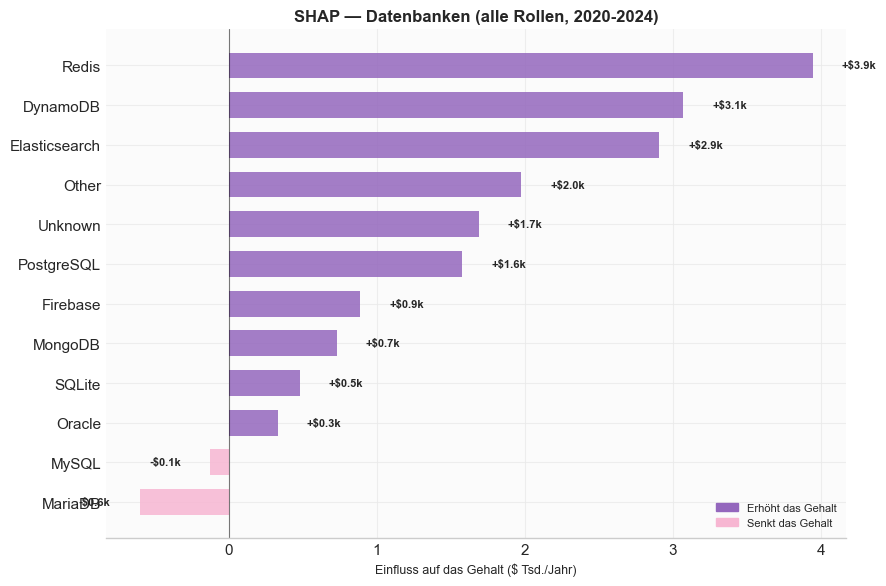

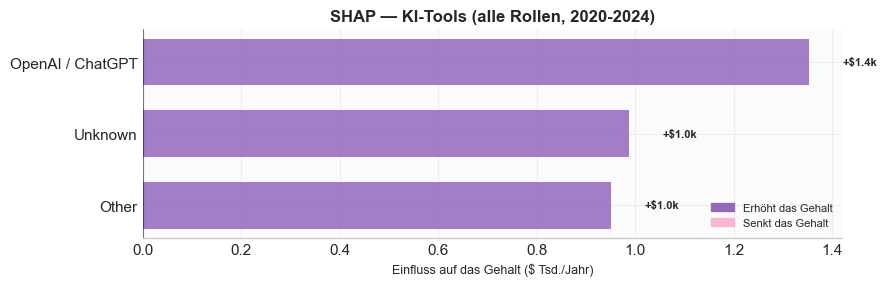


══════════════════════════════════════════════════════════════
  BLOCK D — Skill-Interpretation Data-Rollen (2020-2024)
══════════════════════════════════════════════════════════════


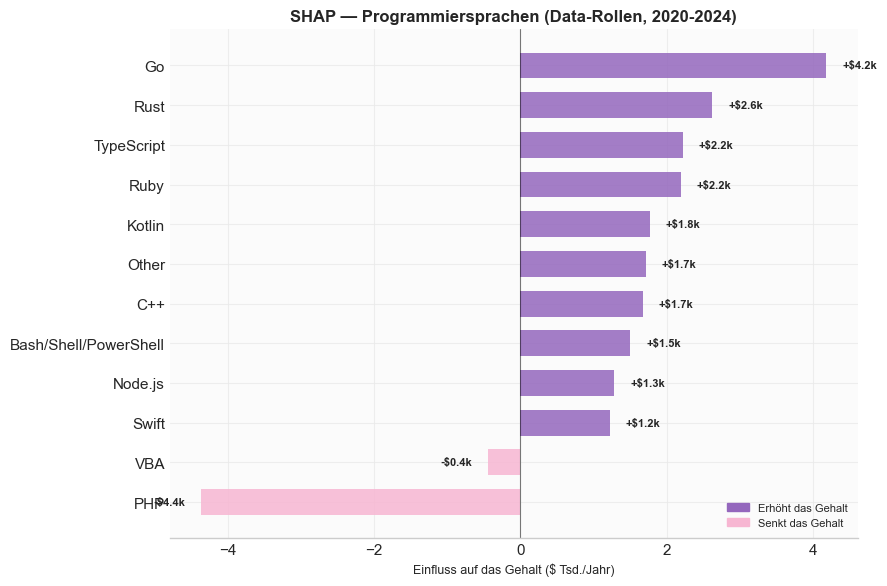

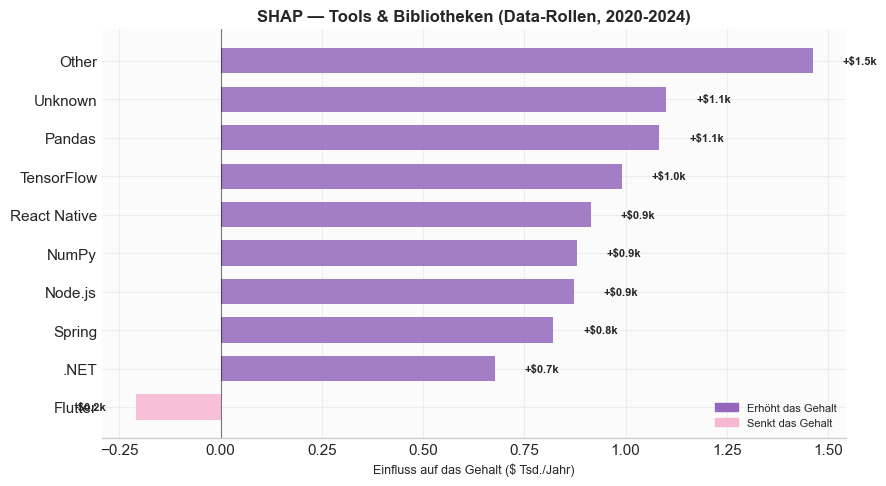

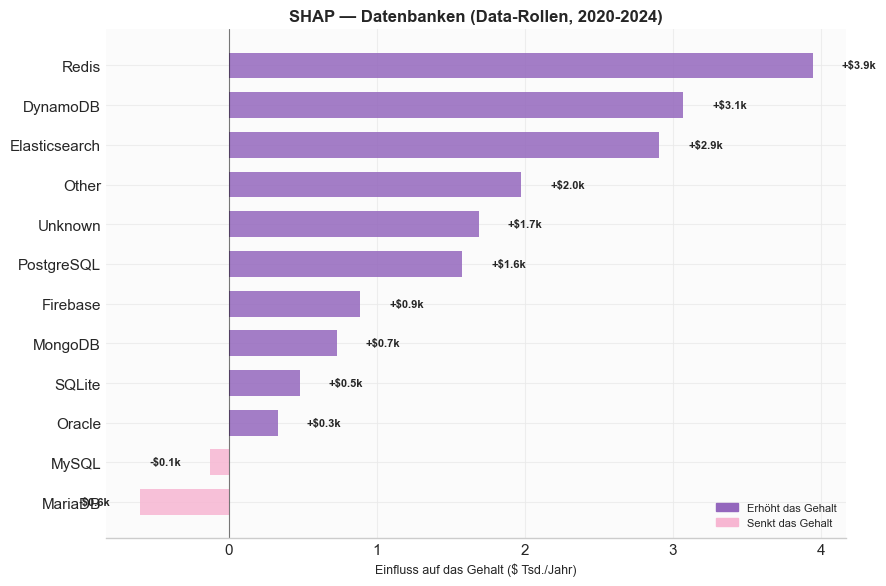

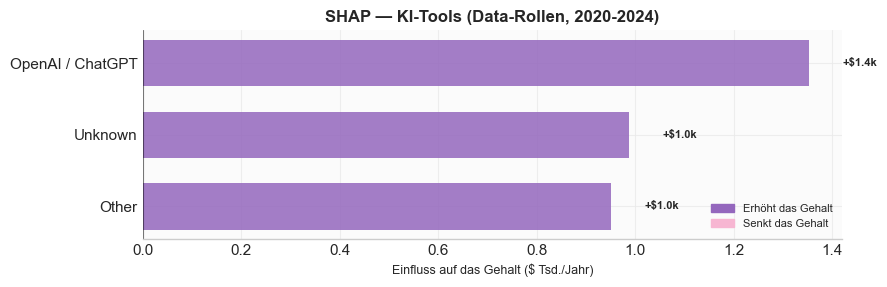


Skill-Abdeckung in shap_df_pure:
                                n_with_skill    pct  mean_shap  usd_k
None                                  1541.0  100.0     0.0105   1.70
Python                                1282.0   83.2     0.0030   1.20
Other                                 1169.0   75.9     0.0023   1.16
GitHub                                1113.0   72.2     0.0064   1.43
SQL                                   1026.0   66.6    -0.0040   0.74
Bash/Shell/PowerShell                  881.0   57.2     0.0071   1.48
C                                      843.0   54.7    -0.0003   0.98
Windows                                830.0   53.9    -0.0267  -0.76
Docker                                 808.0   52.4     0.0105   1.70
PostgreSQL                             728.0   47.2     0.0076   1.51
OpenAI / ChatGPT                       702.0   45.6     0.0041   1.27
Java                                   682.0   44.3    -0.0001   0.99
Jira                                   671.0   43.5     

In [64]:
# ════════════════════════════════════════════════════════════════════════════
# SHAP: Vollständige Berechnung — alle Merkmale + Multi-Spalten + Pure-Filter
# ════════════════════════════════════════════════════════════════════════════

print("SHAP-Werte werden berechnet...")

# ── 1. Transformation und Basisobjekte ───────────────────────────────────────
X_test_transformed = best_model.named_steps["preprocessor"].transform(features_test)
feat_names         = best_model.named_steps["preprocessor"].get_feature_names_out()
model_only         = best_model.named_steps["regressor"]

explainer  = shap.TreeExplainer(model_only)
shap_vals  = explainer.shap_values(X_test_transformed)
shap_df    = pd.DataFrame(shap_vals, columns=feat_names, index=features_test.index)
skill_meta = generate_skill_meta(feat_names)

print(f"shap_df (gesamt):  {shap_df.shape}")

# ── Pure-Maske (purity = 1.0) ─────────────────────────────────────────────────
pure_idx  = df[df["data_role_purity"] == 1.0].index
pure_mask = features_test.index.isin(pure_idx)
print(f"Reine Zeilen im Testset (purity=1.0): {pure_mask.sum()}")

if pure_mask.sum() >= 100:
    shap_vals_pure = explainer.shap_values(X_test_transformed[pure_mask])
    shap_df_pure   = pd.DataFrame(
        shap_vals_pure,
        columns=feat_names,
        index=features_test[pure_mask].index,
    )
else:
    print("⚠ Zu wenige reine Zeilen — verwende gesamtes shap_df")
    shap_df_pure = shap_df

print(f"shap_df_pure:   {shap_df_pure.shape}")

# ── Ursprüngliche Merkmale (vor dem Preprocessor) ────────────────────────────
source_all  = features_test
source_pure = features_test.loc[shap_df_pure.index]

# ── Globaler Median ───────────────────────────────────────────────────────────
median_salary_global = float(df["salary"].median())
print(f"Globaler Median: {median_salary_global:.1f}k  (= ${median_salary_global*1000:,.0f})")

# ── SHAP-Stichprobe aus features_train (alle Jahre 2020-2024) ────────────────
# Train/Test-Split ist zeitbasiert: Train=2020-2024, Test=2025.
# In 2025 fehlen Pandas/TensorFlow/NumPy → Stichprobe aus features_train.
print("\nErstelle SHAP-Stichprobe aus features_train (2020-2024)...")

shap_sample      = features_train.sample(frac=0.2, random_state=42)
X_shap_tr        = best_model.named_steps["preprocessor"].transform(shap_sample)
shap_vals_sample = explainer.shap_values(X_shap_tr)
shap_df_sample   = pd.DataFrame(shap_vals_sample, columns=feat_names, index=shap_sample.index)
source_sample    = shap_sample

print(f"shap_df_sample: {shap_df_sample.shape}")
print(f"Jahresverteilung:\n{shap_sample['year'].value_counts().sort_index()}")

# ── Data-Rollen-Maske für die Stichprobe ─────────────────────────────────────
data_role_mask_sample = source_sample["devtype_data"].str.len() > 0
shap_df_data          = shap_df_sample[data_role_mask_sample]
source_data           = source_sample[data_role_mask_sample]
print(f"Data-Rollen in sample: {data_role_mask_sample.sum()}")


# ════════════════════════════════════════════════════════════════════════════
# Hilfsfunktionen
# ════════════════════════════════════════════════════════════════════════════

def shap_log_to_usd_skill(feat, shap_df, median_salary,
                           source_features=None, min_rows=10):
    """
    Berechnet den durchschnittlichen SHAP-Wert nur für Zeilen,
    in denen der Skill tatsächlich in den Ursprungsdaten vorhanden ist.

    TreeExplainer liefert für ALLE Zeilen Nicht-Null-SHAP-Werte, auch wenn
    der Skill fehlt. Daher wird nach source_features gefiltert und nicht
    nach shap_df[feat] != 0.

    feat            : "multi_language__Python"
    source_features : features_train.sample() — vor dem Preprocessor
    min_rows        : Mindestanzahl Zeilen mit dem Skill (0 = kein Filter)
    """
    if feat not in shap_df.columns:
        return 0.0

    if source_features is not None and "__" in feat:
        prefix, skill_name = feat.split("__", 1)
        col_name = prefix.replace("multi_", "")

        if col_name in source_features.columns:
            has_skill = source_features[col_name].str.contains(
                skill_name, regex=False, na=False
            )
            idx = shap_df.index.intersection(source_features[has_skill].index)
        else:
            idx = shap_df.index
    else:
        idx = shap_df.index

    if min_rows > 0 and len(idx) < min_rows:
        return 0.0

    mean_shap = shap_df.loc[idx, feat].mean()
    return float(np.exp(np.log1p(median_salary) + mean_shap) - median_salary)


def print_metrics(y_true, y_pred, title):
    """Основные метрики модели."""
    from sklearn.metrics import mean_absolute_error, r2_score
    y_true_usd = np.expm1(y_true) * 1000
    y_pred_usd = np.expm1(y_pred) * 1000
    mae = mean_absolute_error(y_true_usd, y_pred_usd) / 1000
    r2  = r2_score(y_true, y_pred)
    print(f"\n{title}")
    print(f"  MAE : ${mae:,.1f}k")
    print(f"  R²  : {r2:.4f}")
    print(f"  N   : {len(y_true):,}")


def plot_shap_global(sv, Xt, feat_names, title, max_display=20):
    """Beeswarm-Plot aller Merkmale."""
    print(f"\n{title} — Top-{max_display} Merkmale")
    shap.summary_plot(
        sv, Xt,
        feature_names=feat_names,
        max_display=max_display,
        show=False,
    )
    plt.title(title, fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_shap_grouped(sv_df, feat_names, title, max_display=20):
    """Merkmale nach Präfix gruppiert."""
    group_shap = {}
    for col in feat_names:
        if "__" in col:
            prefix, rest = col.split("__", 1)
            if prefix.startswith("multi_"):
                group = prefix.replace("multi_", "")
            else:
                parts = rest.split("_")
                group = parts[0] if parts else rest
        else:
            group = col

        if group not in group_shap:
            group_shap[group] = np.zeros(len(sv_df))
        group_shap[group] += np.abs(sv_df[col].values)

    group_mean = pd.Series(
        {g: vals.mean() for g, vals in group_shap.items()}
    ).sort_values(ascending=False).head(max_display)

    fig, ax = plt.subplots(figsize=(10, max(4, len(group_mean) * 0.45)))
    ax.barh(group_mean.index[::-1], group_mean.values[::-1],
            color=C_BLUE, alpha=0.85, height=0.6)
    ax.set_title(f"{title}\n(Merkmale gruppiert)", fontweight="bold", fontsize=12)
    ax.set_xlabel("mean |SHAP|  (Summe pro Gruppe, log1p-Skala)", fontsize=9)
    for i, (g, v) in enumerate(group_mean[::-1].items()):
        ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_shap_multi_cols(sv_df, skill_meta, median_sal,
                          source_features,
                          title_suffix="",
                          multi_cols_to_show=None,
                          max_per_col=15,
                          min_rows=5):
    """
    Balkendiagramm für jede Multi-Spalte.
    Filtert SHAP nach tatsächlichem Vorhandensein des Skills in source_features.

    min_rows : Mindestanzahl Zeilen mit dem Skill (0 = kein Filter)
    """
    if multi_cols_to_show is None:
        multi_cols_to_show = ["language", "tech", "database", "ai"]

    COL_LABELS = {
        "language": "Programmiersprachen",
        "database": "Datenbanken",
        "tech":     "Tools & Bibliotheken",
        "ai":       "KI-Tools",
    }

    half = max(1, max_per_col // 2)

    for col in multi_cols_to_show:
        level_key = f"multi_{col}"

        feats = [f for f, m in skill_meta.items()
                 if m["level"] == level_key and f in sv_df.columns]
        if not feats:
            print(f"  ⚠ {col}: Merkmale nicht in shap_df gefunden")
            continue

        skill_usd = {}
        for f in feats:
            usd = shap_log_to_usd_skill(
                f, sv_df, median_sal,
                source_features=source_features,
                min_rows=min_rows,
            )
            skill_usd[skill_meta[f]["skill"]] = usd

        skill_series = pd.Series(skill_usd)
        if min_rows > 0:
            skill_series = skill_series[skill_series != 0]

        pos = skill_series[skill_series > 0].nlargest(half)
        neg = skill_series[skill_series < 0].nsmallest(half)

        if neg.empty:
            plot_data = skill_series.nlargest(max_per_col).sort_values()
        elif pos.empty:
            plot_data = skill_series.nsmallest(max_per_col).sort_values()
        else:
            plot_data = pd.concat([neg, pos]).sort_values()

        if plot_data.empty:
            print(f"  ⚠ {col}: Keine Daten zur Darstellung")
            continue

        fig, ax = plt.subplots(figsize=(9, max(3, len(plot_data) * 0.5)))
        colors = [C_RED if v < 0 else C_GREEN for v in plot_data.values]
        ax.barh(plot_data.index, plot_data.values, color=colors,
                alpha=0.85, height=0.65)
        ax.axvline(0, color="black", lw=0.8, alpha=0.5)

        for i, (skill, val) in enumerate(plot_data.items()):
            offset = 0.05 * (plot_data.abs().max() or 1)
            ha = "left" if val >= 0 else "right"
            sign = "+$" if val >= 0 else "-$"
            ax.text(val + (offset if val >= 0 else -offset), i,
                    f"{sign}{abs(val):.1f}k",
                    va="center", ha=ha, fontsize=8, fontweight="bold")

        label = COL_LABELS.get(col, col)
        ax.set_title(f"SHAP — {label}{title_suffix}",
                     fontweight="bold", fontsize=12)
        ax.set_xlabel("Einfluss auf das Gehalt ($ Tsd./Jahr)", fontsize=9)
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color=C_GREEN, label="Erhöht das Gehalt"),
            Patch(color=C_RED,   label="Senkt das Gehalt"),
        ], loc="lower right", fontsize=8)
        plt.tight_layout()
        plt.show()


# ════════════════════════════════════════════════════════════════════════════
# BLOCK A: GESAMTER TESTDATENSATZ (2025) — nur Metрiken + Beeswarm
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  BLOCK A — Gesamter Testdatensatz (2025)")
print("═"*62)

target_pred_all = best_model.predict(features_test)
print_metrics(target_test, target_pred_all, "Gesamter Test (2025)")

plot_shap_global(
    shap_vals, X_test_transformed, feat_names,
    title="SHAP — alle Merkmale (gesamter Test 2025)",
    max_display=20,
)

plot_shap_grouped(
    shap_df, feat_names,
    title="SHAP — gruppierte Merkmale (gesamter Test 2025)",
    max_display=20,
)


# ════════════════════════════════════════════════════════════════════════════
# BLOCK B: REINE DATA-SPEZIALISTEN (purity=1.0, 2025) — nur Metriken + Beeswarm
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  BLOCK B — Reine Data-Rollen (purity=1.0, 2025)")
print("═"*62)

X_pure = X_test_transformed[pure_mask]
target_pred_pure = best_model.named_steps["regressor"].predict(X_pure)
print_metrics(target_test[pure_mask], target_pred_pure, "Reine Data-Rollen (2025)")

plot_shap_global(
    shap_vals_pure, X_pure, feat_names,
    title="SHAP — alle Merkmale (reine Data-Rollen 2025)",
    max_display=20,
)

plot_shap_grouped(
    shap_df_pure, feat_names,
    title="SHAP — gruppierte Merkmale (reine Data-Rollen 2025)",
    max_display=20,
)


# ════════════════════════════════════════════════════════════════════════════
# BLOCK C: ALLE ROLLEN — Skill-Interpretation (Train 2020-2024)
# language, tech, database, ai
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  BLOCK C — Skill-Interpretation alle Rollen (2020-2024)")
print("═"*62)

plot_shap_multi_cols(
    shap_df_sample, skill_meta, median_salary_global,
    source_features=source_sample,
    title_suffix=" (alle Rollen, 2020-2024)",
    multi_cols_to_show=["language", "tech", "database", "ai"],
    min_rows=10,
    max_per_col=20,
)


# ════════════════════════════════════════════════════════════════════════════
# BLOCK D: DATA-ROLLEN — Skill-Interpretation (Train 2020-2024)
# language, tech, database, ai
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  BLOCK D — Skill-Interpretation Data-Rollen (2020-2024)")
print("═"*62)

plot_shap_multi_cols(
    shap_df_data, skill_meta, median_salary_global,
    source_features=source_data,
    title_suffix=" (Data-Rollen, 2020-2024)",
    multi_cols_to_show=["language", "tech", "database", "ai"],
    min_rows=10,
    max_per_col=20,
)


# ════════════════════════════════════════════════════════════════════════════
# DIAGNOSE: Skill-Abdeckung in shap_df_pure
# ════════════════════════════════════════════════════════════════════════════
print("\nSkill-Abdeckung in shap_df_pure:")
multi_feats = [f for f, m in skill_meta.items()
               if m["level"].startswith("multi_") and f in shap_df_pure.columns]

coverage = {}
for f in multi_feats:
    if f not in shap_df_pure.columns:
        continue

    prefix, skill_name = (f.split("__", 1) if "__" in f else (f, f))
    col_name = prefix.replace("multi_", "")
    if col_name in source_pure.columns:
        n_with_skill = source_pure[col_name].str.contains(
            skill_name, regex=False, na=False
        ).sum()
    else:
        n_with_skill = len(shap_df_pure)

    n_total  = len(shap_df_pure)
    usd      = shap_log_to_usd_skill(
        f, shap_df_pure, median_salary_global,
        source_features=source_pure,
        min_rows=0,
    )

    if col_name in source_pure.columns:
        has_skill = source_pure[col_name].str.contains(skill_name, regex=False, na=False)
        idx       = shap_df_pure.index.intersection(source_pure[has_skill].index)
        mean_shap = shap_df_pure.loc[idx, f].mean() if len(idx) > 0 else 0.0
    else:
        mean_shap = shap_df_pure[f].mean()

    coverage[skill_meta[f]["skill"]] = {
        "n_with_skill": n_with_skill,
        "pct":          round(n_with_skill / n_total * 100, 1),
        "mean_shap":    round(mean_shap, 4),
        "usd_k":        round(usd, 2),
    }

coverage_df = (
    pd.DataFrame(coverage).T
    .sort_values("n_with_skill", ascending=False)
)
print(coverage_df.head(30).to_string())
print(f"\nSkills mit usd > 0:              {(coverage_df['usd_k'] > 0).sum()}")
print(f"Skills mit usd < 0:              {(coverage_df['usd_k'] < 0).sum()}")
print(f"Skills mit n < 10:               {(coverage_df['n_with_skill'] < 10).sum()}")
print(f"Skills mit n = 0:                {(coverage_df['n_with_skill'] == 0).sum()}")

---
### 💼 6. Data Career Advisor — Empfehlungssystem

In [93]:

from config_mappings import (
    ROLE_NAME_MAPPING, DATA_ROLE_SKILLS, ALL_DATA_SKILLS, COUNTRY_CURRENCY,
    LANG_KNOWN, DB_KNOWN, PLAT_KNOWN, WEB_KNOWN, TECH_KNOWN, AI_KNOWN,
)

ALL_PIPELINE_COLS = num_cols + cat_cols + pca_cols + multi_cols

# ── Normalisierung der Apostrophe in cfg-Mappings (einmalig) ─────────────────
# cfg.education_mapping      = fix_apostrophes(cfg.education_mapping)
# cfg.education_rank_mapping = fix_apostrophes(cfg.education_rank_mapping)
# cfg.org_size_mapping       = fix_apostrophes(cfg.orgsize_mapping)
# cfg.org_size_rank_mapping  = fix_apostrophes(cfg.orgsize_rank_mapping)
# cfg.remote_mapping         = fix_apostrophes(cfg.remote_mapping)
# cfg.industry_mapping       = fix_apostrophes(cfg.industry_mapping)
# cfg.icorpm_mapping         = fix_apostrophes(cfg.icorpm_mapping)


class DataCareerAdvisor:

    def __init__(self, df, skill_meta, pipeline, shap_df,
                 source_features=None, features_train=None):
        self.df              = df.copy()
        self.skill_meta      = skill_meta
        self.pipeline        = pipeline
        self.shap_df         = shap_df
        self.source_features = source_features

        # Предрасчёт цен скиллов по глобальному медиану
        self.skill_price = {}
        for feat, meta in skill_meta.items():
            if not meta["level"].startswith("multi_"): continue
            if feat not in shap_df.columns: continue
            usd = shap_log_to_usd_skill(
                feat, shap_df, median_salary_global,
                source_features=self.source_features,
            )
            self.skill_price[meta["skill"]] = usd

    @staticmethod
    def _fix_input(s: str) -> str:
        """Normalisiert typografische Apostrophe in Eingabestrings."""
        return str(s).strip() #str(s).replace("\u2019", "'").replace("\u2018", "'").strip()

    def _normalize_role(self, role: str) -> str:
        return ROLE_NAME_MAPPING.get(role, role)

    # ── available_* ──────────────────────────────────────────────────────────

    def available_roles(self):
        print("Verfügbare Rollen (in profile['role'] eingeben):\n")
        roles = (self.df["devtype_data"]
                 .dropna().str.split(";").explode().str.strip()
                 .value_counts())
        for role in roles.index:
            print(f"  {role}")

    def available_countries(self):
        print("Verfügbare Länder (in profile['country'] eingeben):\n")
        for val in self.df["country"].dropna().value_counts().index:
            print(f"  {val}")

    def available_education(self):
        print("Verfügbare Bildungsabschlüsse (in profile['education'] eingeben):\n")
        for val in self.df["education"].dropna().value_counts().index:
            print(f"  {val}")

    def available_remote(self):
        print("Verfügbare Arbeitsformate (in profile['remote'] eingeben):\n")
        for val in self.df["remote"].dropna().value_counts().index:
            print(f"  {val}")

    def available_org_sizes(self):
        print("Verfügbare Unternehmensgrößen (in profile['orgsize'] eingeben):\n")
        for val in self.df["orgsize"].dropna().value_counts().index:
            print(f"  {val}")

    def available_industries(self):
        print("Verfügbare Branchen (in profile['industry'] eingeben):\n")
        for val in self.df["industry"].dropna().value_counts().index:
            print(f"  {val}")

    def available_icorpm(self):
        print("Verfügbare icorpm-Werte (in profile['icorpm'] eingeben):\n")
        for val in self.df["icorpm"].dropna().value_counts().index:
            print(f"  {val}")

    def available_ages(self):
        print("Verfügbare Altersgruppen (in profile['age'] eingeben):\n")
        for val in self.df["age"].dropna().value_counts().index:
            print(f"  {val}")

    def available_skills(self, role=None):
        role_normalized = self._normalize_role(role) if role else None
        skills = (DATA_ROLE_SKILLS.get(role_normalized, ALL_DATA_SKILLS)
                  if role_normalized else ALL_DATA_SKILLS)
        label  = f"'{role_normalized}'" if role_normalized else "alle Data-Rollen"
        print(f"Skills für {label}:\n")
        for skill in sorted(skills):
            print(f"  {skill}")

    # ── Kernmethoden ─────────────────────────────────────────────────────────

    def get_context_median(self, country: str, role: str) -> float:
        """Marktmedian in Tausend USD für Land + Rolle."""
        df = self.df
        for mask in [
            (df["country"] == country) &
            (df["devtype_data"].str.contains(role, regex=False, na=False)),
            (df["country"] == country),
        ]:
            sub = df.loc[mask, "salary"].dropna()
            if len(sub) >= 30:
                return float(sub.median())
        return float(median_salary_global)

    def _build_profile_row(self, profile):
        country      = profile.get("country", "Germany")
        role         = profile.get("role", "Data or business analyst")
        years_exp    = int(profile.get("years_experience", 3))
        year_profile = int(profile.get("year", 2025))
        age          = profile.get("age", "25-34 years old")

        # ── Маппинг входных значений ─────────────────────────────────────────
        edu_raw      = self._fix_input(profile.get("education",
                        "Bachelor's degree (B.A., B.S., B.Eng., etc.)"))
        edu_can      = cfg.education_mapping.get(edu_raw, edu_raw)
        edu_rank     = cfg.education_rank_mapping.get(edu_can, 0)

        org_raw      = self._fix_input(profile.get("orgsize", "Large 1 (1-5k)"))
        org_can      = cfg.orgsize_mapping.get(org_raw, org_raw)
        org_rank     = cfg.orgsize_rank_mapping.get(org_can, 0)

        remote_can   = cfg.remote_mapping.get(
                        self._fix_input(profile.get("remote", "Hybrid")),
                        "Hybrid")
        industry_can = cfg.industry_mapping.get(
                        self._fix_input(profile.get("industry",
                        "IT, Telecom & Tech")), "IT, Telecom & Tech")
        icorpm_can   = cfg.icorpm_mapping.get(
                        self._fix_input(profile.get("icorpm", "IC")), "IC")

        # ── Нормализация страны ───────────────────────────────────────────────
        country_can = country
        if country_can == "United States of America":
            country_can = "United States"
        elif country_can == "United Kingdom of Great Britain and Northern Ireland":
            country_can = "Great Britain"
        country_can = cfg.country_mapping.get(country_can, country_can)

        # Валюта из df
        currency_mask = self.df["country"] == country_can
        currency_can  = (self.df.loc[currency_mask, "currency"].mode()[0]
                         if currency_mask.sum() > 0 else "USD US Dollar")

        region = cfg.region_mapping.get(country, "Other")

        # ── Target Encoding медианы ───────────────────────────────────────────
        def _safe_median(mask, fallback):
            sub = self.df.loc[mask, "salary"].dropna()
            return float(sub.median()) if len(sub) >= 10 else fallback

        global_med       = float(median_salary_global)
        country_med      = _safe_median(
            self.df["country"] == country_can, global_med)
        country_role_med = _safe_median(
            (self.df["country"] == country_can) &
            (self.df["devtype_data"].str.contains(role, regex=False, na=False)),
            country_med)
        region_med       = _safe_median(
            self.df["country_region"] == region, global_med)
        region_role_med  = _safe_median(
            (self.df["country_region"] == region) &
            (self.df["devtype_data"].str.contains(role, regex=False, na=False)),
            region_med)

        years_code  = years_exp + 2
        hobby_years = max(0, years_code - years_exp)

        row = {
            # num_cols
            "year":                  year_profile,
            "education_rank":        edu_rank,
            "orgsize_rank":          org_rank,
            "workexp":               years_exp,    
            "yearscode":             years_code,    
            "hobbyyears":            hobby_years,   
            "country_salary_median": country_med,
            "country_role_median":   country_role_med,
            "region_salary_median":  region_med,
            "region_role_median":    region_role_med,
            # cat_cols
            "country":               country_can,
            "currency":              currency_can,
            "remote":                remote_can,
            "branch":                "Professional",
            "employment":            "Employed, full-time",
            "industry":              industry_can,
            "icorpm":                icorpm_can,
            "education":             edu_can,
            "orgsize":              org_can,
            "country_region":        region,
            "age":                   age,
        }

        # ── Skills → multi_cols ───────────────────────────────────────────────
        user_skills = [s.strip() for s in profile.get("skills", [])]

        row["language"]      = ";".join(s for s in user_skills if s in LANG_KNOWN)
        row["database"]      = ";".join(s for s in user_skills if s in DB_KNOWN)
        row["platform"]      = ";".join(s for s in user_skills if s in PLAT_KNOWN)
        row["webframe"]      = ";".join(s for s in user_skills if s in WEB_KNOWN)
        row["tech"]          = ";".join(s for s in user_skills if s in TECH_KNOWN)
        row["ai"]            = ";".join(s for s in user_skills if s in AI_KNOWN)
        row["aiselect"]     = "Yes" if row["ai"] else "No"
        row["activities"]    = ""
        row["opsys"]         = ""
        row["office_stack"]  = ""
        row["aiagents"]     = ""
        row["devtype_data"]  = role
        row["devtype_other"] = "None"

        # Остальные num_cols — нули
        for col in num_cols:
            if col not in row:
                row[col] = 0

        return pd.DataFrame([row])

    def predict_salary(self, profile):
        X    = self._build_profile_row(profile)
        pred = self.pipeline.predict(X)[0]
        return float(np.expm1(pred)) * 1000

    def recommend_skills_to_learn(self, profile, top_n=5):
        """
        Рекомендует скиллы в порядке приоритета:
        1. language, database, tech, ai
        2. platform, webframe — только если из группы 1 набрано меньше top_n
        """
        user_skills     = {s.lower() for s in profile.get("skills", [])}
        role            = profile.get("role", "")
        country         = profile.get("country", "Germany")
        role_normalized = self._normalize_role(role)
        allowed         = {s.lower() for s in
                           DATA_ROLE_SKILLS.get(role_normalized, ALL_DATA_SKILLS)}
        context_median  = self.get_context_median(country, role)

        EXCLUDE          = {"multi_devtype_data", "multi_devtype_other"}
        PRIMARY_GROUPS   = {"language", "database", "tech", "ai"}
        SECONDARY_GROUPS = {"platform", "webframe"}

        def _collect(groups):
            candidates = {}
            for feat, meta in self.skill_meta.items():
                level = meta["level"]
                if level in EXCLUDE or not level.startswith("multi_"):
                    continue
                if feat not in self.shap_df.columns:
                    continue
                group = level.replace("multi_", "")
                if group not in groups:
                    continue
                skill = meta["skill"]
                if skill.lower() in user_skills:
                    continue
                if skill.lower() not in allowed:
                    continue
                usd = shap_log_to_usd_skill(
                    feat, self.shap_df, context_median,
                    source_features=self.source_features,
                )
                if usd > 0:
                    candidates[skill] = usd
            return sorted(candidates.items(), key=lambda x: -x[1])

        result = _collect(PRIMARY_GROUPS)[:top_n]

        if len(result) < top_n:
            already   = {s for s, _ in result}
            secondary = [(s, u) for s, u in _collect(SECONDARY_GROUPS)
                         if s not in already]
            result   += secondary[:top_n - len(result)]

        return result

    def recommend_country(self, profile, min_n=30, top_n=5):
        role = profile.get("role", "Data or business analyst")
        mask = self.df["devtype_data"].str.contains(role, regex=False, na=False)
        return (self.df[mask].groupby("country")["salary"]
                .agg(["median", "count"])
                .query(f"count >= {min_n}")
                .sort_values("median", ascending=False)
                .head(top_n))

    def full_report(self, profile):
        SEP          = "=" * 62
        country      = profile.get("country", "—")
        role         = profile.get("role", "—")
        role_display = ROLE_NAME_MAPPING.get(role, role)

        valid_roles = set(self.df["devtype_data"].dropna().str.strip().unique())
        if role not in valid_roles:
            print(f"⚠ Rolle '{role}' nicht in den Daten gefunden.")
            print("  Verwende advisor.available_roles() für die Rollenliste.")
            return

        print(SEP)
        print("  📊 DATA CAREER ADVISOR — GEHALTSREPORT")
        print(SEP)
        print(f"  Rolle:        {role_display}")
        print(f"  Skills:       {', '.join(profile.get('skills', []))}")
        print(f"  Erfahrung:    {profile.get('years_experience', 0)} Jahre")
        print(f"  Alter:        {profile.get('age', '—')}")
        print(f"  Land:         {country}")
        print(f"  Abschluss:    {profile.get('education', '—')}")
        print(f"  Arbeitsform:  {profile.get('remote', '—')}")

        salary     = self.predict_salary(profile)
        ctx_median = self.get_context_median(country, role)

        print(f"\n  💰 Erwartetes Gehalt:  ${salary:,.0f} / Jahr")
        print(f"  📍 Marktmedian ({country}, {role_display}):"
              f"  ${ctx_median * 1000:,.0f} / Jahr")

        recs = self.recommend_skills_to_learn(profile, top_n=5)
        if recs:
            print(f"\n  📚 Top-5 Skills zum Erlernen:")
            for skill, usd in recs:
                meta  = next((m for m in self.skill_meta.values()
                              if m["skill"] == skill), {})
                level = meta.get("level", "").replace("multi_", "")
                print(f"     {skill:<24}  +${usd * 1000:>8,.0f}/Jahr   [{level}]")

        print(SEP)

    def diagnose(self, profile):
        """Profildiagnose — was das Modell sieht."""
        role    = profile.get("role", "—")
        country = profile.get("country", "—")
        X_row   = self._build_profile_row(profile)

        print("=== Numerische Merkmale ===")
        for col in num_cols:
            if col in X_row.columns:
                print(f"  {col:<30} = {X_row[col].values[0]}")

        print("\n=== Kategorische Merkmale ===")
        for col in cat_cols:
            if col in X_row.columns:
                print(f"  {col:<30} = {X_row[col].values[0]}")

        print("\n=== Target Encoding (Mediane) ===")
        for col in ["country_salary_median", "country_role_median",
                    "region_salary_median",  "region_role_median"]:
            if col in X_row.columns:
                val = X_row[col].values[0]
                print(f"  {col:<30} = {val:.2f}k  (= ${val*1000:,.0f})")

        print("\n=== Vorhersage ===")
        raw = self.pipeline.predict(X_row)[0]
        print(f"  Rohvorhersage (log1p): {raw:.4f}")
        print(f"  expm1(raw):            {np.expm1(raw):.2f}k")
        print(f"  Ergebnis $:            ${np.expm1(raw)*1000:,.0f}")

        print("\n=== Vergleich mit realen Daten ===")
        mask    = (
            (self.df["country"] == country) &
            (self.df["devtype_data"].str.contains(role, regex=False, na=False))
        )
        sub = self.df[mask]
        print(f"  {country} + '{role}': {len(sub)} Zeilen")
        if len(sub) > 0:
            print(f"  Median:        {sub['salary'].median():.1f}k"
                  f"  (= ${sub['salary'].median()*1000:,.0f})")
            print(f"  25. Perzentil: {sub['salary'].quantile(0.25):.1f}k"
                  f"  (= ${sub['salary'].quantile(0.25)*1000:,.0f})")
            print(f"  75. Perzentil: {sub['salary'].quantile(0.75):.1f}k"
                  f"  (= ${sub['salary'].quantile(0.75)*1000:,.0f})")


# ── Initialisierung ───────────────────────────────────────────────────────────
advisor = DataCareerAdvisor(
    df              = df,
    skill_meta      = skill_meta,
    pipeline        = best_model,
    shap_df         = shap_df_sample,   # Train-Stichprobe 2020-2024
    source_features = source_sample,
    features_train  = features_train,
)
print("✓ DataCareerAdvisor initialisiert")

✓ DataCareerAdvisor initialisiert


In [71]:
advisor.available_roles()
advisor.available_countries()
advisor.available_education()
advisor.available_remote()
advisor.available_org_sizes()
advisor.available_industries()
advisor.available_icorpm()
advisor.available_skills()

Verfügbare Rollen (in profile['role'] eingeben):

  Unknown
  Database administrator
  Data scientist or machine learning specialist
  Engineer, data
  Data or business analyst
  Scientist
  Data engineer
  Data scientist
  AI/ML engineer
  Applied scientist
  Database administrator or engineer
  Financial analyst or engineer
Verfügbare Länder (in profile['country'] eingeben):

  United States of America
  Germany
  United Kingdom of Great Britain and Northern Ireland
  India
  Canada
  France
  United States
  Brazil
  Netherlands
  Poland
  Spain
  Australia
  Italy
  Sweden
  Ukraine
  Switzerland
  Russian Federation
  United Kingdom
  Austria
  Czech Republic
  Israel
  Turkey
  Denmark
  Belgium
  Norway
  Portugal
  Romania
  Finland
  Mexico
  South Africa
  New Zealand
  Greece
  Argentina
  Hungary
  Ireland
  Bulgaria
  Colombia
  Japan
  Pakistan
  Iran, Islamic Republic of...
  China
  Serbia
  Slovenia
  Bangladesh
  Slovakia
  Lithuania
  Croatia
  Chile
  Indonesia
  Si

In [94]:
# Junior Data Analyst in Germany
profile_junior_de = {
    "role":             "Data scientist or machine learning specialist",
    "skills":           ["Python", "SQL", "Pandas", "MySQL", "NumPy"],
    "years_experience": 2,
    "country":          "Germany",
    "education":        "Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
    "remote":           "Hybrid",
    "year":             2025,
}
advisor.full_report(profile_junior_de)
#advisor.diagnose(profile_junior_de)
advisor.diagnose(profile_junior_de)

  📊 DATA CAREER ADVISOR — GEHALTSREPORT
  Rolle:        Data Scientist / ML specialist
  Skills:       Python, SQL, Pandas, MySQL, NumPy
  Erfahrung:    2 Jahre
  Alter:        —
  Land:         Germany
  Abschluss:    Master's degree (M.A., M.S., M.Eng., MBA, etc.)
  Arbeitsform:  Hybrid

  💰 Erwartetes Gehalt:  $58,627 / Jahr
  📍 Marktmedian (Germany, Data Scientist / ML specialist):  $69,814 / Jahr

  📚 Top-5 Skills zum Erlernen:
     Redis                     +$   4,129/Jahr   [database]
     PostgreSQL                +$   1,611/Jahr   [database]
     OpenAI / ChatGPT          +$   1,375/Jahr   [ai]
     TensorFlow                +$     990/Jahr   [tech]
     MongoDB                   +$     711/Jahr   [database]
=== Numerische Merkmale ===
  year                           = 2025
  education_rank                 = 4
  orgsize_rank                   = 7
  workexp                        = 2
  yearscode                      = 4
  hobbyyears                     = 2
  country_salary_med

In [95]:
# Senior Data Scientist in USA
profile_senior_us = {
    "role":             "Data scientist or machine learning specialist",
    "skills":           ["Python", "SQL", "PyTorch", "TensorFlow",
                         "AWS", "Docker", "Kubernetes", "Spark", "Airflow",
                         "OpenAI / ChatGPT"],
    "years_experience": 8,
    "country":          "United States",
    "education":        "Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
    "remote":           "Remote",
    "org_size":         "1,000 to 4,999 employees",
    "year":             2025,
}
advisor.full_report(profile_senior_us)
advisor.diagnose(profile_senior_us)

  📊 DATA CAREER ADVISOR — GEHALTSREPORT
  Rolle:        Data Scientist / ML specialist
  Skills:       Python, SQL, PyTorch, TensorFlow, AWS, Docker, Kubernetes, Spark, Airflow, OpenAI / ChatGPT
  Erfahrung:    8 Jahre
  Alter:        —
  Land:         United States
  Abschluss:    Master's degree (M.A., M.S., M.Eng., MBA, etc.)
  Arbeitsform:  Remote

  💰 Erwartetes Gehalt:  $124,661 / Jahr
  📍 Marktmedian (United States, Data Scientist / ML specialist):  $126,057 / Jahr

  📚 Top-5 Skills zum Erlernen:
     Redis                     +$   6,615/Jahr   [database]
     PostgreSQL                +$   2,097/Jahr   [database]
     Pandas                    +$   1,159/Jahr   [tech]
     NumPy                     +$     773/Jahr   [tech]
     MongoDB                   +$     482/Jahr   [database]
=== Numerische Merkmale ===
  year                           = 2025
  education_rank                 = 4
  orgsize_rank                   = 7
  workexp                        = 8
  yearscode         